# 🚢 Container Stowage Planning RL — v13 Lexicographic 3-way (BL / SF / EF)

> **목적**: v12 의 14항목 보상 구조 (R1~R14, rebalanced) 를 사용하면서,
> **BL (Baseline) / SF (Safety-First) / EF (Efficiency-First)** 세 정책을 비교한다.
>
> 산업 실무 (Sun Kwang 본선 플래닝 §6-2 1)) 의 1순위/2순위 의사결정을 RL 보상에 직접 표현 +
> 우선순위 부여 자체의 효과를 BL과 대비하여 검증.

## 🔄 v12 → v13 변경 사항

| 항목 | v12 | v13 | 변경 사유 |
|---|---|---|---|
| **정책 수** | 2 (SF, EF) | **3 (BL, SF, EF)** | 우선순위 부여 효과 검증 (vs Baseline) |
| **BL 정책** | - | **모든 round BASE** | 통제군 — Phase 1 부터 R1~R14 전체 활성 |
| **가설** | H1~H4 | **H1~H4 + H5a, H5b** | BL 대비 SF/EF 우월성 검증 |
| **Figure 3** | 2-bar | **3-bar** | bar_width 자동 조정 |
| **Excel HeadToHead** | SF vs EF | **BL / SF / EF Best** | 3-way 비교 표 |

## 📋 세 정책 정의

| 정책 | Phase 1 (Lv1, Lv2) | Phase 2 (Lv3, Lv4) | 역할 |
|---|---|---|---|
| **BL** (Baseline) | **All R1-R14 (BASE)** | **All R1-R14 (BASE)** | 통제군 — 산업 기본값 |
| **SF** (Safety-First) | **Stability 만** (R5, R6, R11) | **모든 보상** | 안전 우선 — 악천후/원양 |
| **EF** (Efficiency-First) | **Efficiency 만** (R3, R4, R8, R10, R12, R13) | **모든 보상** | 효율 우선 — 단거리 환적 |

**모든 phase 에서 항상 활성** (Operational Invariants): R1, R2, R7, R9, R14 — 운영 제약 + 학습 신호

## 🔬 사전 등록 가설

### H1~H4 (SF vs EF — 정책 간 우선순위 비교)

- **H1 (Stability 우위)**: SF 의 final WBI ≥ EF + 0.05 (Cliff's δ > 0.3)
- **H2 (Efficiency 우위)**: EF 의 final OSR ≤ SF − 0.03 (Cliff's δ > 0.3)
- **H3 (Trade-off 비대칭)**: H1 의 효과 크기 > H2 의 효과 크기 (Stability priority 가 더 robust)
- **H4 (Phase 전환 안정성)**: SF/EF 모두 Phase 2 시작 후 학습 곡선이 빠르게 안정화 (Skalse 2022)

### ★ H5 (vs Baseline — 우선순위 부여 효과)

- **H5a (Stability 우선의 효과)**: SF 의 final WBI > BL + 0.02 — 우선순위 부여가 안정성 KPI 향상에 기여
- **H5b (Efficiency 우선의 효과)**: EF 의 final OSR < BL − 0.02 — 우선순위 부여가 효율성 KPI 향상에 기여

## ⚙️ 실험 설정 (v13)

- Stability 가중치 재보정: R5/R6/R11 약 4~6× 상향 (v12 유지)
- Curriculum: Lv1 (20K) → Lv2 (25K) → Lv3 (32K) → Lv4 (48K) = **125K eps/policy**
- 정책당 step: **~8.07M steps** (Lv4 4.8M → 2,343 PPO updates)
- 총 학습량: **3 policies × 125K = 375K episodes, ~24.2M steps**
- 시드: GLOBAL_SEED=42 (1-seed pilot, 4-seed 본 실험 전 단계)
- 예상 시간 (Colab T4): 약 **9~15 시간** (v12 대비 1.5× 증가)

## 📊 학습 곡선

- **Figure 1**: 누적 보상 (Cumulative Reward) vs 글로벌 step (3 policies)
- **Figure 6**: 스텝별 보상 (per-episode reward, smoothed) vs 글로벌 step (3 policies)
- BL 정책은 phase 전환이 없으므로 P1→P2 boundary 마커 미표시 (curriculum 마커만 표시)

## 📦 출력물

- `v13_3way_results.xlsx` — Round_Summary / Lv4_ThreeWay / H5_Tests / Phase_Info / Config
- 시각화 PNG **8개** — 누적 보상, 라운드별, KPI 막대 (3-way), Radar, Bay plans ×3, 스텝별 보상, 보상 항목 분석

---
### ★ v14 변경 (수직 동일-POD 적재 억제)
- **R15 신규 (Vertical POD Stacking Penalty, `vstack_pod_penalty` = -4.0):** 같은 열에서 바로 아래 칸이 동일 POD이면 step 단위 패널티 부과. 연속 런 길이에 비례(상한 3). R8/R9 열이 세로 단일-POD로 적재되던 문제를 직접 억제하고 "같은 POD = 같은 tier 수평 적재" 원칙을 강제.
- **R10 강화:** `tier_pod_match` 2.5→4.0, 매칭 cap 3→4. 수평 동일-POD 확산 유인 강화.
- 효과(단위 검증): 동일 POD 4개 적재 시 세로열 −24 vs 수평밴드 +24 → 수평 배치가 우월하도록 보상 역전.


## 📦 Cell 1: Package Installation


In [1]:
!pip install gymnasium stable-baselines3 openpyxl --quiet
# stable-baselines3: PPO 사용


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 69.2 MB/s eta 0:00:00


## 🔧 Cell 2: All Code Definitions
환경, 보상 구조 (R13 재정의), 학습 함수, 시각화 함수 등 모든 코드 정의 (PPO 단독)


In [2]:

# ══════════════════════════════════════════════════════════════════════
#  Container Stowage Planning — Single Bay, GP-40, 6 PODs
#  PPO Only — Curriculum RL with Weight Constraints (SCIE Research)
#
#  v7 수정사항 (Option C — SCIE 본격 실험):
#   - 레벨별 step 예산 차등 배정 (CONFIG.timesteps_per_level)
#       · Lv1: 150K, Lv2: 300K, Lv3: 500K, Lv4: 1,600K (총 2.25M)
#       · 모든 레벨에서 ~8,000~9,400 에피소드 학습 (균등화)
#   - 보상 구조는 v6 그대로 유지 (R13 Same-Tier Band, R14 Empty Row)
#   - PPO 단독, 100% fill, 6 PODs
# ══════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────
# SECTION A: 라이브러리 임포트 & 전역 재현성 확보
# ─────────────────────────────────────────────────────────────────────
import os, sys, random, csv, json, warnings, copy, subprocess, datetime
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats as scipy_stats
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO                       # ★ PPO만 사용
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict, Counter

warnings.filterwarnings("ignore")

# ── 전역 시드 고정: 42 ──────────────────────────────────────────────
GLOBAL_SEED = 42

def set_global_seed(seed: int) -> None:
    """모든 난수 생성기를 동일 시드로 고정하여 실험 재현성 확보."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
    except ImportError:
        pass

set_global_seed(GLOBAL_SEED)
print("✅ [A] Imports & seed fixed (GLOBAL_SEED=42) — PPO only, v6")


# ─────────────────────────────────────────────────────────────────────
# SECTION B: 한글 폰트 설정 (Colab 호환)
# ─────────────────────────────────────────────────────────────────────
def setup_korean_font() -> str:
    """NanumGothic 폰트 설치 및 matplotlib 등록."""
    subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
    subprocess.run(["fc-cache", "-fv"], capture_output=True)
    import matplotlib.font_manager as fm
    for font in fm.fontManager.ttflist:
        if "Nanum" in font.name and "Gothic" in font.name:
            plt.rcParams["font.family"]        = font.name
            plt.rcParams["axes.unicode_minus"] = False
            return font.name
    plt.rcParams["font.family"]        = "DejaVu Sans"
    plt.rcParams["axes.unicode_minus"] = False
    return "DejaVu Sans"

_active_font = setup_korean_font()
print(f"✅ [B] Korean font active: {_active_font}")


# ─────────────────────────────────────────────────────────────────────
# SECTION C: 적재 환경 — SingleBayStowageEnv (v6 보상 구조)
#
#  ★ POD 6개, 커리큘럼 4단계 (4×4→6×6→8×8→10×10)
#  ★ MAX_ROWS = 10, OBS_DIM = 79
#
#  ★★★ 보상 구조 v6 ★★★
#
#  [핵심 원칙]
#    1. 컨테이너 선적 순서: POD 내림차순(먼 항구→가까운 항구),
#       동일 POD 내 무게 내림차순(무거운 것 먼저)
#    2. 같은 POD 컨테이너는 같은 Tier에 수평으로 우선 배치 (★ R13 신규)
#    3. 모든 Row에 최소 1개 이상 컨테이너 적재 권장 (R14)
#
#  [Step-level 보상]
#    R1   유효 적재 보너스              +1.0
#    R2   스택 가득참 패널티            −10.0
#    R3   오버스토우 패널티             −15.0
#    R4   올바른 하역 순서 보너스       +3.0
#    R5   중량 균형 보너스              +0.5 × (1 − CV)
#    R6   COG 편차 패널티              −1.0 × 편차비율
#    R9   열 무게 제한 초과 패널티      −5.0
#    R10  같은 층 같은 POD 보너스       +2.5
#    R11  무게 역전 패널티              −1.5
#    R13  ★ Same-Tier Band 보너스      +2.0 (target tier 일치)
#                                      −1.5 × (위로 벗어난 tier 수)
#
#  [Terminal 보상]
#    R7   에피소드 완료 보너스          +80.0 × VPR
#    R8   POD 수평 밴드 품질 보너스     +2.0
#    R12  열별 하역순서 완벽도 보너스   +3.0
#    R14  빈 Row 패널티                 −3.0 × (빈 Row 수)
# ─────────────────────────────────────────────────────────────────────

# ── POD 상수 (6개 항구) ──────────────────────────────────────────────
N_POD      = 6
POD_NAMES  = {
    1: "Busan",      # 부산 (가장 가까운 항)
    2: "Shanghai",   # 상하이
    3: "Ningbo",     # 닝보
    4: "Singapore",  # 싱가포르
    5: "Colombo",    # 콜롬보
    6: "Rotterdam",  # 로테르담 (가장 먼 항)
}
MAX_ROWS   = 10

# ── 무게 제약조건 상수 ───────────────────────────────────────────────
MIN_WT     = 10.0
MAX_WT     = 20.0
MAX_COL_WT = 145.0

# OBS_DIM = MAX_ROWS*6 + (1+N_POD) + 6 + N_POD = 60 + 7 + 6 + 6 = 79
OBS_DIM    = MAX_ROWS * 6 + (1 + N_POD) + 6 + N_POD


@dataclass
class StowageMetrics:
    """에피소드 레벨 성능 지표 (R13 의미만 변경, 나머지는 동일)."""
    n_total      : int   = 0
    n_valid      : int   = 0
    n_invalid    : int   = 0
    n_overstow   : int   = 0
    n_col_wt_viol: int   = 0
    n_empty_rows : int   = 0
    row_weights  : List[float] = field(default_factory=list)
    pod_per_row  : List[List[int]] = field(default_factory=list)
    # ── 보상 항목별 누적값 (R1~R14, R13 의미 변경) ──
    reward_components : Dict[str, float] = field(default_factory=lambda: {
        "R1_valid": 0.0,
        "R2_stack_full": 0.0,
        "R3_overstow": 0.0,
        "R4_order": 0.0,
        "R5_weight_bal": 0.0,
        "R6_cog": 0.0,
        "R7_completion": 0.0,
        "R8_pod_band": 0.0,
        "R9_col_wt": 0.0,
        "R10_tier_match": 0.0,
        "R11_wt_inversion": 0.0,
        "R12_col_order": 0.0,
        "R13_tier_band": 0.0,           # ★ v6: 의미 변경 (Same-Tier Band)
        "R14_empty_row": 0.0,
        "R15_vstack_pod": 0.0,          # ★ v14: 수직 동일 POD 인접 적재 패널티
    })

    @property
    def vpr(self) -> float:
        return self.n_valid / max(self.n_total, 1)

    @property
    def osr(self) -> float:
        return self.n_overstow / max(self.n_total, 1)

    @property
    def wbi(self) -> float:
        wts = [w for w in self.row_weights if w > 0]
        if len(wts) < 2: return 1.0
        cv = float(np.std(wts)) / (float(np.mean(wts)) + 1e-9)
        return float(np.clip(1.0 - cv, 0.0, 1.0))

    @property
    def psr(self) -> float:
        occupied = [pods for pods in self.pod_per_row if pods]
        if not occupied: return 0.0
        pure = sum(1 for pods in occupied if len(set(pods)) == 1)
        return pure / len(occupied)

    @property
    def cwvr(self) -> float:
        return self.n_col_wt_viol / max(self.n_total, 1)


class SingleBayStowageEnv(gym.Env):
    """
    단일 베이 컨테이너 적재계획 환경 (v6 보상 구조).
    ★ 6개 POD, 커리큘럼 4단계 (4×4 → 10×10), 100% 적재율.
    ★ 컨테이너 선적 순서: POD 내림차순 → 동일 POD 무게 내림차순
    ★ R13 Same-Tier Band 보상으로 같은 POD가 같은 Tier에 수평 적재되도록 유도
    """
    metadata = {"render_modes": []}

    def __init__(self, curriculum_level: int = 1, config: dict = None):
        super().__init__()
        self.cfg   = config if config else CONFIG
        self.level = curriculum_level
        lv         = self.cfg["levels"][self.level]

        self.n_rows       = lv["n_rows"]
        self.n_tiers      = lv["n_tiers"]
        self.n_containers = lv["n_containers"]
        self.n_pods       = N_POD

        # ── 행동 공간: MAX_ROWS(10)로 고정 → 전이학습 호환 ──
        self.action_space = spaces.Discrete(MAX_ROWS)

        # ── 관측 공간: 고정 차원 (OBS_DIM = 79) ──
        self.observation_space = spaces.Box(
            low=-2.0, high=2.0, shape=(OBS_DIM,), dtype=np.float32)

        # ── 내부 상태 ──
        self.wt_grid  : np.ndarray = None
        self.pod_grid : np.ndarray = None
        self.stack_h  : np.ndarray = None
        self.ctns_wt  : np.ndarray = None
        self.ctns_pod : np.ndarray = None
        self.step_idx : int        = 0
        self.metrics  : StowageMetrics = None

    def reset(self, seed: int = None, options: dict = None):
        super().reset(seed=seed)
        rng = np.random.default_rng(seed)

        self.wt_grid  = np.zeros((self.n_rows, self.n_tiers), dtype=np.float32)
        self.pod_grid = np.zeros((self.n_rows, self.n_tiers), dtype=np.int32)
        self.stack_h  = np.zeros(self.n_rows,                 dtype=np.int32)
        self.step_idx = 0
        self.metrics  = StowageMetrics()

        raw_wt  = rng.uniform(MIN_WT, MAX_WT, self.n_containers).astype(np.float32)
        raw_pod = rng.integers(1, self.n_pods + 1, self.n_containers).astype(np.int32)

        # POD 내림차순, 동일 POD 내 무게 내림차순 정렬
        sort_keys = np.lexsort((
            -raw_wt,    # 2차 키: 무게 내림차순
            -raw_pod,   # 1차 키: POD 내림차순
        ))
        self.ctns_wt  = raw_wt[sort_keys]
        self.ctns_pod = raw_pod[sort_keys]

        return self._obs(), {}

    def _get_col_weight(self, row: int) -> float:
        """특정 열(row)에 적재된 컨테이너의 총 무게를 반환."""
        h = int(self.stack_h[row])
        if h == 0:
            return 0.0
        return float(self.wt_grid[row, :h].sum())

    # ─────────────────────────────────────────────────────────────
    # ★ v6 신규 헬퍼: 현재 POD에 대한 'target tier' 계산
    # ─────────────────────────────────────────────────────────────
    def _get_target_tier_for_pod(self, pod: int) -> int:
        """현재 POD에 적합한 target tier 반환.

        규칙:
          (a) 같은 POD가 이미 적재되어 있는 경우:
              - 그 중 가장 높은 tier(=현재 'band' 윗면)를 후보로 함.
              - 그 tier에 빈 자리가 있으면(어떤 row의 stack_h == band_top)
                target = band_top  (수평 확장 권장)
              - 빈 자리가 없으면(전체 row의 stack_h > band_top)
                target = band_top + 1  (정상적으로 한 단 위로 이동)
          (b) 같은 POD가 아직 없는 경우:
              - target = stack_h.min()  (가장 낮은 사용 가능 tier에서 시작)
        """
        # (a) 같은 POD가 적재된 모든 (row, tier) 위치 탐색
        tiers_with_pod: List[int] = []
        for r in range(self.n_rows):
            h = int(self.stack_h[r])
            for t in range(h):
                if int(self.pod_grid[r, t]) == pod:
                    tiers_with_pod.append(t)

        if tiers_with_pod:
            band_top = max(tiers_with_pod)
            # band_top tier에 빈 자리(어떤 row가 정확히 stack_h == band_top)가 있는지
            has_room_on_band = any(int(self.stack_h[r]) == band_top
                                   for r in range(self.n_rows))
            if has_room_on_band:
                return band_top              # 같은 tier에서 수평 확장
            else:
                return band_top + 1          # 다음 tier로 정상 이동
        else:
            # (b) 같은 POD가 아직 없음
            return int(self.stack_h.min())

    def _obs(self) -> np.ndarray:
        """정규화된 관측 벡터 생성 (dim = OBS_DIM = 79)."""
        mid_row = (self.n_rows - 1) / 2.0 + 1e-9

        # ── 스택별 특성 (MAX_ROWS × 6 = 60) ─────────────────────
        stack_feats = np.zeros((MAX_ROWS, 6), dtype=np.float32)
        for r in range(self.n_rows):
            h = int(self.stack_h[r])
            if h == 0:
                stack_feats[r] = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                continue
            fill        = h / self.n_tiers
            wt_norm     = float(self.wt_grid[r, :h].sum()) / (MAX_WT * self.n_tiers)
            mean_pod    = float(self.pod_grid[r, :h].mean()) / self.n_pods
            top_pod     = float(self.pod_grid[r, h - 1])    / self.n_pods
            ov          = sum(1 for t in range(h - 1)
                              if self.pod_grid[r, t] < self.pod_grid[r, t + 1])
            ov_ratio    = ov / max(h - 1, 1)
            col_wt_ratio = self._get_col_weight(r) / MAX_COL_WT
            stack_feats[r] = [fill, wt_norm, mean_pod, top_pod, ov_ratio, col_wt_ratio]

        # ── 현재 컨테이너 특성 [1 + N_POD = 7] ──────────────────
        if self.step_idx < self.n_containers:
            w   = float(self.ctns_wt[self.step_idx])  / MAX_WT
            pod = int(self.ctns_pod[self.step_idx])
            pod_oh = np.eye(self.n_pods, dtype=np.float32)[pod - 1]
            cur_feats = np.array([w, *pod_oh], dtype=np.float32)
        else:
            cur_feats = np.zeros(1 + self.n_pods, dtype=np.float32)

        # ── 글로벌 특성 [6] ──────────────────────────────────────
        total_wt  = float(self.wt_grid.sum()) + 1e-9
        row_wts   = self.wt_grid.sum(axis=1)
        row_wts_nonzero = row_wts[row_wts > 0]

        row_idx  = np.arange(self.n_rows, dtype=np.float32)
        cog      = float(np.dot(row_idx, row_wts)) / total_wt
        cog_norm = (cog - mid_row) / mid_row

        if len(row_wts_nonzero) >= 2:
            wt_cv = float(np.std(row_wts_nonzero)) / (float(np.mean(row_wts_nonzero)) + 1e-9)
        else:
            wt_cv = 0.0

        n_placed = self.step_idx
        total_ov = sum(
            sum(1 for t in range(int(self.stack_h[r]) - 1)
                if self.pod_grid[r, t] < self.pod_grid[r, t + 1])
            for r in range(self.n_rows))

        global_feats = np.array([
            self.step_idx / self.n_containers,
            float(np.clip(cog_norm, -2.0, 2.0)),
            float(np.clip(wt_cv, 0.0, 2.0)),
            self.metrics.n_valid   / max(n_placed, 1),
            total_ov / max(n_placed, 1),
            n_placed / (self.n_rows * self.n_tiers),
        ], dtype=np.float32)

        # ── 잔여 POD 분포 [N_POD = 6] ───────────────────────────
        rem = self.ctns_pod[self.step_idx:]
        if len(rem) > 0:
            counts = np.array([np.sum(rem == p) for p in range(1, self.n_pods + 1)],
                              dtype=np.float32)
            rem_dist = counts / counts.sum()
        else:
            rem_dist = np.zeros(self.n_pods, dtype=np.float32)

        return np.concatenate([
            stack_feats.flatten(),   # 60
            cur_feats,               #  7
            global_feats,            #  6
            rem_dist,                #  6
        ]).astype(np.float32)        # 총 = 79

    def step(self, action) -> Tuple[np.ndarray, float, bool, bool, dict]:
        """컨테이너 적재 실행 및 보상 계산 (v6 보상 구조).

        ★★★ v6 변경점 ★★★
        - R13 (중앙 Row 보너스) 제거
        - R13 (Same-Tier Band 보너스) 신설
        """
        row    = int(action)
        reward = 0.0
        rw     = self.cfg["rw"]

        if self.step_idx >= self.n_containers:
            return self._obs(), 0.0, True, False, {}

        # ── 유효하지 않은 행 선택 (커리큘럼 호환) ──
        if row >= self.n_rows:
            reward += rw["stack_full"] * 2.0
            self.metrics.reward_components["R2_stack_full"] += rw["stack_full"] * 2.0
            self.metrics.n_invalid += 1
            self.step_idx += 1
            terminated = (self.step_idx >= self.n_containers)
            if terminated:
                reward += self._compute_terminal_rewards(rw)
            return self._obs(), float(reward), terminated, False, {
                "valid": self.metrics.n_valid, "invalid": self.metrics.n_invalid,
                "overstow": self.metrics.n_overstow, "step": self.step_idx
            }

        cw  = float(self.ctns_wt[self.step_idx])
        pod = int(self.ctns_pod[self.step_idx])
        h   = int(self.stack_h[row])
        self.metrics.n_total += 1

        # ── R2: 스택 가득참 ──
        if h >= self.n_tiers:
            reward += rw["stack_full"]
            self.metrics.reward_components["R2_stack_full"] += rw["stack_full"]
            self.metrics.n_invalid += 1
            self.step_idx += 1
        else:
            # ── R3 & R4: 오버스토우 / 하역순서 ──
            if h > 0:
                top_pod = int(self.pod_grid[row, h - 1])
                if top_pod < pod:
                    reward += rw["overstow"]
                    self.metrics.reward_components["R3_overstow"] += rw["overstow"]
                    self.metrics.n_overstow += 1
                elif top_pod > pod:
                    reward += rw["order_bonus"]
                    self.metrics.reward_components["R4_order"] += rw["order_bonus"]
                else:
                    reward += rw["order_bonus"] * 0.3
                    self.metrics.reward_components["R4_order"] += rw["order_bonus"] * 0.3
            else:
                reward += rw["order_bonus"] * 0.3
                self.metrics.reward_components["R4_order"] += rw["order_bonus"] * 0.3

            # ── R1: 유효 적재 ──
            reward += rw["valid"]
            self.metrics.reward_components["R1_valid"] += rw["valid"]

            # ─────────────────────────────────────────────────
            # ★ v6: R13 Same-Tier Band 보상 (배치 직전에 계산)
            # 배치 결과 tier(actual_tier) = h, target_tier는 _get_target_tier_for_pod 사용
            # ─────────────────────────────────────────────────
            target_tier = self._get_target_tier_for_pod(pod)
            actual_tier = h

            if actual_tier == target_tier:
                # 정확한 tier에 적재 → 보너스
                r13_val = rw["tier_band_bonus"]
            elif actual_tier > target_tier:
                # 너무 위에 적재 → 패널티 (위로 벗어난 tier 수에 비례)
                r13_val = rw["tier_band_penalty"] * (actual_tier - target_tier)
            else:
                # actual < target: 흔치 않으나 약한 패널티
                r13_val = rw["tier_band_penalty"] * 0.5
            reward += r13_val
            self.metrics.reward_components["R13_tier_band"] += r13_val

            # ── 컨테이너 배치 ──
            self.wt_grid[row, h]  = cw
            self.pod_grid[row, h] = pod
            self.stack_h[row]     = h + 1
            self.metrics.n_valid += 1

            # ── R10: 같은 층(Tier) 같은 POD 매칭 보너스 ──
            tier_match_count = 0
            for other_r in range(self.n_rows):
                if other_r == row:
                    continue
                if int(self.stack_h[other_r]) > h:
                    if int(self.pod_grid[other_r, h]) == pod:
                        tier_match_count += 1
            if tier_match_count > 0:
                r10_val = rw["tier_pod_match"] * min(tier_match_count, 4)  # ★ v14: cap 3→4 (수평 확산 강화)
                reward += r10_val
                self.metrics.reward_components["R10_tier_match"] += r10_val

            # ── R15: 수직 동일 POD 인접 적재 패널티 (★ v14 신규) ──
            #   같은 열에서 바로 아래 칸(h-1)이 동일 POD이면 패널티.
            #   "같은 POD는 같은 층(tier)에 수평 적재" 원칙을 강제하기 위해
            #   세로로 같은 POD를 쌓는 행위(R8, R9 열 세로 적재 문제)를 직접 억제한다.
            #   step 단위 dense 신호로 작동하여 R3/R4/R12의 '단일 POD 세로열' 선호를 상쇄.
            if h > 0:
                below_pod = int(self.pod_grid[row, h - 1])
                if below_pod == pod:
                    # 같은 열에 이미 동일 POD가 몇 칸 연속으로 쌓였는지 카운트 (런 길이)
                    run = 1
                    t = h - 1
                    while t >= 0 and int(self.pod_grid[row, t]) == pod:
                        run += 1
                        t   -= 1
                    # 런이 길수록 강하게 처벌 (선형 누진, 상한 3)
                    r15_val = rw["vstack_pod_penalty"] * min(run - 1, 3)
                    reward += r15_val
                    self.metrics.reward_components["R15_vstack_pod"] += r15_val

            # ── R11: 무게 역전 패널티 ──
            if h > 0:
                below_wt = float(self.wt_grid[row, h - 1])
                if cw > below_wt + 0.5:
                    r11_val = rw["wt_inversion_penalty"]
                    reward += r11_val
                    self.metrics.reward_components["R11_wt_inversion"] += r11_val

            # ── R9: 열 무게 제한 초과 패널티 ──
            col_wt = self._get_col_weight(row)
            if col_wt > MAX_COL_WT:
                r9_val = rw["col_wt_penalty"]
                reward += r9_val
                self.metrics.reward_components["R9_col_wt"] += r9_val
                self.metrics.n_col_wt_viol += 1

            # ── R5: 중량 균형 ──
            occ_wts = np.array([self.wt_grid[r, :int(self.stack_h[r])].sum()
                                for r in range(self.n_rows)], dtype=np.float32)
            used_wts = occ_wts[occ_wts > 0]
            if len(used_wts) >= 2:
                wt_cv = float(np.std(used_wts)) / (float(np.mean(used_wts)) + 1e-9)
                r5_val = rw["weight_balance"] * (1.0 - min(wt_cv, 1.0))
                reward += r5_val
                self.metrics.reward_components["R5_weight_bal"] += r5_val

            # ── R6: COG 패널티 ──
            total_wt = occ_wts.sum() + 1e-9
            cog      = float(np.dot(np.arange(self.n_rows, dtype=np.float32), occ_wts)) / total_wt
            cog_dev  = abs(cog - (self.n_rows - 1) / 2.0) / ((self.n_rows - 1) / 2.0 + 1e-9)
            r6_val   = rw["cog_penalty"] * cog_dev
            reward  += r6_val
            self.metrics.reward_components["R6_cog"] += r6_val

            self.step_idx += 1

        terminated = (self.step_idx >= self.n_containers)

        # ══════════════════════════════════════════════════════
        # ── 종료 보상 (Terminal Rewards) ──
        # ══════════════════════════════════════════════════════
        if terminated:
            reward += self._compute_terminal_rewards(rw)

        return self._obs(), float(reward), terminated, False, {
            "valid": self.metrics.n_valid, "invalid": self.metrics.n_invalid,
            "overstow": self.metrics.n_overstow, "step": self.step_idx,
        }

    def _compute_terminal_rewards(self, rw: dict) -> float:
        """에피소드 종료 시 터미널 보상 계산 (R7, R8, R12, R14)."""
        terminal_reward = 0.0

        # ── R7: 에피소드 완료 보너스 ──
        r7_val = rw["completion"] * self.metrics.vpr
        terminal_reward += r7_val
        self.metrics.reward_components["R7_completion"] += r7_val

        # ── R8: POD 수평 밴드 품질 보너스 ──
        total_band_score = 0.0
        tiers_evaluated  = 0
        for t in range(self.n_tiers):
            pods_at_tier = []
            for r in range(self.n_rows):
                if int(self.stack_h[r]) > t:
                    pods_at_tier.append(int(self.pod_grid[r, t]))
            if len(pods_at_tier) >= 2:
                pod_counts = Counter(pods_at_tier)
                most_common_count = pod_counts.most_common(1)[0][1]
                purity = most_common_count / len(pods_at_tier)
                total_band_score += purity
                tiers_evaluated += 1
        if tiers_evaluated > 0:
            avg_purity = total_band_score / tiers_evaluated
            r8_val = rw["pod_band_quality"] * avg_purity * tiers_evaluated
            terminal_reward += r8_val
            self.metrics.reward_components["R8_pod_band"] += r8_val

        # ── R12: 열별 하역순서 완벽도 보너스 ──
        perfect_cols = 0
        for r in range(self.n_rows):
            h = int(self.stack_h[r])
            if h >= 2:
                is_perfect = True
                for t in range(h - 1):
                    if self.pod_grid[r, t] < self.pod_grid[r, t + 1]:
                        is_perfect = False
                        break
                if is_perfect:
                    perfect_cols += 1
        if perfect_cols > 0:
            r12_val = rw["col_order_bonus"] * perfect_cols
            terminal_reward += r12_val
            self.metrics.reward_components["R12_col_order"] += r12_val

        # ── R14: 빈 Row 패널티 ──
        empty_count = 0
        for r in range(self.n_rows):
            if int(self.stack_h[r]) == 0:
                empty_count += 1
        if empty_count > 0:
            r14_val = rw["empty_row_penalty"] * empty_count
            terminal_reward += r14_val
            self.metrics.reward_components["R14_empty_row"] += r14_val
            self.metrics.n_empty_rows = empty_count

        # ── 메트릭 기록 ──
        self.metrics.row_weights = [
            float(self.wt_grid[r, :int(self.stack_h[r])].sum())
            for r in range(self.n_rows)]
        self.metrics.pod_per_row = [
            list(self.pod_grid[r, :int(self.stack_h[r])])
            for r in range(self.n_rows)]

        return terminal_reward


print("✅ [C] SingleBayStowageEnv defined (v6: Same-Tier Band reward)")
print(f"   Obs dim (fixed): {OBS_DIM}  (MAX_ROWS={MAX_ROWS}×6 + {1+N_POD} + 6 + {N_POD})")
print(f"   PODs ({N_POD}): {POD_NAMES}")
print(f"   Cargo: GP_40 only (weight {MIN_WT:.0f}–{MAX_WT:.0f} MT)")
print(f"   Max column weight: {MAX_COL_WT:.0f} MT")
print(f"   ★ Loading order: POD desc → Weight desc")
print(f"   ★ R13: Same-Tier Band bonus (REPLACES center row bonus)")
print(f"   ★ R14: Empty Row penalty")


# ─────────────────────────────────────────────────────────────────────
# SECTION D: 실험 인프라 — Logger, Callback, CurriculumManager
# ─────────────────────────────────────────────────────────────────────

def make_env(level: int, config: dict, seed: int = 0) -> gym.Env:
    """PPO용 환경 생성."""
    return SingleBayStowageEnv(curriculum_level=level, config=config)


class ExperimentLogger:
    """CSV + JSON 결과 저장 로거."""

    HEADER = ["algorithm","seed","round","level",
              "avg_reward","std_reward","min_reward","max_reward",
              "avg_osr","avg_vpr","avg_wbi","avg_psr","avg_cwvr"]

    def __init__(self, name: str, config: dict):
        ts           = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        self.log_dir = f"/content/results/{name}_{ts}"
        os.makedirs(self.log_dir, exist_ok=True)

        cfg_safe = {}
        for k, v in config.items():
            if k == "levels":
                cfg_safe[k] = {str(lk): {sk: sv for sk, sv in lv.items()}
                               for lk, lv in v.items()}
            else:
                cfg_safe[k] = v
        with open(f"{self.log_dir}/config.json", "w", encoding="utf-8") as f:
            json.dump(cfg_safe, f, indent=2, ensure_ascii=False)

        self.csv_path = f"{self.log_dir}/training_log.csv"
        with open(self.csv_path, "w", newline="", encoding="utf-8") as f:
            csv.writer(f).writerow(self.HEADER)
        print(f"✅ Logger → {self.log_dir}")

    def log(self, algo, seed, rnd, lvl, rewards, metrics_list):
        avg_osr  = float(np.mean([m.osr  for m in metrics_list]))
        avg_vpr  = float(np.mean([m.vpr  for m in metrics_list]))
        avg_wbi  = float(np.mean([m.wbi  for m in metrics_list]))
        avg_psr  = float(np.mean([m.psr  for m in metrics_list]))
        avg_cwvr = float(np.mean([m.cwvr for m in metrics_list]))
        with open(self.csv_path, "a", newline="", encoding="utf-8") as f:
            csv.writer(f).writerow([
                algo, seed, rnd, lvl,
                f"{np.mean(rewards):.4f}", f"{np.std(rewards):.4f}",
                f"{np.min(rewards):.4f}",  f"{np.max(rewards):.4f}",
                f"{avg_osr:.4f}", f"{avg_vpr:.4f}",
                f"{avg_wbi:.4f}", f"{avg_psr:.4f}",
                f"{avg_cwvr:.4f}",
            ])

    def save_fig(self, fig, name: str) -> str:
        path = f"{self.log_dir}/{name}"
        fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"  💾 Figure saved: {path}")
        return path


class EpisodeMetricsCallback(BaseCallback):
    """에피소드별 보상 및 길이 기록 + ★ v8: 목표 에피소드 도달 시 학습 종료."""

    def __init__(self, target_episodes: Optional[int] = None):
        super().__init__(verbose=0)
        self.ep_rewards  : List[float] = []
        self.ep_lengths  : List[int]   = []
        self.timesteps   : List[int]   = []
        self._cur_r      = 0.0
        self._cur_l      = 0
        # ★ v8: 목표 에피소드 (None 이면 step-based 종료, SB3 기본 동작)
        self.target_episodes = target_episodes

    def _on_step(self) -> bool:
        self._cur_r += float(self.locals["rewards"][0])
        self._cur_l += 1
        if self.locals["dones"][0]:
            self.ep_rewards.append(self._cur_r)
            self.ep_lengths.append(self._cur_l)
            self.timesteps.append(self.num_timesteps)
            self._cur_r = 0.0
            self._cur_l = 0
            # ★ v8: 목표 에피소드 도달 → False 반환하면 model.learn() 종료
            if (self.target_episodes is not None
                and len(self.ep_rewards) >= self.target_episodes):
                return False
        return True

    def smoothed(self, window: int = 20) -> np.ndarray:
        r = np.array(self.ep_rewards)
        if len(r) < window: return r
        kernel = np.ones(window) / window
        return np.convolve(r, kernel, mode="valid")


class CurriculumManager:
    """레벨 1→2→3→4 점진적 난이도 관리."""

    def __init__(self, config: dict):
        self.config    = config
        self.level     = 1
        self.max_level = len(config["levels"])

    def should_level_up(self, avg_r: float) -> bool:
        return avg_r > self.config["level_up_threshold"] and self.level < self.max_level

    def level_up(self):
        if self.level < self.max_level:
            self.level += 1
            lv = self.config["levels"][self.level]
            print(f"  🆙 Level UP → Lv{self.level}: "
                  f"{lv['n_containers']} containers, "
                  f"{lv['n_rows']} rows × {lv['n_tiers']} tiers")

print("✅ [D] Logger, Callback, CurriculumManager defined")


# ─────────────────────────────────────────────────────────────────────
# SECTION E: PPO 모델 구축 & 학습 루프
# ─────────────────────────────────────────────────────────────────────

def _build_ppo_model(env, config: dict, seed: int):
    """PPO 모델 생성."""
    p = config["ppo"]
    return PPO(
        "MlpPolicy", env,
        learning_rate  = p["lr"],
        gamma          = p["gamma"],
        n_steps        = p["n_steps"],
        batch_size     = p["batch_size"],
        n_epochs       = p["n_epochs"],
        clip_range     = p["clip_range"],
        ent_coef       = p["ent_coef"],
        gae_lambda     = p["gae_lambda"],
        policy_kwargs  = {"net_arch": p["net_arch"]},
        seed           = seed,
        verbose        = 0,
        device         = "auto",
    )


def _evaluate_episode_full(model, level: int, config: dict, seed: int
                           ) -> Tuple[float, 'StowageMetrics', dict]:
    """평가 에피소드 1회 실행 + Bay Plan 상태 반환."""
    env = make_env(level=level, config=config)
    obs, _ = env.reset(seed=seed)
    done   = False; total_r = 0.0
    while not done:
        act, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = env.step(act)
        done = term or trunc
        total_r += r

    bay_plan = {
        "wt_grid":  env.wt_grid.copy(),
        "pod_grid": env.pod_grid.copy(),
        "stack_h":  env.stack_h.copy(),
        "ctns_wt":  env.ctns_wt.copy(),
        "ctns_pod": env.ctns_pod.copy(),
        "n_rows":   env.n_rows,
        "n_tiers":  env.n_tiers,
    }
    return total_r, env.metrics, bay_plan


def _run_training(
    config    : dict,
    logger    : ExperimentLogger,
    seed      : int,
) -> Dict:
    """PPO 학습 루프."""
    set_global_seed(seed)
    algo_name   = "PPO"
    curriculum  = CurriculumManager(config)
    results     = {"algo": algo_name,
                   "avg_rewards": [], "std_rewards": [], "levels": [],
                   "callbacks": [], "final_metrics": None, "trained_model": None,
                   "per_round_metrics": [],
                   "per_round_bay_plans": [],
                   "phase_info":          []}     # ★ v11 NEW
    model       = None

    # ★ v11 NEW: Lexicographic phase 설정
    lex_spec = config.get("lexicographic", None)
    base_rw  = dict(config["rw"])    # BASE rewards 원본 보존

    for rnd in range(config["total_rounds"]):
        lv     = curriculum.level
        lv_cfg = config["levels"][lv]
        print(f"  [{algo_name} seed={seed}] Round {rnd+1}/{config['total_rounds']} "
              f"Lv{lv}: {lv_cfg['n_containers']}c × {lv_cfg['n_rows']}r×{lv_cfg['n_tiers']}t")

        # ★ v11 NEW: Phase 결정 + 보상 가중치 적용 (round 번호 기반 — robust)
        if lex_spec is not None:
            current_round = rnd + 1   # 1-indexed
            if current_round in lex_spec["phase1_rounds"]:
                phase, mode = 1, lex_spec["phase1_mode"]
            elif current_round in lex_spec["phase2_rounds"]:
                phase, mode = 2, lex_spec["phase2_mode"]
            else:
                phase, mode = 2, "BASE"
            config["rw"] = make_phase_weights(base_rw, mode)
            n_active = sum(1 for v in config["rw"].values() if v != 0)
            print(f"    🎯 Phase {phase} ({mode}): {n_active}/{len(base_rw)} 보상 활성")
        else:
            phase, mode = 0, "BASE"
            config["rw"] = base_rw

        results["phase_info"].append({
            "round": rnd + 1, "level": lv, "phase": phase, "mode": mode,
            "n_active_rewards": sum(1 for v in config["rw"].values() if v != 0),
            "rw_snapshot": dict(config["rw"]),
        })

        _lv = lv
        def _make(l=_lv): return make_env(l, config, seed)
        train_env = DummyVecEnv([_make])

        if model is None:
            model = _build_ppo_model(train_env, config, seed)
            print(f"    ✅ {algo_name} Model created | obs:{OBS_DIM} | act:{train_env.action_space}")
        else:
            model.set_env(train_env)
            print(f"    🔄 Transfer learning: env replaced, weights retained")

        # ★ v8: 레벨별 "에피소드" 예산 (스텝이 아닌 에피소드로 학습 종료)
        eps_per_level = config.get("episodes_per_level")
        if eps_per_level and lv in eps_per_level:
            target_eps = eps_per_level[lv]
        else:
            # 폴백: timesteps_per_round → 에피소드로 환산 (legacy 호환)
            target_eps = (config.get("timesteps_per_round", 200_000)
                          // lv_cfg["n_containers"])

        # SB3 model.learn(total_timesteps) 안전 상한 (callback이 먼저 종료)
        sf      = config.get("max_steps_safety_factor", 2.0)
        max_ts  = int(target_eps * lv_cfg["n_containers"] * sf)
        print(f"    💡 Episode budget for Lv{lv}: {target_eps:,} episodes "
              f"(safety cap: {max_ts:,} steps, ×{sf})")

        import time
        _t0 = time.time()
        cb  = EpisodeMetricsCallback(target_episodes=target_eps)
        model.learn(total_timesteps=max_ts, callback=cb,
                    reset_num_timesteps=False)
        train_sec    = time.time() - _t0
        actual_eps   = len(cb.ep_rewards)
        actual_steps = cb.timesteps[-1] if cb.timesteps else 0
        results["callbacks"].append(cb)
        print(f"    ⏱  Trained {actual_eps:,} episodes "
              f"({actual_steps:,} steps, {train_sec/60:.1f} min)")

        n_eval      = config["eval_episodes"]
        ep_rewards  = []
        ep_metrics  = []
        last_bay_plan = None
        for ep in range(n_eval):
            r, m, bp = _evaluate_episode_full(model, lv, config, seed + ep * 17)
            ep_rewards.append(r)
            ep_metrics.append(m)
            last_bay_plan = bp

        results["per_round_bay_plans"].append(last_bay_plan)

        avg_r = float(np.mean(ep_rewards))
        std_r = float(np.std(ep_rewards))
        avg_empty = float(np.mean([m.n_empty_rows for m in ep_metrics]))
        print(f"    📊 Eval: reward={avg_r:8.2f}±{std_r:6.2f} | "
              f"OSR={np.mean([m.osr for m in ep_metrics]):.3f} | "
              f"VPR={np.mean([m.vpr for m in ep_metrics]):.3f} | "
              f"WBI={np.mean([m.wbi for m in ep_metrics]):.3f} | "
              f"PSR={np.mean([m.psr for m in ep_metrics]):.3f} | "
              f"CWVR={np.mean([m.cwvr for m in ep_metrics]):.3f} | "
              f"EmptyR={avg_empty:.1f}")

        results["avg_rewards"].append(avg_r)
        results["std_rewards"].append(std_r)
        results["levels"].append(lv)
        results["per_round_metrics"].append({
            "round": rnd + 1, "level": lv,
            "avg_reward": avg_r, "std_reward": std_r,
            "avg_osr":  float(np.mean([m.osr  for m in ep_metrics])),
            "avg_vpr":  float(np.mean([m.vpr  for m in ep_metrics])),
            "avg_wbi":  float(np.mean([m.wbi  for m in ep_metrics])),
            "avg_psr":  float(np.mean([m.psr  for m in ep_metrics])),
            "avg_cwvr": float(np.mean([m.cwvr for m in ep_metrics])),
            "avg_empty_rows": avg_empty,
            # ★ v8: 학습 통계 추가
            "actual_episodes": actual_eps,
            "actual_steps":    actual_steps,
            "train_seconds":   train_sec,
        })
        logger.log(algo_name, seed, rnd + 1, lv, ep_rewards, ep_metrics)
        results["final_metrics"] = ep_metrics

        # ════════ ★ v8: 라운드 종료 요약 블록 ════════
        bar = "═" * 72
        print()
        print(f"    {bar}")
        print(f"    🏁 ROUND {rnd+1}/{config['total_rounds']} 완료  "
              f"│  Lv{lv}: {lv_cfg['n_containers']} 컨테이너  "
              f"({lv_cfg['n_rows']}×{lv_cfg['n_tiers']})")
        print(f"    {bar}")
        print(f"      📚 학습: {actual_eps:>6,} episodes  │  "
              f"{actual_steps:>9,} steps  │  {train_sec/60:>5.1f} min")
        print(f"      🧪 평가: reward = {avg_r:+8.2f} ± {std_r:6.2f}  "
              f"(over {n_eval} eval episodes)")
        m_osr  = float(np.mean([m.osr  for m in ep_metrics]))
        m_vpr  = float(np.mean([m.vpr  for m in ep_metrics]))
        m_wbi  = float(np.mean([m.wbi  for m in ep_metrics]))
        m_psr  = float(np.mean([m.psr  for m in ep_metrics]))
        m_cwvr = float(np.mean([m.cwvr for m in ep_metrics]))
        print(f"      📊 지표: OSR={m_osr:.3f}  VPR={m_vpr:.3f}  "
              f"WBI={m_wbi:.3f}  PSR={m_psr:.3f}  "
              f"CWVR={m_cwvr:.3f}  EmptyR={avg_empty:.1f}")
        cum_str = "  →  ".join(f"R{i+1}:{r:+.1f}"
                                for i, r in enumerate(results["avg_rewards"]))
        print(f"      📈 누적: {cum_str}")
        print(f"    {bar}")
        print()
        # ═══════════════════════════════════════════════

        if curriculum.should_level_up(avg_r):
            curriculum.level_up()

    results["trained_model"] = model
    return results


print("✅ [E] PPO training functions defined")


# ─────────────────────────────────────────────────────────────────────
# SECTION F: 출판 품질 시각화 함수 (PPO 단독)
# ─────────────────────────────────────────────────────────────────────

CLR  = {"PPO": "#2166AC"}
FILL = {"PPO": "#74ADD1"}

def _scie_style():
    """출판 품질 matplotlib 기본값 적용."""
    plt.rcParams.update({
        "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
        "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
        "lines.linewidth": 1.8, "lines.markersize": 6,
        "axes.grid": True, "grid.alpha": 0.3,
        "figure.dpi": 100, "savefig.dpi": 300,
        "axes.spines.top": False, "axes.spines.right": False,
    })
    plt.rcParams["font.family"]        = _active_font
    plt.rcParams["axes.unicode_minus"] = False


# ── Figure 1: 학습 곡선 (X축 = Round) ──────────────────────────────
def plot_learning_curves_by_round(
    ppo_res: Dict,
    logger: ExperimentLogger, config: dict
) -> None:
    """Fig.1: 커리큘럼 라운드별 학습 성능."""
    _scie_style()
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(
        "Fig. 1  PPO — Curriculum Learning (X-axis: Round)\n"
        f"(v6: Same-Tier Band reward | Single-Bay, GP-40, {N_POD} PODs, "
        f"Weight {MIN_WT:.0f}–{MAX_WT:.0f}MT, Max Col {MAX_COL_WT:.0f}MT, Fill 100%)",
        fontsize=11, fontweight="bold", y=1.02)

    x = np.arange(1, config["total_rounds"] + 1)

    mu = np.array(ppo_res["avg_rewards"])
    sd = np.array(ppo_res["std_rewards"])
    ax.plot(x, mu, "o-", color=CLR["PPO"], label="PPO (mean)", lw=2, ms=7, zorder=3)
    ax.fill_between(x, mu - sd, mu + sd, alpha=0.2, color=FILL["PPO"], label="PPO ±1σ")

    ax.axhline(0, color="gray", ls="--", lw=1, alpha=0.5)

    levels = ppo_res["levels"]
    for i in range(len(levels) - 1):
        if levels[i] != levels[i + 1]:
            ax.axvline(x=x[i + 1] - 0.5, color="orange", ls=":", lw=1.5, alpha=0.8)
    for i, lv in enumerate(levels):
        ax.text(x[i], ax.get_ylim()[0], f"Lv{lv}", ha="center", va="top",
                fontsize=7.5, color="gray")

    ax.set_xlabel("Curriculum Round")
    ax.set_ylabel("Average Episode Reward")
    ax.set_title("PPO — Reward per Round")
    ax.legend(loc="upper left")
    ax.set_xticks(x)

    plt.tight_layout()
    logger.save_fig(fig, "fig1_learning_curves_by_round.png")
    plt.show(); plt.close(fig)


# ── Figure 2: 학습 곡선 (X축 = Step) ───────────────────────────────
def plot_learning_curves_by_step(
    ppo_res: Dict,
    logger: ExperimentLogger, config: dict
) -> None:
    """Fig.2: 학습 스텝별 에피소드 보상."""
    _scie_style()
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(
        "Fig. 2  PPO — Learning Curve (X-axis: Training Step)\n"
        "(Smoothed episode reward, window=20 | v6 reward structure)",
        fontsize=11, fontweight="bold", y=1.02)

    all_rewards = []
    all_steps   = []
    for cb in ppo_res["callbacks"]:
        all_rewards.extend(cb.ep_rewards)
        all_steps.extend(cb.timesteps)

    r = np.array(all_rewards)
    s = np.array(all_steps)
    window = min(20, len(r))
    if window > 1:
        kernel = np.ones(window) / window
        r_smooth = np.convolve(r, kernel, mode="valid")
        s_smooth = s[window-1:]
    else:
        r_smooth = r
        s_smooth = s

    ax.plot(s_smooth, r_smooth, color=CLR["PPO"], lw=1.2, alpha=0.8,
            label="PPO (smoothed)")

    ax.set_xlabel("Training Step")
    ax.set_ylabel("Episode Reward")
    ax.set_title("PPO — Reward vs Step")
    ax.legend(loc="upper left")

    plt.tight_layout()
    logger.save_fig(fig, "fig2_learning_curves_by_step.png")
    plt.show(); plt.close(fig)


# ── Figure 3: 라운드별 바 차트 ─────────────────────────────────────
def plot_round_comparison(
    ppo_res: Dict,
    logger: ExperimentLogger, config: dict
) -> None:
    """Fig.3: PPO 라운드별 평균 보상 바차트."""
    _scie_style()
    n_rounds = config["total_rounds"]
    x = np.arange(1, n_rounds + 1)
    w = 0.55

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle("Fig. 3  PPO Round-wise Performance (v6)",
                 fontsize=11, fontweight="bold")

    means = np.array(ppo_res["avg_rewards"])
    stds  = np.array(ppo_res["std_rewards"])
    bars = ax.bar(x, means, w, yerr=stds, label="PPO",
                  color=CLR["PPO"], alpha=0.85, edgecolor="white",
                  capsize=3, error_kw={"lw": 1})
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + (1 if h >= 0 else -3),
                f'{h:.1f}', ha='center', va='bottom' if h >= 0 else 'top',
                fontsize=7)

    levels = ppo_res["levels"]
    for i, lv in enumerate(levels):
        ax.text(x[i], ax.get_ylim()[0] - 3, f"Lv{lv}",
                ha="center", fontsize=8, color="gray", fontstyle="italic")

    ax.set_xlabel("Curriculum Round")
    ax.set_ylabel("Average Episode Reward")
    ax.set_xticks(x)
    ax.legend()
    ax.axhline(0, color="gray", ls="--", lw=0.8, alpha=0.5)

    plt.tight_layout()
    logger.save_fig(fig, "fig3_round_comparison_bar.png")
    plt.show(); plt.close(fig)


# ── Figure 4: 메트릭 레이더 ────────────────────────────────────────
def plot_metrics_radar(
    ppo_res: Dict,
    logger: ExperimentLogger
) -> None:
    """Fig.4: PPO 최종 성능 메트릭 레이더 차트."""
    _scie_style()
    categories = ['AER\n(norm)', 'VPR', 'WBI', 'PSR', '1-OSR', '1-CWVR']

    max_abs_r = max(abs(ppo_res["avg_rewards"][-1]), 1)

    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    fig.suptitle("Fig. 4  PPO Performance Radar (v6)", fontsize=11, fontweight="bold")

    vals = [max(0, ppo_res["avg_rewards"][-1] / max_abs_r)]
    fm = ppo_res["final_metrics"]
    vals.extend([
        float(np.mean([m.vpr for m in fm])),
        float(np.mean([m.wbi for m in fm])),
        float(np.mean([m.psr for m in fm])),
        1 - float(np.mean([m.osr for m in fm])),
        1 - float(np.mean([m.cwvr for m in fm])),
    ])
    vals += vals[:1]
    ax.fill(angles, vals, color=CLR["PPO"], alpha=0.20)
    ax.plot(angles, vals, "o-", color=CLR["PPO"], lw=2, label="PPO")

    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_ylim(0, 1.1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    logger.save_fig(fig, "fig4_metrics_radar.png")
    plt.show(); plt.close(fig)


# ── Figure 5: Bay Plan 시각화 — PPO ────────────────────────────────
def plot_bay_plan(model, level: int, config: dict, logger: ExperimentLogger,
                  algo_name: str = "PPO") -> None:
    """Fig.5: Bay Plan 시각화 — POD 분포(좌) & 중량 분포(우)."""
    _scie_style()
    env = make_env(level, config, seed=42)
    obs, _ = env.reset(seed=42)
    done = False
    while not done:
        act, _ = model.predict(obs, deterministic=True)
        obs, _, term, trunc, _ = env.step(act)
        done = term or trunc

    n_rows   = env.n_rows
    n_tiers  = env.n_tiers
    wt_grid  = env.wt_grid
    pod_grid = env.pod_grid
    stack_h  = env.stack_h

    pod_display = np.full((n_tiers, n_rows), np.nan)
    wt_display  = np.zeros((n_tiers, n_rows))
    for r in range(n_rows):
        h = int(stack_h[r])
        for t in range(h):
            pod_display[t, r] = pod_grid[r, t]
            wt_display [t, r] = wt_grid [r, t]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(4, n_tiers * 0.55 + 2)))
    fig.suptitle(
        f"Fig. 5  Bay Plan — {algo_name} (Lv{level}, v6)\n"
        f"Left: POD distribution | Right: Weight (MT) | "
        f"Max Col WT: {MAX_COL_WT:.0f} MT",
        fontsize=11, fontweight="bold", y=1.02)

    pod_colors = ["#DDDDDD", "#4393C3", "#F4A582", "#D6604D", "#92C5DE", "#2166AC", "#B2182B"]
    pod_cmap = LinearSegmentedColormap.from_list("pod6", pod_colors[:N_POD+1], N=N_POD+1)
    im1 = ax1.imshow(pod_display, cmap=pod_cmap, vmin=0, vmax=N_POD,
                     origin="lower", aspect="auto", interpolation="nearest")
    for t in range(n_tiers):
        for r in range(n_rows):
            if not np.isnan(pod_display[t, r]):
                p = int(pod_display[t, r])
                ax1.text(r, t, POD_NAMES.get(p, "?")[:3], ha="center", va="center",
                         fontsize=6, fontweight="bold",
                         color="white" if p >= 3 else "black")
    ax1.set_xlabel("Row (Column)")
    ax1.set_ylabel("Tier (bottom → top)")
    ax1.set_title(f"POD Distribution ({N_POD} ports)")
    ax1.set_xticks(range(n_rows)); ax1.set_xticklabels([f"R{r}" for r in range(n_rows)])
    ax1.set_yticks(range(n_tiers)); ax1.set_yticklabels([f"T{t}" for t in range(n_tiers)])
    plt.colorbar(im1, ax=ax1, label="POD ID", ticks=list(range(N_POD+1)))

    for r in range(n_rows):
        h = int(stack_h[r])
        for t in range(h - 1):
            if pod_grid[r, t] < pod_grid[r, t + 1]:
                ax1.add_patch(mpatches.FancyBboxPatch(
                    (r - 0.45, t - 0.45), 0.9, 0.9,
                    boxstyle="round,pad=0.05", linewidth=2,
                    edgecolor="red", facecolor="none"))

    im2 = ax2.imshow(wt_display, cmap="YlOrRd", vmin=0, vmax=MAX_WT,
                     origin="lower", aspect="auto", interpolation="nearest")
    for r in range(n_rows):
        h = int(stack_h[r])
        for t in range(h):
            ax2.text(r, t, f"{wt_grid[r,t]:.1f}", ha="center", va="center",
                     fontsize=5.5, color="black")

    for r in range(n_rows):
        col_wt = float(wt_grid[r, :int(stack_h[r])].sum())
        color = "red" if col_wt > MAX_COL_WT else "green"
        ax2.text(r, n_tiers - 0.3, f"Σ{col_wt:.0f}", ha="center", va="bottom",
                 fontsize=6, fontweight="bold", color=color)

    m = env.metrics
    ax2.set_xlabel("Row (Column)")
    ax2.set_ylabel("Tier (bottom → top)")
    ax2.set_title(f"Weight (MT) | VPR={m.vpr*100:.1f}% | OSR={m.osr:.3f}")
    ax2.set_xticks(range(n_rows)); ax2.set_xticklabels([f"R{r}" for r in range(n_rows)])
    ax2.set_yticks(range(n_tiers)); ax2.set_yticklabels([f"T{t}" for t in range(n_tiers)])
    plt.colorbar(im2, ax=ax2, label="Weight (MT)")

    plt.tight_layout()
    logger.save_fig(fig, f"fig5_bay_plan_{algo_name}.png")
    plt.show(); plt.close(fig)

    print(f"\n  {'─'*50}")
    print(f"  Bay Plan Summary — {algo_name} (Lv{level})")
    print(f"  {'─'*50}")
    print(f"  Valid / Invalid        : {m.n_valid} / {m.n_invalid}")
    print(f"  Overstow count         : {m.n_overstow}  (OSR={m.osr:.3f})")
    print(f"  Col Weight Violations  : {m.n_col_wt_viol}  (CWVR={m.cwvr:.3f})")
    print(f"  Empty Rows             : {m.n_empty_rows}")
    print(f"  Valid Placement Rate   : {m.vpr:.3f}")
    print(f"  Weight Balance Index   : {m.wbi:.3f}")
    print(f"  POD Segregation Rate   : {m.psr:.3f}")
    print(f"  {'─'*50}")


# ── 결과 요약 테이블 — PPO ──────────────────────────────────────────
def print_round_summary_table(ppo_res: Dict, config: dict):
    """PPO 라운드별 결과 요약 테이블."""
    print("\n" + "═" * 90)
    print("  TABLE: PPO — Round-wise Performance Summary (v6)")
    print("═" * 90)
    print(f"  {'Round':<6} {'Level':<6} {'Reward':>10} {'±Std':>8} "
          f"{'OSR':>7} {'VPR':>7} {'WBI':>7} {'PSR':>7} {'CWVR':>7} {'EmptyR':>7}")
    print("  " + "─" * 86)

    for rnd in range(config["total_rounds"]):
        pm = ppo_res["per_round_metrics"][rnd]
        print(f"  {rnd+1:<6} Lv{pm['level']:<4} "
              f"{pm['avg_reward']:>+9.2f} {pm['std_reward']:>7.2f}  "
              f"{pm['avg_osr']:>6.3f} {pm['avg_vpr']:>6.3f} "
              f"{pm['avg_wbi']:>6.3f} {pm['avg_psr']:>6.3f} "
              f"{pm.get('avg_cwvr', 0):>6.3f} {pm.get('avg_empty_rows', 0):>6.1f}")

    print("═" * 90)

    # ── 최종 라운드 성능 ──
    print(f"\n  FINAL PERFORMANCE (Last Round)")
    print("  " + "─" * 60)
    print(f"  {'Metric':<40} {'PPO':>15}")
    print("  " + "─" * 60)

    fm = ppo_res["final_metrics"]
    metrics = [
        ("Avg. Episode Reward",            ppo_res['avg_rewards'][-1]),
        ("Overstow Rate (OSR)",            float(np.mean([m.osr for m in fm]))),
        ("Valid Placement Rate (VPR)",     float(np.mean([m.vpr for m in fm]))),
        ("Weight Balance Index (WBI)",     float(np.mean([m.wbi for m in fm]))),
        ("POD Segregation Rate (PSR)",     float(np.mean([m.psr for m in fm]))),
        ("Col Weight Viol Rate (CWVR)",    float(np.mean([m.cwvr for m in fm]))),
        ("Empty Rows (avg)",               float(np.mean([m.n_empty_rows for m in fm]))),
    ]
    for label, pv in metrics:
        print(f"  {label:<40} {pv:>+12.3f}")
    print("═" * 90)


# ── Excel 저장 — PPO ───────────────────────────────────────────────
def save_results_to_excel(
    ppo_res: Dict, config: dict,
    seed: int, logger: ExperimentLogger
) -> str:
    """결과를 Excel 파일로 저장."""
    from openpyxl import Workbook
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    wb = Workbook()
    header_font = Font(bold=True, color="FFFFFF", size=10)
    header_fill_ppo = PatternFill("solid", fgColor="2166AC")
    header_fill_gen = PatternFill("solid", fgColor="404040")
    center_align = Alignment(horizontal="center", vertical="center")
    thin_border = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'), bottom=Side(style='thin'))

    # ══════ Sheet 1: 라운드별 결과 ══════
    ws1 = wb.active
    ws1.title = "Round Summary"
    headers = ["Round", "Algo", "Level", "Reward", "Std", "OSR", "VPR",
               "WBI", "PSR", "CWVR", "Empty Rows"]
    for col, h in enumerate(headers, 1):
        cell = ws1.cell(row=1, column=col, value=h)
        cell.font = header_font
        cell.fill = header_fill_gen
        cell.alignment = center_align

    row_num = 2
    for rnd in range(config["total_rounds"]):
        pm = ppo_res["per_round_metrics"][rnd]
        ws1.cell(row=row_num, column=1, value=rnd+1)
        c = ws1.cell(row=row_num, column=2, value="PPO")
        c.font = Font(bold=True, color="FFFFFF")
        c.fill = header_fill_ppo
        ws1.cell(row=row_num, column=3, value=pm["level"])
        ws1.cell(row=row_num, column=4, value=round(pm["avg_reward"], 2))
        ws1.cell(row=row_num, column=5, value=round(pm["std_reward"], 2))
        ws1.cell(row=row_num, column=6, value=round(pm["avg_osr"], 4))
        ws1.cell(row=row_num, column=7, value=round(pm["avg_vpr"], 4))
        ws1.cell(row=row_num, column=8, value=round(pm["avg_wbi"], 4))
        ws1.cell(row=row_num, column=9, value=round(pm["avg_psr"], 4))
        ws1.cell(row=row_num, column=10, value=round(pm.get("avg_cwvr", 0), 4))
        ws1.cell(row=row_num, column=11, value=round(pm.get("avg_empty_rows", 0), 1))
        row_num += 1

    for col in ws1.columns:
        max_len = max(len(str(cell.value or "")) for cell in col) + 2
        ws1.column_dimensions[col[0].column_letter].width = max(max_len, 12)

    # ══════ Sheet 2~: Bay Plan per round ══════
    pod_fills = {
        0: PatternFill("solid", fgColor="F2F2F2"),
        1: PatternFill("solid", fgColor="4393C3"),
        2: PatternFill("solid", fgColor="F4A582"),
        3: PatternFill("solid", fgColor="D6604D"),
        4: PatternFill("solid", fgColor="92C5DE"),
        5: PatternFill("solid", fgColor="2166AC"),
        6: PatternFill("solid", fgColor="B2182B"),
    }
    white_font = Font(bold=True, color="FFFFFF", size=9)
    black_font = Font(bold=True, color="000000", size=9)

    algo_name = "PPO"
    for rnd_idx, bp in enumerate(ppo_res.get("per_round_bay_plans", [])):
        if bp is None:
            continue
        rnd_num = rnd_idx + 1
        lv = ppo_res["levels"][rnd_idx]
        ws_bp = wb.create_sheet(f"{algo_name}_R{rnd_num}_Lv{lv}")

        n_rows_bp = bp["n_rows"]
        n_tiers_bp = bp["n_tiers"]
        wt_grid = bp["wt_grid"]
        pod_grid = bp["pod_grid"]
        stack_h  = bp["stack_h"]

        # 제목
        ws_bp.merge_cells(start_row=1, start_column=1,
                          end_row=1, end_column=n_rows_bp + 2)
        title_cell = ws_bp.cell(row=1, column=1,
            value=f"{algo_name} Round {rnd_num} (Lv{lv}) — {n_rows_bp}R×{n_tiers_bp}T  [v6]")
        title_cell.font = Font(bold=True, size=12)

        # POD 분포
        pod_start = 3
        ws_bp.cell(row=pod_start, column=1, value="【POD 분포】").font = Font(bold=True, size=11)
        pod_start += 1
        ws_bp.cell(row=pod_start, column=1, value="Tier\\Row")
        for r in range(n_rows_bp):
            cell = ws_bp.cell(row=pod_start, column=r+2, value=f"R{r}")
            cell.font = header_font
            cell.fill = header_fill_ppo
            cell.alignment = center_align

        for t_d in range(n_tiers_bp):
            t_a = n_tiers_bp - 1 - t_d
            dr = pod_start + 1 + t_d
            ws_bp.cell(row=dr, column=1, value=f"T{t_a}").font = Font(bold=True)
            for r in range(n_rows_bp):
                cell = ws_bp.cell(row=dr, column=r+2)
                cell.alignment = center_align
                cell.border = thin_border
                h = int(stack_h[r])
                if t_a < h:
                    p = int(pod_grid[r, t_a])
                    cell.value = f"{POD_NAMES.get(p,'?')[:3]}({p})"
                    cell.fill = pod_fills.get(p, pod_fills[0])
                    cell.font = white_font if p >= 3 else black_font
                else:
                    cell.value = "—"
                    cell.fill = pod_fills[0]

        # 열 합계
        sum_row = pod_start + 1 + n_tiers_bp
        ws_bp.cell(row=sum_row, column=1, value="Col ΣWT").font = Font(bold=True)
        for r in range(n_rows_bp):
            h = int(stack_h[r])
            col_wt = float(wt_grid[r, :h].sum())
            cell = ws_bp.cell(row=sum_row, column=r+2, value=round(col_wt, 1))
            cell.alignment = center_align
            cell.font = Font(bold=True,
                color="FF0000" if col_wt > MAX_COL_WT else "008000")

        # Weight 분포
        wt_start = sum_row + 2
        ws_bp.cell(row=wt_start, column=1, value="【Weight (MT)】").font = Font(bold=True, size=11)
        wt_start += 1
        ws_bp.cell(row=wt_start, column=1, value="Tier\\Row")
        for r in range(n_rows_bp):
            cell = ws_bp.cell(row=wt_start, column=r+2, value=f"R{r}")
            cell.font = header_font
            cell.fill = header_fill_ppo
            cell.alignment = center_align
        for t_d in range(n_tiers_bp):
            t_a = n_tiers_bp - 1 - t_d
            dr = wt_start + 1 + t_d
            ws_bp.cell(row=dr, column=1, value=f"T{t_a}").font = Font(bold=True)
            for r in range(n_rows_bp):
                cell = ws_bp.cell(row=dr, column=r+2)
                cell.alignment = center_align
                cell.border = thin_border
                h = int(stack_h[r])
                if t_a < h:
                    wv = float(wt_grid[r, t_a])
                    cell.value = round(wv, 1)
                    ratio = (wv - MIN_WT) / (MAX_WT - MIN_WT + 1e-9)
                    if ratio > 0.7:
                        cell.fill = PatternFill("solid", fgColor="FF6B6B")
                    elif ratio > 0.4:
                        cell.fill = PatternFill("solid", fgColor="FFD93D")
                    else:
                        cell.fill = PatternFill("solid", fgColor="C1FFC1")
                else:
                    cell.value = "—"
                    cell.fill = pod_fills[0]

        # 선적 순서 리스트
        ls = wt_start + 1 + n_tiers_bp + 2
        ws_bp.cell(row=ls, column=1, value="【선적 순서】").font = Font(bold=True, size=11)
        ls += 1
        for ci, h in enumerate(["순번", "POD", "POD Name", "Weight(MT)"], 1):
            cell = ws_bp.cell(row=ls, column=ci, value=h)
            cell.font = header_font
            cell.fill = header_fill_gen
            cell.alignment = center_align
        for i in range(len(bp["ctns_wt"])):
            dr = ls + 1 + i
            ws_bp.cell(row=dr, column=1, value=i+1).alignment = center_align
            ws_bp.cell(row=dr, column=2, value=int(bp["ctns_pod"][i])).alignment = center_align
            ws_bp.cell(row=dr, column=3, value=POD_NAMES.get(int(bp["ctns_pod"][i]),"?")).alignment = center_align
            ws_bp.cell(row=dr, column=4, value=round(float(bp["ctns_wt"][i]),1)).alignment = center_align

        ws_bp.column_dimensions["A"].width = 12
        for r in range(n_rows_bp):
            ws_bp.column_dimensions[get_column_letter(r+2)].width = 12

    # ══════ Config Sheet ══════
    ws_cfg = wb.create_sheet("Config")
    ws_cfg.cell(row=1, column=1, value="Parameter").font = Font(bold=True)
    ws_cfg.cell(row=1, column=2, value="Value").font = Font(bold=True)
    items = [
        ("Version", "v6 (Same-Tier Band reward)"),
        ("Seed", seed), ("N_POD", N_POD), ("MAX_ROWS", MAX_ROWS),
        ("OBS_DIM", OBS_DIM),
        ("Container Weight", f"{MIN_WT:.0f}–{MAX_WT:.0f} MT"),
        ("Max Column Weight", f"{MAX_COL_WT:.0f} MT"),
        ("Fill Ratio", "100%"),
        ("Steps/Round", config["timesteps_per_round"]),
        ("Total Rounds", config["total_rounds"]),
        ("Eval Episodes", config["eval_episodes"]),
        ("Loading Order", "POD desc → Weight desc"),
        ("Algorithm", "PPO (only)"),
        ("R13 Definition", "Same-Tier Band bonus (replaces center row bonus)"),
    ]
    for i, (k, v) in enumerate(items, 2):
        ws_cfg.cell(row=i, column=1, value=k)
        ws_cfg.cell(row=i, column=2, value=str(v))

    r = len(items) + 3
    ws_cfg.cell(row=r, column=1, value="Reward Weights").font = Font(bold=True)
    r += 1
    for rw_name, rw_val in config["rw"].items():
        ws_cfg.cell(row=r, column=1, value=rw_name)
        ws_cfg.cell(row=r, column=2, value=rw_val)
        r += 1

    xlsx_path = f"{logger.log_dir}/ppo_results_v6.xlsx"
    wb.save(xlsx_path)
    print(f"\n  📊 Excel saved: {xlsx_path}")
    return xlsx_path


# ─────────────────────────────────────────────────────────────────────
# ★ v8 신규: 랜덤 입력 데이터 (eval 컨테이너 시퀀스) Excel 저장
# ─────────────────────────────────────────────────────────────────────
def save_random_input_data_to_excel(
    ppo_res: Dict, config: dict,
    seed: int, logger: ExperimentLogger,
) -> str:
    """학습/평가에 사용된 랜덤 컨테이너 데이터를 Excel로 저장.

    각 라운드별 시트에 30개 평가 에피소드의 컨테이너 시퀀스를 기록.
    컨테이너 생성은 deterministic (seed 고정) 이므로 사후 재생성 가능.
      - eval_seed = seed + ep * 17  (env.reset 시 사용된 것과 동일)
      - 정렬: POD desc → Weight desc (env 내부 lexsort 와 동일)

    추가로 'Overview' 와 'POD_Distribution' 통계 시트 포함.
    """
    from openpyxl import Workbook
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    wb = Workbook()
    header_font = Font(bold=True, color="FFFFFF", size=10)
    header_fill = PatternFill("solid", fgColor="404040")
    accent_fill = PatternFill("solid", fgColor="2166AC")
    center      = Alignment(horizontal="center", vertical="center")
    thin        = Border(left=Side(style="thin"),  right=Side(style="thin"),
                         top=Side(style="thin"),   bottom=Side(style="thin"))

    n_eval = config["eval_episodes"]

    # ══════ Sheet 1: Overview ══════
    ws = wb.active
    ws.title = "Overview"
    title = ws.cell(row=1, column=1,
        value=f"Random Input Data — PPO v8 | seed={seed} | "
              f"{config['total_rounds']} rounds × {n_eval} eval episodes")
    title.font = Font(bold=True, size=12)
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=7)

    headers_ov = ["Round", "Level", "Grid", "N_Containers",
                  "N_Eval_Episodes", "Eval_Seed_Range", "Avg_Weight (MT)"]
    for col, h in enumerate(headers_ov, 1):
        c = ws.cell(row=3, column=col, value=h)
        c.font = header_font; c.fill = header_fill; c.alignment = center

    for rnd_idx in range(config["total_rounds"]):
        lv     = ppo_res["levels"][rnd_idx]
        lv_cfg = config["levels"][lv]
        n_cont = lv_cfg["n_containers"]
        # 평균 무게 (모든 eval 에피소드의 컨테이너 무게 평균)
        all_weights = []
        for ep in range(n_eval):
            ep_seed = seed + ep * 17
            rng = np.random.default_rng(ep_seed)
            wts = rng.uniform(MIN_WT, MAX_WT, n_cont).astype(np.float32)
            all_weights.extend(wts.tolist())
        avg_w = float(np.mean(all_weights))

        seed_range = f"{seed} ~ {seed + (n_eval - 1) * 17} (step 17)"
        row_n = 4 + rnd_idx
        ws.cell(row=row_n, column=1, value=rnd_idx + 1).alignment = center
        ws.cell(row=row_n, column=2, value=f"Lv{lv}").alignment = center
        ws.cell(row=row_n, column=3,
                value=f"{lv_cfg['n_rows']}×{lv_cfg['n_tiers']}").alignment = center
        ws.cell(row=row_n, column=4, value=n_cont).alignment = center
        ws.cell(row=row_n, column=5, value=n_eval).alignment = center
        ws.cell(row=row_n, column=6, value=seed_range).alignment = center
        ws.cell(row=row_n, column=7, value=round(avg_w, 2)).alignment = center

    # 컬럼 너비
    for col_letter, w in [("A", 8), ("B", 8), ("C", 10), ("D", 14),
                           ("E", 16), ("F", 28), ("G", 16)]:
        ws.column_dimensions[col_letter].width = w

    # 안내문
    ws.cell(row=4 + config["total_rounds"] + 2, column=1,
        value="• 정렬 규칙: POD desc → Weight desc (env._reset() 내부 lexsort)").font = Font(italic=True)
    ws.cell(row=4 + config["total_rounds"] + 3, column=1,
        value=f"• POD 범위: 1 ~ {N_POD}  |  Weight 범위: {MIN_WT:.0f} ~ {MAX_WT:.0f} MT").font = Font(italic=True)
    ws.cell(row=4 + config["total_rounds"] + 4, column=1,
        value="• Eval seed 공식: eval_seed = base_seed + ep_idx × 17 (deterministic)").font = Font(italic=True)

    # ══════ POD 색상 (results sheet 와 동일) ══════
    pod_fills = {
        1: PatternFill("solid", fgColor="4393C3"),
        2: PatternFill("solid", fgColor="F4A582"),
        3: PatternFill("solid", fgColor="D6604D"),
        4: PatternFill("solid", fgColor="92C5DE"),
        5: PatternFill("solid", fgColor="2166AC"),
        6: PatternFill("solid", fgColor="B2182B"),
    }
    white_font = Font(bold=False, color="FFFFFF", size=9)
    black_font = Font(bold=False, color="000000", size=9)

    # ══════ Sheet 2~ : 라운드별 입력 데이터 ══════
    for rnd_idx in range(config["total_rounds"]):
        lv     = ppo_res["levels"][rnd_idx]
        n_cont = config["levels"][lv]["n_containers"]
        ws_r   = wb.create_sheet(f"R{rnd_idx+1}_Lv{lv}_Inputs")

        # 제목
        ws_r.merge_cells(start_row=1, start_column=1, end_row=1, end_column=6)
        title_c = ws_r.cell(row=1, column=1,
            value=f"Round {rnd_idx+1}  Lv{lv}  ({n_cont} containers × "
                  f"{n_eval} eval episodes = {n_cont * n_eval:,} rows)")
        title_c.font = Font(bold=True, size=12)

        # 헤더
        headers_r = ["Eval_Episode", "Eval_Seed", "Loading_Order",
                     "POD", "POD_Name", "Weight_MT"]
        for col, h in enumerate(headers_r, 1):
            c = ws_r.cell(row=3, column=col, value=h)
            c.font = header_font; c.fill = header_fill; c.alignment = center

        # 데이터: 각 eval 에피소드의 컨테이너 시퀀스 재생성
        row_n = 4
        for ep in range(n_eval):
            ep_seed = seed + ep * 17
            # env.reset() 의 RNG 로직과 동일하게 재현
            rng = np.random.default_rng(ep_seed)
            raw_wt  = rng.uniform(MIN_WT, MAX_WT, n_cont).astype(np.float32)
            raw_pod = rng.integers(1, N_POD + 1, n_cont).astype(np.int32)
            sort_keys = np.lexsort((-raw_wt, -raw_pod))
            ctns_wt   = raw_wt[sort_keys]
            ctns_pod  = raw_pod[sort_keys]

            for i in range(n_cont):
                ws_r.cell(row=row_n, column=1, value=ep + 1).alignment = center
                ws_r.cell(row=row_n, column=2, value=ep_seed).alignment = center
                ws_r.cell(row=row_n, column=3, value=i + 1).alignment = center
                p = int(ctns_pod[i])
                pcell = ws_r.cell(row=row_n, column=4, value=p)
                pcell.alignment = center
                pcell.fill = pod_fills.get(p, PatternFill())
                pcell.font = white_font if p >= 3 else black_font
                ws_r.cell(row=row_n, column=5,
                          value=POD_NAMES.get(p, "?")).alignment = center
                ws_r.cell(row=row_n, column=6,
                          value=round(float(ctns_wt[i]), 2)).alignment = center
                row_n += 1

        # 컬럼 너비
        for col_letter, w in [("A", 14), ("B", 14), ("C", 14),
                              ("D", 8), ("E", 14), ("F", 12)]:
            ws_r.column_dimensions[col_letter].width = w

        # ── 라운드 통계 (POD 분포) ──
        stat_start = row_n + 2
        ws_r.cell(row=stat_start, column=1,
                  value="【POD Distribution (이 라운드 전체)】").font = Font(bold=True, size=11)
        # POD 카운트 집계
        pod_counts = {p: 0 for p in range(1, N_POD + 1)}
        for ep in range(n_eval):
            ep_seed = seed + ep * 17
            rng = np.random.default_rng(ep_seed)
            raw_pod = rng.integers(1, N_POD + 1, n_cont)
            for p in raw_pod:
                pod_counts[int(p)] += 1
        total = sum(pod_counts.values())

        ws_r.cell(row=stat_start + 1, column=1, value="POD").font = Font(bold=True)
        ws_r.cell(row=stat_start + 1, column=2, value="POD Name").font = Font(bold=True)
        ws_r.cell(row=stat_start + 1, column=3, value="Count").font = Font(bold=True)
        ws_r.cell(row=stat_start + 1, column=4, value="Ratio (%)").font = Font(bold=True)
        for i, (p, cnt) in enumerate(sorted(pod_counts.items())):
            r = stat_start + 2 + i
            pc = ws_r.cell(row=r, column=1, value=p)
            pc.alignment = center
            pc.fill = pod_fills.get(p, PatternFill())
            pc.font = white_font if p >= 3 else black_font
            ws_r.cell(row=r, column=2,
                      value=POD_NAMES.get(p, "?")).alignment = center
            ws_r.cell(row=r, column=3, value=cnt).alignment = center
            ws_r.cell(row=r, column=4,
                      value=round(cnt / total * 100, 1)).alignment = center

    # ══════ 저장 ══════
    inputs_path = f"{logger.log_dir}/ppo_random_inputs_v8.xlsx"
    wb.save(inputs_path)
    print(f"  📊 Random Inputs Excel saved: {inputs_path}")
    return inputs_path


# ── 보상 항목별 분석 — PPO ─────────────────────────────────────────
def _evaluate_reward_components(
    model, level: int, config: dict, seed: int,
    n_eval: int = 30,
) -> Dict[str, List[float]]:
    """보상 항목별 누적값을 에피소드별로 수집."""
    comp_data: Dict[str, List[float]] = defaultdict(list)
    total_rewards: List[float] = []

    for ep in range(n_eval):
        env = make_env(level=level, config=config)
        obs, _ = env.reset(seed=seed + ep * 17)
        done = False
        ep_reward = 0.0
        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(act)
            done = term or trunc
            ep_reward += r

        for key, val in env.metrics.reward_components.items():
            comp_data[key].append(val)
        total_rewards.append(ep_reward)

    comp_data["Total"] = total_rewards
    return dict(comp_data)


def print_reward_component_table(
    ppo_res: Dict, config: dict, seed: int,
) -> Dict:
    """최종 라운드의 PPO 보상 항목별 테이블 출력 (v6: R13 의미 변경)."""
    n_eval = config["eval_episodes"]

    print("\n  📊 Evaluating reward components...")
    ppo_comp = _evaluate_reward_components(
        ppo_res["trained_model"], ppo_res["levels"][-1],
        config, seed, n_eval)

    comp_desc = {
        "R1_valid"          : "R1: Valid placement       (+)",
        "R2_stack_full"     : "R2: Stack-full penalty    (−)",
        "R3_overstow"       : "R3: Overstow penalty      (−)",
        "R4_order"          : "R4: Discharge order        (+)",
        "R5_weight_bal"     : "R5: Weight balance         (+)",
        "R6_cog"            : "R6: COG deviation          (−)",
        "R7_completion"     : "R7: Completion bonus       (+)",
        "R8_pod_band"       : "R8: POD band quality       (+)",
        "R9_col_wt"         : "R9: Col weight penalty     (−)",
        "R10_tier_match"    : "R10: Tier POD match        (+)",
        "R11_wt_inversion"  : "R11: Wt inversion          (−)",
        "R12_col_order"     : "R12: Col order perfection  (+)",
        "R13_tier_band"     : "R13: Same-Tier Band       (+/−)",   # ★ v6
        "R14_empty_row"     : "R14: Empty row penalty     (−)",
        "Total"             : "Total Episode Reward",
    }
    comp_order = list(comp_desc.keys())

    print("\n" + "═" * 70)
    print("  TABLE: Reward Component Breakdown — PPO (Final Round, v6)")
    print("═" * 70)
    print(f"  {'Component':<35} {'Mean':>12} {'Std':>10}")
    print("  " + "─" * 66)

    for key in comp_order:
        pv = np.array(ppo_comp.get(key, [0]))
        desc = comp_desc.get(key, key)
        if key == "Total":
            print("  " + "─" * 66)
        print(f"  {desc:<35} {np.mean(pv):>+12.2f} {np.std(pv):>10.2f}")

    print("═" * 70)
    return ppo_comp


# ── 보상 항목별 바 차트 — PPO (v6: R13 라벨 변경) ──────────────────
def plot_reward_components(
    ppo_comp: Dict,
    logger: ExperimentLogger,
) -> None:
    """Fig.6: PPO 보상 항목별 바 차트."""
    _scie_style()

    comp_order = [
        "R1_valid", "R2_stack_full", "R3_overstow", "R4_order",
        "R5_weight_bal", "R6_cog", "R7_completion", "R8_pod_band", "R9_col_wt",
        "R10_tier_match", "R11_wt_inversion", "R12_col_order",
        "R13_tier_band", "R14_empty_row",                            # ★ v6
    ]
    short_names = ["R1\nValid", "R2\nStack\nFull", "R3\nOver-\nstow",
                   "R4\nOrder", "R5\nWt\nBal.", "R6\nCOG",
                   "R7\nCompl.", "R8\nPOD\nBand", "R9\nCol\nWT",
                   "R10\nTier\nMatch", "R11\nWt\nInv.", "R12\nCol\nOrd",
                   "R13\nTier\nBand", "R14\nEmpty\nRow"]              # ★ v6 라벨 변경

    x = np.arange(len(comp_order))
    w = 0.55

    fig, ax = plt.subplots(figsize=(16, 6))
    fig.suptitle(
        "Fig. 6  PPO — Reward Component Breakdown (Final Round, v6)",
        fontsize=11, fontweight="bold")

    means = [float(np.mean(ppo_comp.get(k, [0]))) for k in comp_order]
    stds  = [float(np.std(ppo_comp.get(k, [0])))  for k in comp_order]
    bars = ax.bar(x, means, w, yerr=stds, label="PPO",
                  color=CLR["PPO"], alpha=0.85, edgecolor="white",
                  capsize=2, error_kw={"lw": 0.8})
    for bar in bars:
        h = bar.get_height()
        if abs(h) > 0.5:
            va = "bottom" if h >= 0 else "top"
            ax.text(bar.get_x() + bar.get_width()/2., h + (0.5 if h >= 0 else -0.5),
                    f"{h:.1f}", ha="center", va=va, fontsize=7)

    ax.set_xlabel("Reward Component")
    ax.set_ylabel("Cumulative Reward per Episode")
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=7)
    ax.axhline(0, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    logger.save_fig(fig, "fig6_reward_components.png")
    plt.show(); plt.close(fig)


print("✅ [F] All visualization & export functions defined (PPO only, v6)")
print()
print("  All sections loaded. Proceed to Cell 3 (CONFIG) → Cell 4 (Experiment).")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


✅ [A] Imports & seed fixed (GLOBAL_SEED=42) — PPO only, v6
✅ [B] Korean font active: DejaVu Sans
✅ [C] SingleBayStowageEnv defined (v6: Same-Tier Band reward)
   Obs dim (fixed): 79  (MAX_ROWS=10×6 + 7 + 6 + 6)
   PODs (6): {1: 'Busan', 2: 'Shanghai', 3: 'Ningbo', 4: 'Singapore', 5: 'Colombo', 6: 'Rotterdam'}
   Cargo: GP_40 only (weight 10–20 MT)
   Max column weight: 145 MT
   ★ Loading order: POD desc → Weight desc
   ★ R13: Same-Tier Band bonus (REPLACES center row bonus)
   ★ R14: Empty Row penalty
✅ [D] Logger, Callback, CurriculumManager defined
✅ [E] PPO training functions defined
✅ [F] All visualization & export functions defined (PPO only, v6)

  All sections loaded. Proceed to Cell 3 (CONFIG) → Cell 4 (Experiment).


## ⚙️ Cell 3: Configuration (v8: Per-Level **Episode** Budget — 에피소드 기반 학습 종료)


In [3]:
# ══════════════════════════════════════════════════════════════════
#  CONFIG v13: 3-way 비교 (BL / SF / EF) + v12의 모든 개선 유지
#   · ★★ v13 변경: BL (Baseline) 정책 추가
#       - 모든 round 에서 BASE 보상 활성 (Phase 구분 없음)
#       - SF/EF 우선순위 부여의 *효과 자체*를 검증하는 통제군
#   · v12 유지 사항:
#       - Stability 가중치 (R5=+3.0, R6=-4.0, R11=-6.0)
#       - 정책당 step 예산 ~8.07M (Lv4: 48K eps × 100 = 4.8M)
#   · 총 학습량: 3 정책 × 125K eps = 375K eps ≈ 24.2M steps
#   · 학습 종료 기준: episodes_per_level[lv] 에피소드 도달 시 callback이 종료
# ══════════════════════════════════════════════════════════════════
CONFIG = {
    "experiment_name"    : "single_bay_6pod_ppo_v13_3way",
    "seed"               : GLOBAL_SEED,

    # ── 실험 제어 ────────────────────────────────────────────────
    "total_rounds"       : 4,
    "eval_episodes"      : 30,
    "level_up_threshold" : 0.0,

    # ★★★ v8 신규: 레벨별 "에피소드" 예산 (스텝이 아닌 에피소드로 종료) ★★★
    # 학습은 정확히 episodes_per_level[lv] 에피소드를 채우면 종료된다.
    # SB3 model.learn 의 total_timesteps 는 안전 상한으로만 사용되며,
    # 실제 종료는 EpisodeMetricsCallback 이 episode 카운트를 보고 결정한다.
    "episodes_per_level": {
        1: 20_000,    # Lv1:  16 cont →   320K steps   (4.0%)
        2: 25_000,    # Lv2:  36 cont →   900K steps  (11.2%)
        3: 32_000,    # Lv3:  64 cont → 2,048K steps  (25.4%)
        4: 48_000,    # Lv4: 100 cont → 4,800K steps  (59.5%)  ★ 주 실험, 2,343 PPO updates
    },
    # Total: 125,000 episodes / policy  →  ~8,068,000 steps / policy
    "max_steps_safety_factor": 2.0,    # 안전 상한 = episodes × n_cont × factor
    "timesteps_per_round": 200_000,    # legacy (현재 사용 안 함, 호환성 유지)

    # ── 커리큘럼 레벨 (4단계, 100% 적재율) ─────────────────────
    "levels": {
        1: {"n_containers": 16, "n_rows": 4, "n_tiers": 4,
            "desc": "Lv1: Small  (16 GP-40 | 4×4, 100%)"},
        2: {"n_containers": 36, "n_rows": 6, "n_tiers": 6,
            "desc": "Lv2: Medium (36 GP-40 | 6×6, 100%)"},
        3: {"n_containers": 64, "n_rows": 8, "n_tiers": 8,
            "desc": "Lv3: Large  (64 GP-40 | 8×8, 100%)"},
        4: {"n_containers": 100, "n_rows": 10, "n_tiers": 10,
            "desc": "Lv4: XLarge (100 GP-40 | 10×10, 100%)"},
    },

    # ── 보상 가중치 (R1~R14, ★ v12: Stability 그룹 재보정) ──────
    "rw": {
        "valid"               :    1.0,  # R1
        "stack_full"          :  -10.0,  # R2
        "overstow"            :  -15.0,  # R3
        "order_bonus"         :    3.0,  # R4
        "weight_balance"      :    3.0,  # R5  ★ v12: 0.5 → 3.0 (Stability 신호 강화)
        "cog_penalty"         :   -4.0,  # R6  ★ v12: -1.0 → -4.0
        "completion"          :   80.0,  # R7
        "pod_band_quality"    :    2.0,  # R8
        "col_wt_penalty"      :   -5.0,  # R9
        "tier_pod_match"      :    4.0,  # R10 ★ v14: 2.5→4.0 (수평 매칭 유인 강화)
        "wt_inversion_penalty":   -6.0,  # R11 ★ v12: -1.5 → -6.0 (희박 발화 보정)
        "col_order_bonus"     :    3.0,  # R12
        "tier_band_bonus"     :    2.0,  # R13: target tier 일치 시
        "tier_band_penalty"   :   -1.5,  # R13: 위로 벗어난 tier당
        "empty_row_penalty"   :   -3.0,  # R14
        "vstack_pod_penalty"  :   -4.0,  # R15 ★ v14 신규: 동일 POD 수직 인접 적재 패널티
    },

    # ── PPO 하이퍼파라미터 ───────────────────────────────────────
    "ppo": {
        "lr"        : 3e-4,
        "gamma"     : 0.99,
        "n_steps"   : 2048,
        "batch_size": 64,
        "n_epochs"  : 10,
        "clip_range": 0.2,
        "ent_coef"  : 0.01,
        "gae_lambda": 0.95,
        "net_arch"  : [512, 256, 128],
    },
}

# ── 설정 확인 출력 ──
print("✅ CONFIG loaded (PPO only, v13: 3-way BL/SF/EF + rebalanced + 8M steps/policy)")
print()
print(f"  Experiment : {CONFIG['experiment_name']}")
print(f"  Seed       : {GLOBAL_SEED} (fixed)")
print(f"  Rounds     : {CONFIG['total_rounds']}")
print()
print(f"  ★ v8: 레벨별 에피소드 예산 (스텝이 아닌 에피소드로 학습 종료)")
print(f"  {'Level':<6} {'n_cont':>7} {'Episodes':>10} {'≈MaxSteps':>12}")
print("  " + "─" * 44)
total_eps    = 0
total_max_ts = 0
sf = CONFIG.get("max_steps_safety_factor", 2.0)
for lv, eps in CONFIG["episodes_per_level"].items():
    n_cont = CONFIG["levels"][lv]["n_containers"]
    max_ts = int(eps * n_cont * sf)
    total_eps    += eps
    total_max_ts += max_ts
    print(f"  Lv{lv}    {n_cont:>7}    {eps:>9,}    {max_ts:>11,}")
print("  " + "─" * 44)
print(f"  {'Total':<14} {total_eps:>9,}  ≤ {total_max_ts:>11,}")
print(f"  Safety factor: ×{sf}  (실제 학습은 callback이 목표 episode 도달 시 종료)")
print()
print(f"  보상 구조: v12 — Stability 가중치 재보정 (R5/R6/R11 약 4~6× 상향)")
print(f"  Container : {MIN_WT:.0f}–{MAX_WT:.0f} MT  |  Max Col WT: {MAX_COL_WT:.0f} MT")
print()
print("  Curriculum levels (100% fill):")
for lv, lvc in CONFIG["levels"].items():
    cap = lvc["n_rows"] * lvc["n_tiers"]
    util = lvc["n_containers"] / cap * 100
    print(f"    Lv{lv}: {lvc['desc']} ({util:.0f}%)")
print()

# ── 환경 검증 ──
_env_test = SingleBayStowageEnv(curriculum_level=1, config=CONFIG)
_obs, _   = _env_test.reset(seed=42)
assert _obs.shape == (OBS_DIM,), f"Obs dim mismatch: {_obs.shape} != {OBS_DIM}"
_env_test.step(_env_test.action_space.sample())
_pods = _env_test.ctns_pod
print(f"✅ PPO Environment check passed (obs_dim={OBS_DIM})")
print(f"  Loading order: {list(_pods[:8])}... (POD desc ✅)")

# ── R13 (Same-Tier Band) 동작 검증 ──
_env_test2 = SingleBayStowageEnv(curriculum_level=1, config=CONFIG)
_env_test2.reset(seed=42)
first_pod = int(_env_test2.ctns_pod[0])
target_t  = _env_test2._get_target_tier_for_pod(first_pod)
assert target_t == 0, f"First container target tier should be 0 (got {target_t})"
print(f"✅ R13 Same-Tier Band check: first POD={first_pod}, target_tier={target_t} ✓")

# ── 레벨별 예산 검증 (v8: episode 기반) ──
assert "episodes_per_level" in CONFIG, "episodes_per_level missing"
assert all(lv in CONFIG["episodes_per_level"] for lv in CONFIG["levels"]), \
       "All curriculum levels must have an episodes_per_level entry"
print(f"✅ Per-level EPISODE budget configured for all "
      f"{len(CONFIG['levels'])} levels (callback-based termination)")

# ── ★ v12: Stability 가중치 재보정 확인 ──
print()
print("  ── ★ v12 Stability 가중치 재보정 ──")
print(f"  {'ID':<5} {'Key':<22} {'v11':>8} {'v12':>8} {'배율':>6}")
print("  " + "─" * 52)
_v11_w = {"weight_balance": 0.5, "cog_penalty": -1.0, "wt_inversion_penalty": -1.5}
for k, v11 in _v11_w.items():
    v12 = CONFIG["rw"][k]
    ratio = abs(v12 / v11) if v11 != 0 else float('inf')
    rid = {"weight_balance": "R5", "cog_penalty": "R6", "wt_inversion_penalty": "R11"}[k]
    print(f"  {rid:<5} {k:<22} {v11:>+7.2f} {v12:>+7.2f} {ratio:>5.1f}×")
del _env_test, _env_test2, _obs



# ══════════════════════════════════════════════════════════════════
#  ★ v11 NEW: Lexicographic 정책 정의
# ══════════════════════════════════════════════════════════════════

# ── 보상 그룹 분류 ──
EFFICIENCY_KEYS = [
    "overstow",          # R3
    "order_bonus",       # R4
    "pod_band_quality",  # R8
    "tier_pod_match",    # R10
    "col_order_bonus",   # R12
    "tier_band_bonus",   # R13a
    "tier_band_penalty", # R13b
]
STABILITY_KEYS = [
    "weight_balance",       # R5
    "cog_penalty",          # R6
    "wt_inversion_penalty", # R11
]
# 모든 phase 에서 항상 활성: R1, R2, R7, R9, R14
# (procedural + safety + completion — 운영 제약, 학습 신호)


def make_phase_weights(base_w: dict, mode: str) -> dict:
    """Phase 별 보상 가중치 생성.

    Args:
        base_w: BASE 보상 가중치 (CONFIG["rw"])
        mode  : 'BASE' | 'STABILITY_ONLY' | 'EFFICIENCY_ONLY'

    Returns:
        modified weight dict (same keys, some values zeroed)

    설계 원칙: Skalse et al. (NeurIPS 2022) lexicographic RL 표준 —
    Phase 1 에서는 우선 그룹만 활성화, Phase 2 에서 전체 활성화.
    """
    w = dict(base_w)
    if mode == "STABILITY_ONLY":
        for k in EFFICIENCY_KEYS:
            w[k] = 0.0
    elif mode == "EFFICIENCY_ONLY":
        for k in STABILITY_KEYS:
            w[k] = 0.0
    elif mode != "BASE":
        raise ValueError(f"Unknown mode: {mode!r}")
    return w


# ── 정책 정의 (★ v13: 3-way) ──
POLICIES = {
    "BL": {                                          # ★ v13 신규: Baseline (통제군)
        "desc":          "Baseline (All R1-R14 active throughout)",
        "kor":           "통제군 (모든 round BASE)",
        "color":         "#7F7F7F",   # gray (neutral)
        "marker":        "^",
        "phase1_rounds": [1, 2],      # 표기상 유지 (실제로는 mode가 동일)
        "phase2_rounds": [3, 4],
        "phase1_mode":   "BASE",      # ★ Phase 구분 없음 — 모두 BASE
        "phase2_mode":   "BASE",
        "is_baseline":   True,        # ★ 시각화에서 P1→P2 boundary 표시 안 함
    },
    "SF": {
        "desc":          "Safety-First (Stability priority → Both)",
        "kor":           "안정성 우선 → 효율성 추가",
        "color":         "#2E75B6",   # blue
        "marker":        "o",
        "phase1_rounds": [1, 2],
        "phase2_rounds": [3, 4],
        "phase1_mode":   "STABILITY_ONLY",
        "phase2_mode":   "BASE",
        "is_baseline":   False,
    },
    "EF": {
        "desc":          "Efficiency-First (Efficiency priority → Both)",
        "kor":           "효율성 우선 → 안정성 추가",
        "color":         "#C00000",   # red
        "marker":        "s",
        "phase1_rounds": [1, 2],
        "phase2_rounds": [3, 4],
        "phase1_mode":   "EFFICIENCY_ONLY",
        "phase2_mode":   "BASE",
        "is_baseline":   False,
    },
}

# R 항목 매핑 (출력용)
R_MAP = {
    "valid": "R1", "stack_full": "R2", "overstow": "R3", "order_bonus": "R4",
    "weight_balance": "R5", "cog_penalty": "R6", "completion": "R7",
    "pod_band_quality": "R8", "col_wt_penalty": "R9", "tier_pod_match": "R10",
    "wt_inversion_penalty": "R11", "col_order_bonus": "R12",
    "tier_band_bonus": "R13a", "tier_band_penalty": "R13b",
    "empty_row_penalty": "R14",
}

# ── 정책 검증 출력 ──
print()
print("  ── ★ v11 Lexicographic 정책 ──")
print(f"  {'정책':<6} {'Phase 1 (Lv1,Lv2)':<22} {'Phase 2 (Lv3,Lv4)':<22} {'설명'}")
print("  " + "─" * 90)
for pn, ps in POLICIES.items():
    p1_w = make_phase_weights(CONFIG["rw"], ps["phase1_mode"])
    p1_active = sum(1 for v in p1_w.values() if v != 0)
    p2_w = make_phase_weights(CONFIG["rw"], ps["phase2_mode"])
    p2_active = sum(1 for v in p2_w.values() if v != 0)
    print(f"  {pn:<6} {ps['phase1_mode']:<14} ({p1_active:2}/14) "
          f"{ps['phase2_mode']:<14} ({p2_active:2}/14)  {ps['kor']}")

print()
print("  ── Phase 1 활성 보상 비교 (★ v13: BL 은 모든 round BASE) ──")
print(f"  {'R':<5} {'Key':<22} {'BL/SF/EF P2':>12} {'SF P1':>8} {'EF P1':>8} {'BL P1':>8}")
print("  " + "─" * 72)
sf_p1_w = make_phase_weights(CONFIG["rw"], "STABILITY_ONLY")
ef_p1_w = make_phase_weights(CONFIG["rw"], "EFFICIENCY_ONLY")
bl_p1_w = make_phase_weights(CONFIG["rw"], "BASE")
for k, base_v in CONFIG["rw"].items():
    sf_v = sf_p1_w[k]
    ef_v = ef_p1_w[k]
    bl_v = bl_p1_w[k]
    print(f"  {R_MAP.get(k, '?'):<5} {k:<22} {base_v:>+11.2f}  "
          f"{sf_v:>+7.2f}  {ef_v:>+7.2f}  {bl_v:>+7.2f}")


✅ CONFIG loaded (PPO only, v13: 3-way BL/SF/EF + rebalanced + 8M steps/policy)

  Experiment : single_bay_6pod_ppo_v13_3way
  Seed       : 42 (fixed)
  Rounds     : 4

  ★ v8: 레벨별 에피소드 예산 (스텝이 아닌 에피소드로 학습 종료)
  Level   n_cont   Episodes    ≈MaxSteps
  ────────────────────────────────────────────
  Lv1         16       20,000        640,000
  Lv2         36       25,000      1,800,000
  Lv3         64       32,000      4,096,000
  Lv4        100       48,000      9,600,000
  ────────────────────────────────────────────
  Total            125,000  ≤  16,136,000
  Safety factor: ×2.0  (실제 학습은 callback이 목표 episode 도달 시 종료)

  보상 구조: v12 — Stability 가중치 재보정 (R5/R6/R11 약 4~6× 상향)
  Container : 10–20 MT  |  Max Col WT: 145 MT

  Curriculum levels (100% fill):
    Lv1: Lv1: Small  (16 GP-40 | 4×4, 100%) (100%)
    Lv2: Lv2: Medium (36 GP-40 | 6×6, 100%) (100%)
    Lv3: Lv3: Large  (64 GP-40 | 8×8, 100%) (100%)
    Lv4: Lv4: XLarge (100 GP-40 | 10×10, 100%) (100%)

✅ PPO Environment check passe

## 🚀 Cell 4: PPO Training (Main Experiment)


In [4]:
import os, copy, time
os.makedirs("/content/results", exist_ok=True)

# ── 두 정책 학습 순차 실행 ──
print("=" * 70)
print(f"🚀 v11 Lexicographic — SF vs EF 비교 학습 시작")
print("=" * 70)
print(f"  Seed:         {GLOBAL_SEED} (1-seed pilot)")
print(f"  Policies:     {list(POLICIES.keys())}")
print(f"  Episodes/pol: {sum(CONFIG['episodes_per_level'].values()):,}")
print(f"  Total eps:    {len(POLICIES) * sum(CONFIG['episodes_per_level'].values()):,}")
print()

all_results = {}
all_loggers = {}
total_t0 = time.time()

for pol_idx, (policy_name, policy_spec) in enumerate(POLICIES.items(), 1):
    print()
    print("█" * 70)
    print(f"  🎯 [{pol_idx}/{len(POLICIES)}] {policy_name}: {policy_spec['kor']}")
    print(f"     Phase1 (Lv{policy_spec['phase1_rounds']}): {policy_spec['phase1_mode']}")
    print(f"     Phase2 (Lv{policy_spec['phase2_rounds']}): {policy_spec['phase2_mode']}")
    print("█" * 70)

    # 정책별 독립 config (deepcopy)
    cfg = copy.deepcopy(CONFIG)
    cfg["experiment_name"] = f"v11_lex_{policy_name}"
    cfg["lexicographic"]   = policy_spec

    pol_logger = ExperimentLogger(cfg["experiment_name"], cfg)

    pol_t0 = time.time()
    pol_results = _run_training(cfg, pol_logger, GLOBAL_SEED)
    pol_elapsed = time.time() - pol_t0

    pol_results["policy_name"] = policy_name
    pol_results["policy_spec"] = policy_spec
    pol_results["elapsed_sec"] = pol_elapsed

    all_results[policy_name] = pol_results
    all_loggers[policy_name] = pol_logger

    print(f"\n  ✅ {policy_name} 학습 완료 — final reward (Lv4) = "
          f"{pol_results['avg_rewards'][-1]:+.2f} | {pol_elapsed/60:.1f} min")

total_elapsed = time.time() - total_t0
print()
print("=" * 70)
print(f"  ✅ 두 정책 학습 완료 — 총 소요 시간: {total_elapsed/60:.1f} min")
print("=" * 70)
print(f"  {'Policy':<8} {'Final Reward':>15} {'Time (min)':>12}")
print("  " + "─" * 40)
for pn, res in all_results.items():
    print(f"  {pn:<8} {res['avg_rewards'][-1]:>+14.2f}  {res['elapsed_sec']/60:>11.1f}")

# 호환성: ppo_results = SF (다음 셀들이 단일 results 를 기대할 경우)
ppo_results = all_results["SF"]
logger      = all_loggers["SF"]


🚀 v11 Lexicographic — SF vs EF 비교 학습 시작
  Seed:         42 (1-seed pilot)
  Policies:     ['BL', 'SF', 'EF']
  Episodes/pol: 125,000
  Total eps:    375,000


██████████████████████████████████████████████████████████████████████
  🎯 [1/3] BL: 통제군 (모든 round BASE)
     Phase1 (Lv[1, 2]): BASE
     Phase2 (Lv[3, 4]): BASE
██████████████████████████████████████████████████████████████████████
✅ Logger → /content/results/v11_lex_BL_20260606_143202
  [PPO seed=42] Round 1/4 Lv1: 16c × 4r×4t
    🎯 Phase 1 (BASE): 16/16 보상 활성
    ✅ PPO Model created | obs:79 | act:Discrete(10)
    💡 Episode budget for Lv1: 20,000 episodes (safety cap: 640,000 steps, ×2.0)
    ⏱  Trained 20,000 episodes (320,000 steps, 14.7 min)
    📊 Eval: reward=  235.14± 14.95 | OSR=0.000 | VPR=1.000 | WBI=0.938 | PSR=0.000 | CWVR=0.000 | EmptyR=0.0

    ════════════════════════════════════════════════════════════════════════
    🏁 ROUND 1/4 완료  │  Lv1: 16 컨테이너  (4×4)
    ════════════════════════════════════════════════════

## 📊 Cell 5: Figure 1 — Cumulative Reward over Steps (X=Step, Y=Cumulative)

★ 사용자 요청: **X축 = Global Step**, **Y축 = 누적 보상 (Cumulative Reward)**

두 정책의 학습 동역학을 한 그래프에서 비교. Phase 1→2 전환점이 정책별 색상 점선으로 표시되어
**lexicographic 우선순위 변경 시점에 따른 보상 곡선 변화**를 직관적으로 분석할 수 있다.

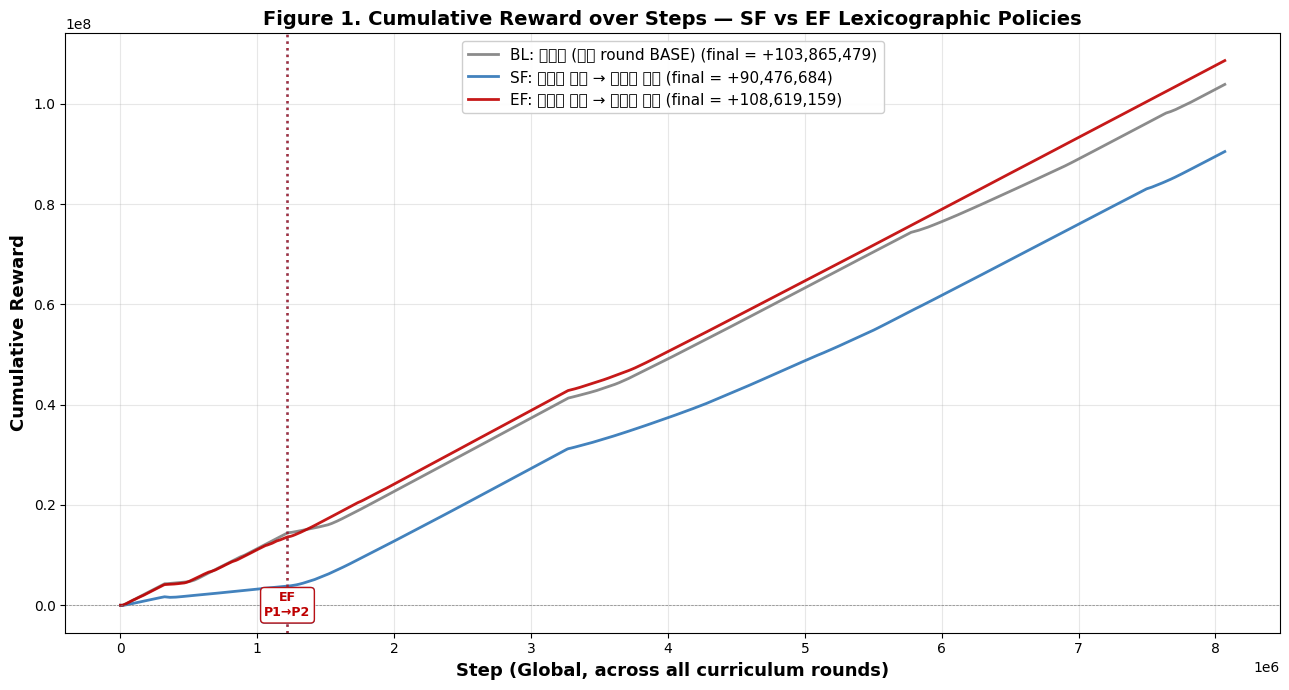

💾 Saved: /content/results/v11_lex_SF_20260606_205650/fig1_cumulative_reward_steps.png

  ── 최종 누적 보상 비교 (3-way) ──
    BL: +103,865,479
    SF: +90,476,684
    EF: +108,619,159
  → 최고: EF (+108,619,159)


In [5]:
# Figure 1: 누적 보상 학습 곡선 (X=Step, Y=Cumulative Reward)
fig, ax = plt.subplots(figsize=(13, 7))

phase_boundaries = {}      # 정책별 Phase 1→2 step 위치
final_cum_rewards = {}     # 정책별 최종 누적 보상

for policy_name, res in all_results.items():
    spec = POLICIES[policy_name]

    # 모든 라운드의 (step, episode_reward) 데이터 추출
    # cb.timesteps 는 reset_num_timesteps=False 로 글로벌 step 카운트
    all_steps   = []
    all_rewards = []
    for cb in res["callbacks"]:
        all_steps.extend(cb.timesteps)
        all_rewards.extend(cb.ep_rewards)

    if not all_steps:
        print(f"  ⚠ {policy_name}: callback data 비어있음")
        continue

    cumulative = np.cumsum(all_rewards)
    final_cum_rewards[policy_name] = cumulative[-1]

    ax.plot(all_steps, cumulative, color=spec["color"], linewidth=2.0, alpha=0.9,
            label=f"{policy_name}: {spec['kor']} (final = {cumulative[-1]:+,.0f})")

    # Phase 1→2 boundary (★ v13: BL은 phase 구분 없으므로 미표시)
    if not spec.get("is_baseline", False):
        n_phase1_rounds = len(spec["phase1_rounds"])
        if 0 < n_phase1_rounds <= len(res["callbacks"]):
            last_p1_cb = res["callbacks"][n_phase1_rounds - 1]
            if last_p1_cb.timesteps:
                boundary_step = last_p1_cb.timesteps[-1]
                phase_boundaries[policy_name] = boundary_step
                ax.axvline(boundary_step, color=spec["color"], linestyle=":",
                           linewidth=1.8, alpha=0.7)
                # Phase 라벨
                ymin, ymax = ax.get_ylim() if ax.get_ylim()[1] != 1 else (-1000, 1000)
                ax.annotate(f"{policy_name}\nP1→P2",
                            xy=(boundary_step, 0), xytext=(boundary_step, 0),
                            fontsize=9, fontweight="bold", color=spec["color"],
                            ha="center", va="center",
                            bbox=dict(boxstyle="round,pad=0.3",
                                      facecolor="white", edgecolor=spec["color"], alpha=0.9))

ax.set_xlabel("Step (Global, across all curriculum rounds)",
              fontsize=13, fontweight="bold")
ax.set_ylabel("Cumulative Reward", fontsize=13, fontweight="bold")
ax.set_title("Figure 1. Cumulative Reward over Steps — SF vs EF Lexicographic Policies",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=11, framealpha=0.95)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()

fig_path = f"{all_loggers['SF'].log_dir}/fig1_cumulative_reward_steps.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {fig_path}")
print()
print("  ── 최종 누적 보상 비교 (3-way) ──")
for pn, fr in final_cum_rewards.items():
    print(f"    {pn}: {fr:+,.0f}")
if final_cum_rewards:
    best = max(final_cum_rewards, key=final_cum_rewards.get)
    print(f"  → 최고: {best} ({final_cum_rewards[best]:+,.0f})")


## 📊 Cell 6: Figure 2 — Per-round Cumulative Reward (Phase 명시)

각 라운드 내 누적 보상을 SF vs EF 비교. 라운드별로 어떤 phase 인지 색 영역으로 표시 →
phase 전환이 보상 곡선의 기울기에 미치는 영향을 시각적으로 확인.

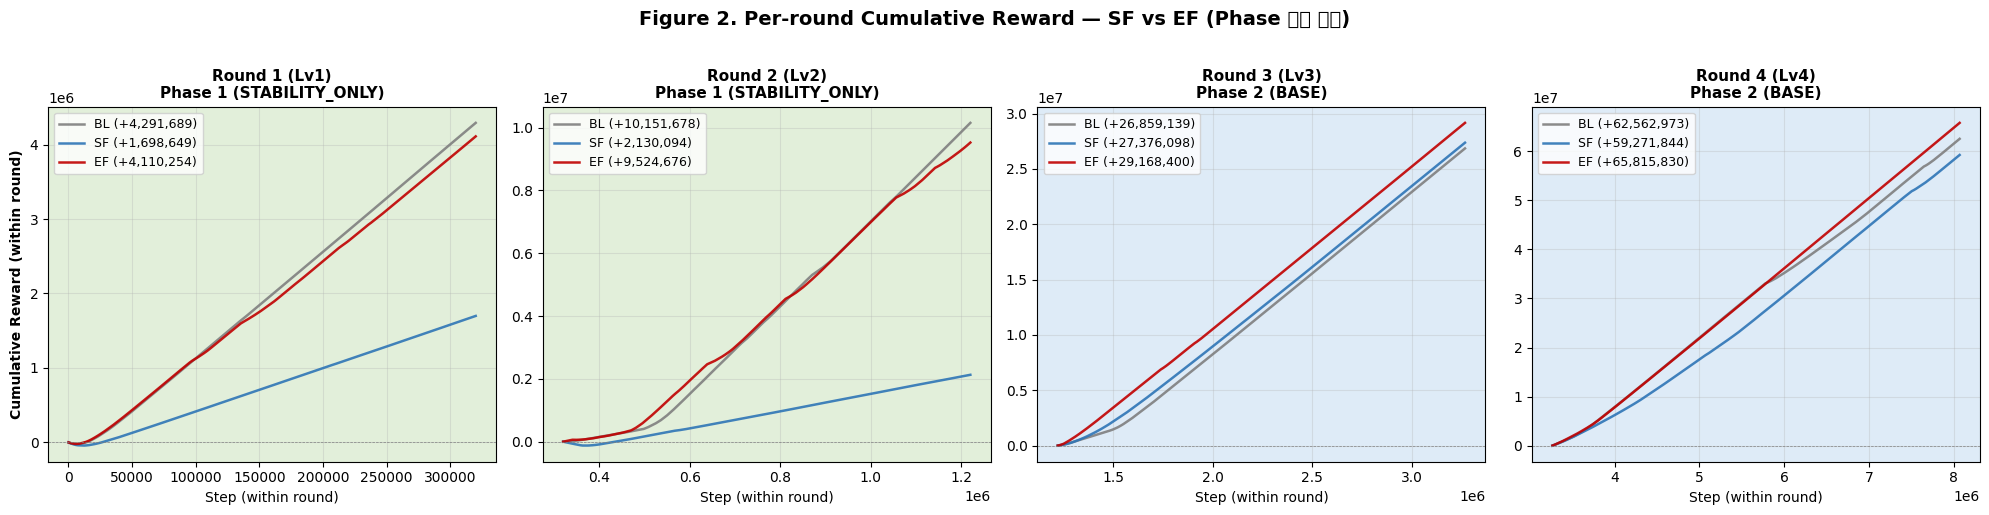

💾 Saved: /content/results/v11_lex_SF_20260606_205650/fig2_per_round_cumulative.png


In [6]:
# Figure 2: 라운드별 누적 보상 (Phase 영역 음영)
n_rounds = CONFIG["total_rounds"]
fig, axes = plt.subplots(1, n_rounds, figsize=(5 * n_rounds, 5), sharey=False)
if n_rounds == 1: axes = [axes]

for rnd in range(n_rounds):
    ax = axes[rnd]
    lv = all_results["SF"]["levels"][rnd]

    # 이 라운드의 phase 표시 (SF 와 EF 의 phase 가 동일하므로 SF 기준)
    sf_phase_info = all_results["SF"]["phase_info"][rnd]
    phase_label = f"Phase {sf_phase_info['phase']} ({sf_phase_info['mode']})"
    bg_color = "#E2EFDA" if sf_phase_info["phase"] == 1 else "#DEEBF7"
    ax.set_facecolor(bg_color)

    for policy_name, res in all_results.items():
        spec = POLICIES[policy_name]
        cb = res["callbacks"][rnd]
        if not cb.ep_rewards: continue
        cumulative = np.cumsum(cb.ep_rewards)
        steps_in_round = cb.timesteps
        final_val = cumulative[-1]
        ax.plot(steps_in_round, cumulative, color=spec["color"], linewidth=1.8,
                label=f"{policy_name} ({final_val:+,.0f})", alpha=0.9)

    ax.set_title(f"Round {rnd+1} (Lv{lv})\n{phase_label}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Step (within round)")
    if rnd == 0:
        ax.set_ylabel("Cumulative Reward (within round)", fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

fig.suptitle("Figure 2. Per-round Cumulative Reward — SF vs EF (Phase 영역 음영)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = f"{all_loggers['SF'].log_dir}/fig2_per_round_cumulative.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {fig_path}")


## 📊 Cell 7: Figure 3 & 4 — KPI Bar Chart + Radar (SF vs EF, Final Round)

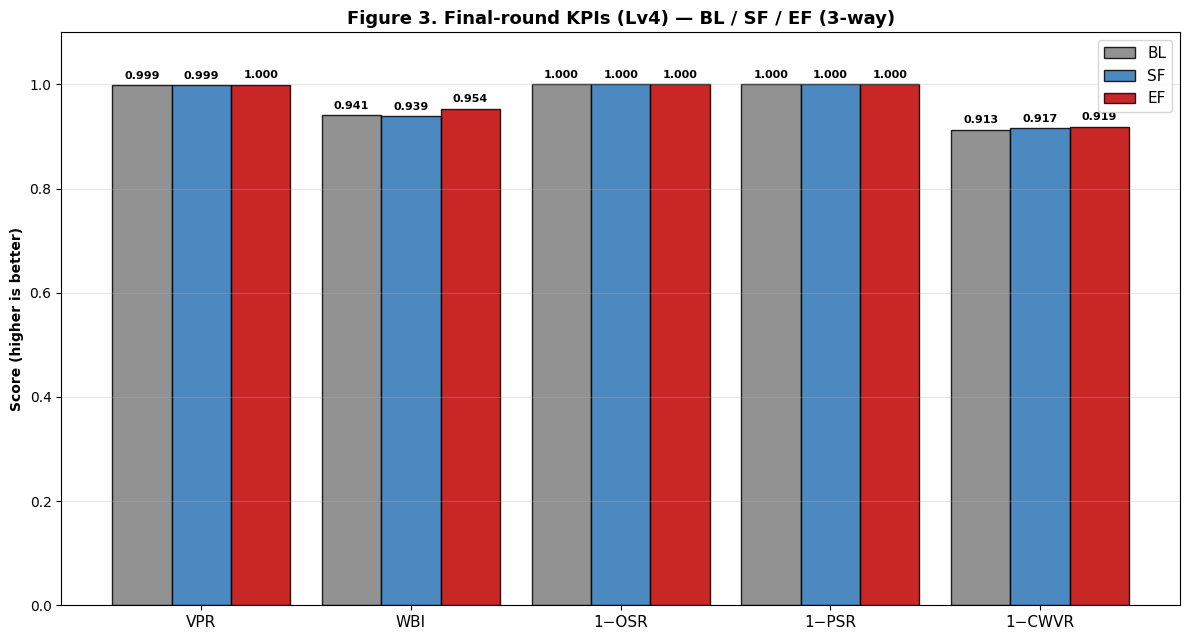

💾 Saved: /content/results/v11_lex_SF_20260606_205650/fig3_kpi_bar.png


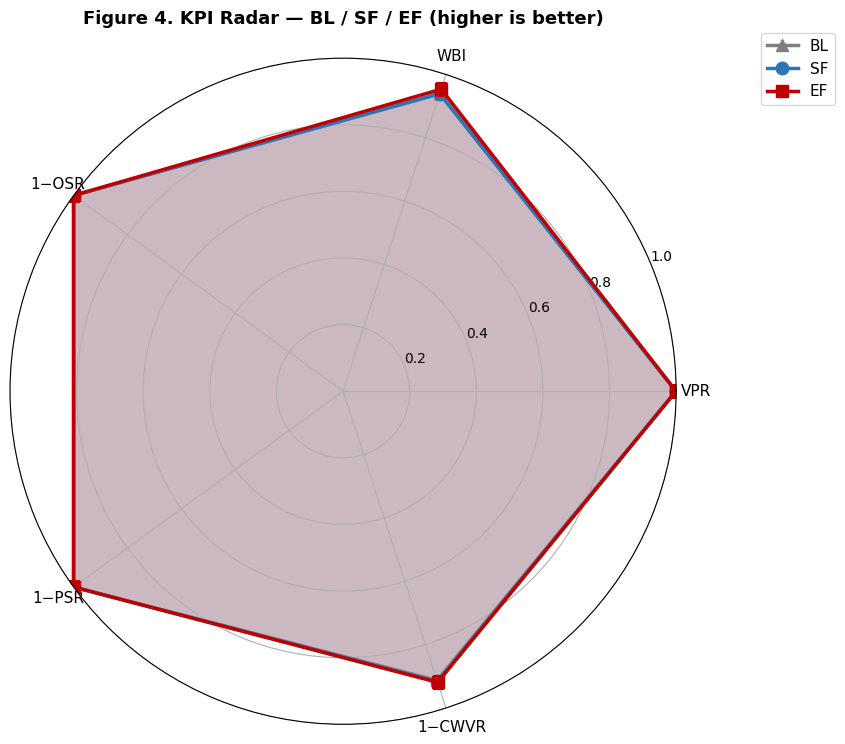

💾 Saved: /content/results/v11_lex_SF_20260606_205650/fig4_radar.png


In [7]:
# Figure 3: 최종 라운드 KPI 막대 그래프
fig3, ax = plt.subplots(figsize=(12, 6.5))
metrics_for_bar = ["VPR", "WBI", "1−OSR", "1−PSR", "1−CWVR"]
n_metrics = len(metrics_for_bar)
n_policies = len(all_results)                         # ★ v13: 3-way 자동 대응
x = np.arange(n_metrics)
bar_width = min(0.32, 0.85 / n_policies)              # 정책 수에 따라 자동 조정

def get_kpi(res, name):
    pm = res["per_round_metrics"][-1]
    return {
        "VPR":     pm["avg_vpr"],
        "WBI":     pm["avg_wbi"],
        "1−OSR":   1.0 - pm["avg_osr"],
        "1−PSR":   1.0 - pm["avg_psr"],
        "1−CWVR":  1.0 - pm.get("avg_cwvr", 0.0),
    }[name]

for i, (pn, res) in enumerate(all_results.items()):
    spec = POLICIES[pn]
    vals = [get_kpi(res, m) for m in metrics_for_bar]
    offset = (i - (n_policies - 1) / 2.0) * bar_width   # ★ n-bar 자동 정렬
    bars = ax.bar(x + offset, vals, bar_width,
                  color=spec["color"], label=pn, edgecolor="black", alpha=0.85)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.012, f"{v:.3f}",
                ha="center", fontsize=8 if n_policies >= 3 else 9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(metrics_for_bar, fontsize=11)
ax.set_ylabel("Score (higher is better)", fontweight="bold")
ax.set_title("Figure 3. Final-round KPIs (Lv4) — BL / SF / EF (3-way)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.legend(loc="upper right", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig3_path = f"{all_loggers['SF'].log_dir}/fig3_kpi_bar.png"
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {fig3_path}")

# Figure 4: Radar
fig4 = plt.figure(figsize=(8.5, 8.5))
ax = fig4.add_subplot(111, projection="polar")
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]
for pn, res in all_results.items():
    spec = POLICIES[pn]
    vals = [get_kpi(res, m) for m in metrics_for_bar]
    vals += vals[:1]
    ax.plot(angles, vals, color=spec["color"], linewidth=2.5,
            marker=spec["marker"], markersize=9, label=pn)
    ax.fill(angles, vals, color=spec["color"], alpha=0.15)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_for_bar, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title("Figure 4. KPI Radar — BL / SF / EF (higher is better)",
             fontsize=13, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), fontsize=11)
ax.grid(True)
plt.tight_layout()
fig4_path = f"{all_loggers['SF'].log_dir}/fig4_radar.png"
plt.savefig(fig4_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {fig4_path}")


## 📊 Cell 8: Figure 5 — Bay Plans (SF and EF, Final Round)


  ── BL Final Bay Plan ──
  💾 Figure saved: /content/results/v11_lex_BL_20260606_143202/fig5_bay_plan_PPO_BL.png


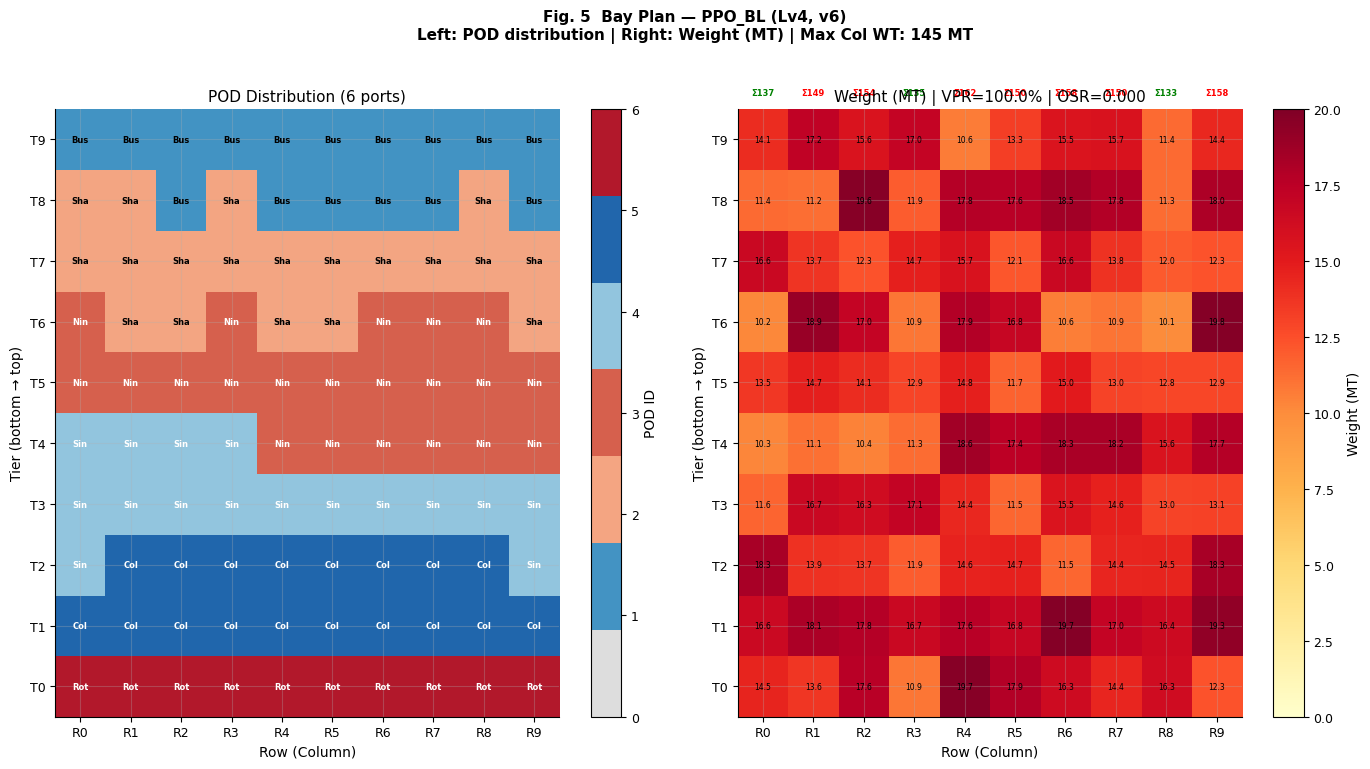


  ──────────────────────────────────────────────────
  Bay Plan Summary — PPO_BL (Lv4)
  ──────────────────────────────────────────────────
  Valid / Invalid        : 100 / 0
  Overstow count         : 0  (OSR=0.000)
  Col Weight Violations  : 8  (CWVR=0.080)
  Empty Rows             : 0
  Valid Placement Rate   : 1.000
  Weight Balance Index   : 0.936
  POD Segregation Rate   : 0.000
  ──────────────────────────────────────────────────
  💾 Saved BL bay plan

  ── SF Final Bay Plan ──
  💾 Figure saved: /content/results/v11_lex_SF_20260606_205650/fig5_bay_plan_PPO_SF.png


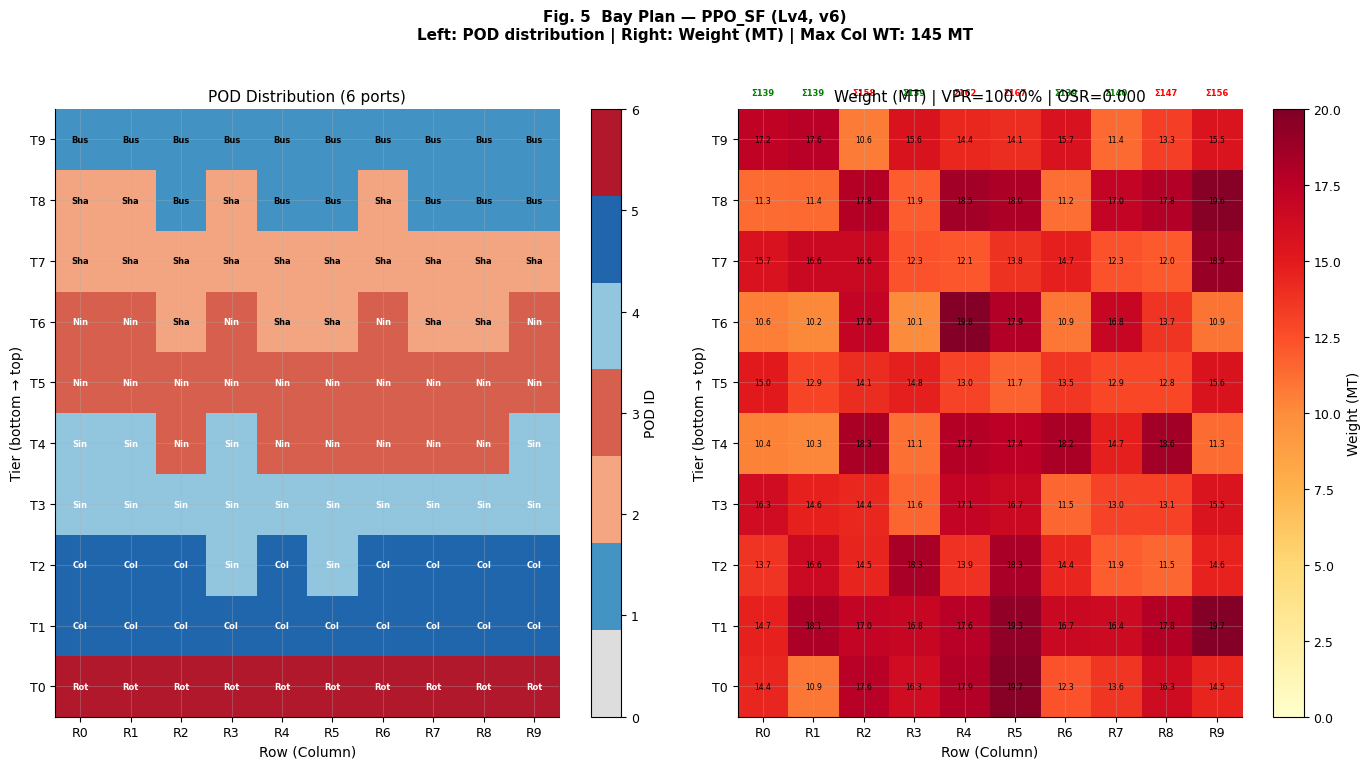


  ──────────────────────────────────────────────────
  Bay Plan Summary — PPO_SF (Lv4)
  ──────────────────────────────────────────────────
  Valid / Invalid        : 100 / 0
  Overstow count         : 0  (OSR=0.000)
  Col Weight Violations  : 8  (CWVR=0.080)
  Empty Rows             : 0
  Valid Placement Rate   : 1.000
  Weight Balance Index   : 0.930
  POD Segregation Rate   : 0.000
  ──────────────────────────────────────────────────
  💾 Saved SF bay plan

  ── EF Final Bay Plan ──
  💾 Figure saved: /content/results/v11_lex_EF_20260607_032140/fig5_bay_plan_PPO_EF.png


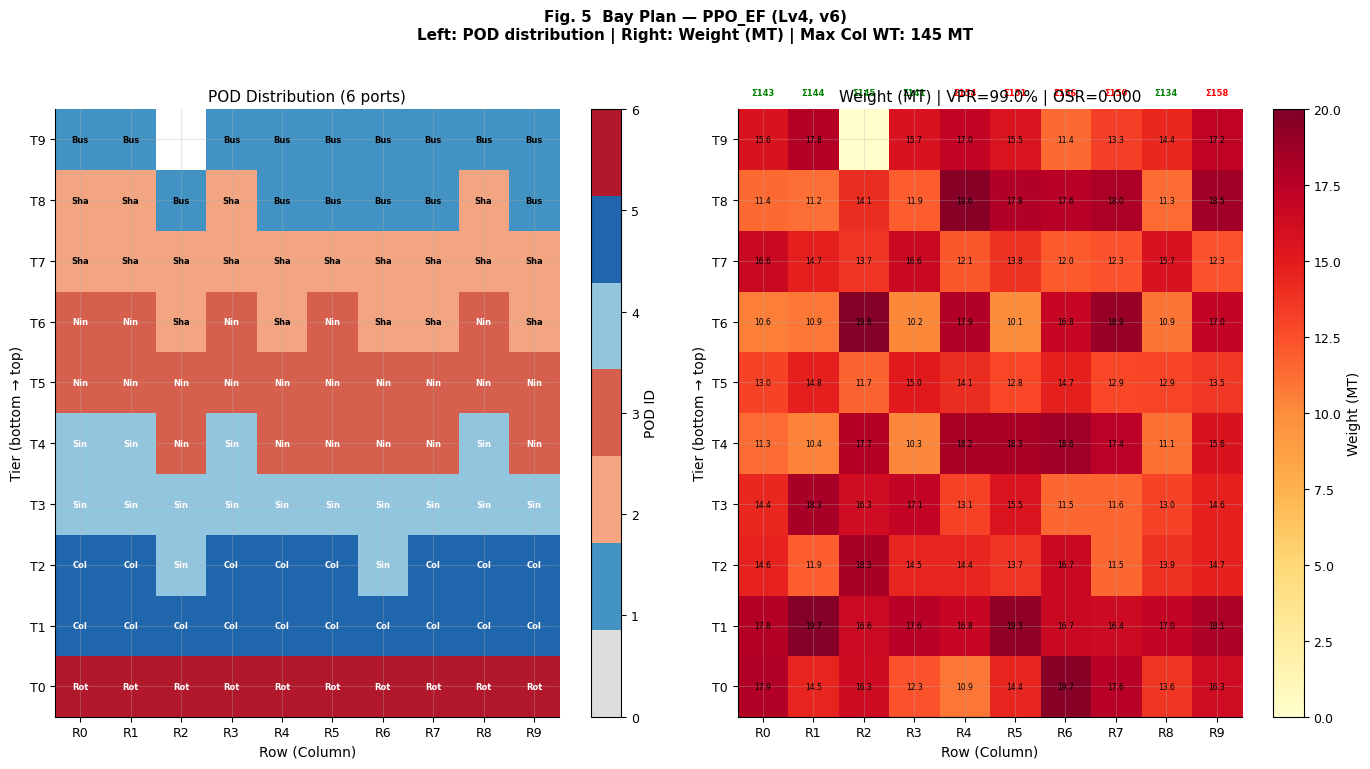


  ──────────────────────────────────────────────────
  Bay Plan Summary — PPO_EF (Lv4)
  ──────────────────────────────────────────────────
  Valid / Invalid        : 99 / 1
  Overstow count         : 0  (OSR=0.000)
  Col Weight Violations  : 5  (CWVR=0.050)
  Empty Rows             : 0
  Valid Placement Rate   : 0.990
  Weight Balance Index   : 0.952
  POD Segregation Rate   : 0.000
  ──────────────────────────────────────────────────
  💾 Saved EF bay plan


In [8]:
# Figure 5: 정책별 최종 라운드 bay plan
for policy_name, res in all_results.items():
    print(f"\n  ── {policy_name} Final Bay Plan ──")
    final_lv = res["levels"][-1]
    fig = plot_bay_plan(res["trained_model"], final_lv,
                         {"rw": res["phase_info"][-1]["rw_snapshot"],
                          **{k: v for k, v in CONFIG.items() if k != "rw"}},
                         all_loggers[policy_name],
                         algo_name=f"PPO_{policy_name}")
    print(f"  💾 Saved {policy_name} bay plan")


## 📊 Cell 8B: Figure 6 — Step-wise Reward Learning Curve (★ v12 신규)

**X축**: Global Step (모든 라운드 누적)  
**Y축**: Episode Reward (per-episode, smoothed by rolling mean)  

Figure 1 (누적 보상) 의 보완 시각화 — 학습 진행에 따른 **실제 정책 성능 추이**를 명확히 표시.
- 옅은 선: raw episode rewards (분산 확인용)
- 진한 선: smoothed (rolling mean) — 학습 트렌드
- 점선: Phase 1→2 전환점 (정책별)
- 상단 박스: Curriculum 레벨 (Lv1→Lv4)

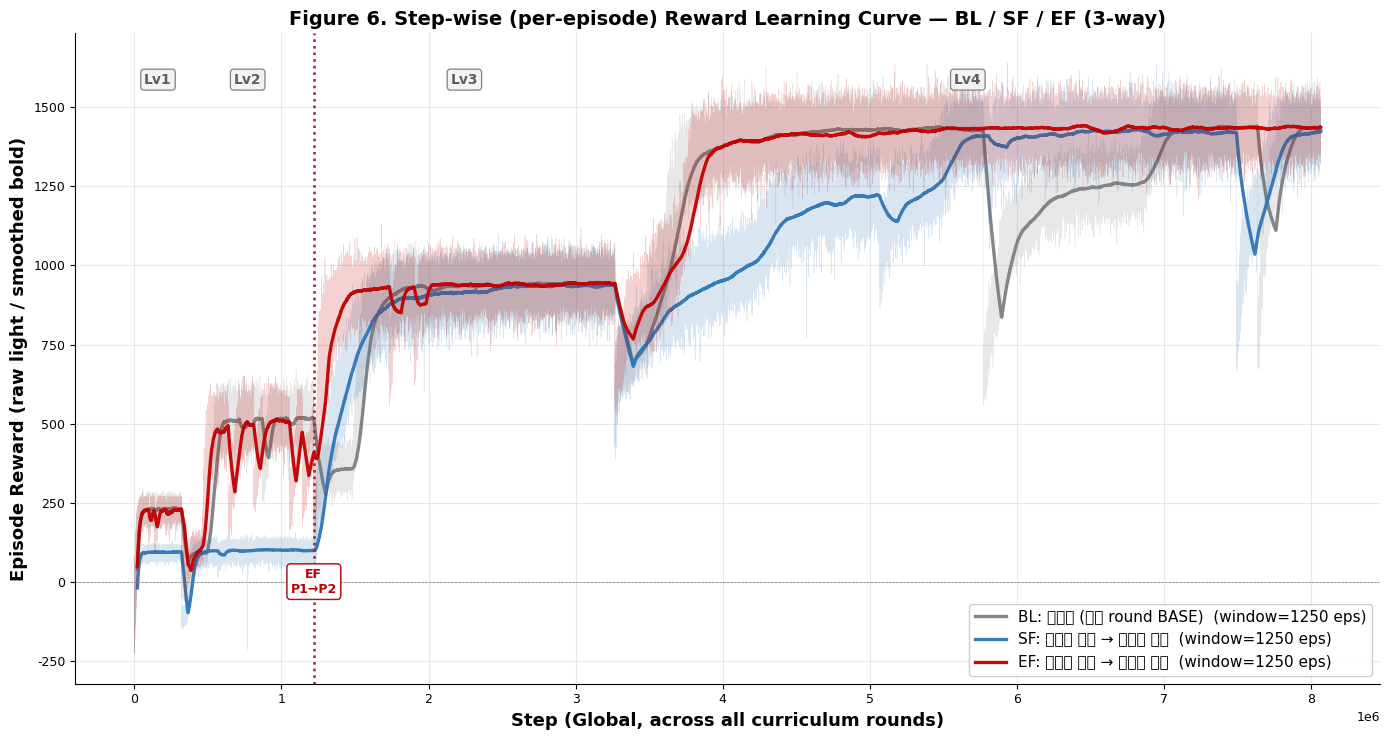

💾 Saved: /content/results/v11_lex_SF_20260606_205650/fig6_stepwise_reward.png

  ── 학습 곡선 진단 (Phase 2 안정성, SF/EF만) ──
    BL: (baseline — phase 전환 없음, skip)
    SF: Phase1 tail =   +99.1  →  Phase2 head =  +100.8  |  ReShock = 0.02 (stable ✓)
    EF: Phase1 tail =  +458.8  →  Phase2 head =  +280.6  |  ReShock = 0.39 (check)


In [9]:
# Figure 6: 스텝별 보상 학습 곡선 (per-episode reward, smoothed)
# - X = Global Step (모든 라운드 누적)
# - Y = Episode Reward (smoothed rolling mean)
# - Phase 1→2 전환점 + Curriculum 레벨 표시
fig, ax = plt.subplots(figsize=(14, 7.5))

y_min_all, y_max_all = float('inf'), float('-inf')

for policy_name, res in all_results.items():
    spec = POLICIES[policy_name]

    # 모든 라운드의 (step, episode_reward) 결합
    all_steps, all_rewards = [], []
    for cb in res["callbacks"]:
        all_steps.extend(cb.timesteps)
        all_rewards.extend(cb.ep_rewards)

    if not all_steps:
        print(f"  ⚠ {policy_name}: callback data 비어있음")
        continue

    steps_arr = np.array(all_steps)
    rew_arr   = np.array(all_rewards)

    # Raw episode rewards (옅은 색, 분산 확인용)
    ax.plot(steps_arr, rew_arr, color=spec["color"],
            linewidth=0.4, alpha=0.18)

    # Smoothed rolling mean (진한 색, 학습 트렌드)
    n_eps = len(rew_arr)
    window = max(50, n_eps // 100)   # adaptive window (~1% of episodes, ≥50)
    if n_eps >= window:
        kernel = np.ones(window) / window
        smoothed = np.convolve(rew_arr, kernel, mode='valid')
        smoothed_x = steps_arr[window-1:]
        ax.plot(smoothed_x, smoothed, color=spec["color"],
                linewidth=2.4, alpha=0.95,
                label=f"{policy_name}: {spec['kor']}  (window={window} eps)")
        y_min_all = min(y_min_all, float(smoothed.min()))
        y_max_all = max(y_max_all, float(smoothed.max()))

    # Phase 1→2 전환 표시 (★ v13: BL은 phase 구분 없으므로 미표시)
    if not spec.get("is_baseline", False):
        n_phase1 = len(spec["phase1_rounds"])
        if 0 < n_phase1 <= len(res["callbacks"]):
            last_p1_cb = res["callbacks"][n_phase1 - 1]
            if last_p1_cb.timesteps:
                boundary = last_p1_cb.timesteps[-1]
                ax.axvline(boundary, color=spec["color"], linestyle=":",
                           linewidth=1.8, alpha=0.7)
                ax.annotate(f"{policy_name}\nP1→P2",
                            xy=(boundary, 0), xytext=(boundary, 0),
                            fontsize=9, fontweight="bold", color=spec["color"],
                            ha="center", va="center",
                            bbox=dict(boxstyle="round,pad=0.3",
                                      facecolor="white", edgecolor=spec["color"], alpha=0.9))

# Curriculum 레벨 박스 (상단)
if y_max_all != float('-inf'):
    y_top = y_max_all + (y_max_all - y_min_all) * 0.08
    sf_res = all_results.get("SF")
    if sf_res:
        cum_start = 0
        for rnd, cb in enumerate(sf_res["callbacks"]):
            if not cb.timesteps: continue
            end_step = cb.timesteps[-1]
            mid = (cum_start + end_step) / 2.0
            ax.text(mid, y_top, f"Lv{sf_res['levels'][rnd]}",
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color='#444444', alpha=0.85,
                    bbox=dict(boxstyle="round,pad=0.25",
                              facecolor="#F2F2F2", edgecolor='gray', alpha=0.9))
            cum_start = end_step

ax.set_xlabel("Step (Global, across all curriculum rounds)",
              fontsize=13, fontweight="bold")
ax.set_ylabel("Episode Reward (raw light / smoothed bold)",
              fontsize=13, fontweight="bold")
ax.set_title("Figure 6. Step-wise (per-episode) Reward Learning Curve — BL / SF / EF (3-way)",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=11, framealpha=0.95)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()

fig_path = f"{all_loggers['SF'].log_dir}/fig6_stepwise_reward.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {fig_path}")

# ── 학습 안정성 진단 출력 (★ v13: BL 제외 — phase 전환이 없음) ──
print()
print("  ── 학습 곡선 진단 (Phase 2 안정성, SF/EF만) ──")
for pn, res in all_results.items():
    spec = POLICIES[pn]
    if spec.get("is_baseline", False):
        print(f"    {pn}: (baseline — phase 전환 없음, skip)")
        continue
    if not res["callbacks"]: continue
    n_p1 = len(spec["phase1_rounds"])
    if n_p1 == 0 or n_p1 >= len(res["callbacks"]): continue
    last_p1_rewards  = res["callbacks"][n_p1 - 1].ep_rewards
    first_p2_rewards = res["callbacks"][n_p1].ep_rewards
    if not last_p1_rewards or not first_p2_rewards: continue
    tail_p1  = float(np.mean(last_p1_rewards[-100:]))
    head_p2  = float(np.mean(first_p2_rewards[:100]))
    shock    = abs(head_p2 - tail_p1) / (abs(tail_p1) + 1e-6)
    print(f"    {pn}: Phase1 tail = {tail_p1:+7.1f}  →  Phase2 head = {head_p2:+7.1f}  "
          f"|  ReShock = {shock:.2f} {'(stable ✓)' if shock < 0.20 else '(check)'}")

## 📊 Cell 9: Performance Summary Table + Hypothesis Verification

In [10]:
# 종합 비교표 + 사전 가설 검증 (★ v13: 3-way 확장)
print("═" * 110)
print("  TABLE: BL / SF / EF — Round-wise Performance with Phase Info")
print("═" * 110)
print(f"  {'Policy':<8} {'Round':<6} {'Level':<6} {'Phase':<6} {'Mode':<18} "
      f"{'Reward':>9} {'OSR':>7} {'VPR':>7} {'WBI':>7} {'PSR':>7} {'CWVR':>7}")
print("  " + "─" * 110)

for pn, res in all_results.items():
    for rnd in range(CONFIG["total_rounds"]):
        pm = res["per_round_metrics"][rnd]
        pi = res["phase_info"][rnd]
        marker = "★" if rnd == CONFIG["total_rounds"] - 1 else " "
        print(f"  {pn:<8} {rnd+1:<6} Lv{pm['level']:<4} {pi['phase']:<6} "
              f"{pi['mode']:<18} {pm['avg_reward']:>+8.2f} "
              f"{pm['avg_osr']:>6.3f} {pm['avg_vpr']:>6.3f} "
              f"{pm['avg_wbi']:>6.3f} {pm['avg_psr']:>6.3f} "
              f"{pm.get('avg_cwvr', 0):>6.3f} {marker}")
    print("  " + "─" * 110)


# ── 일반화된 가설 검증 함수 ──
def hyp_check_pair(name, val_a, val_b, label_a, label_b, predicted, direction):
    """두 정책 간 비교.
    direction: 'high' = 큰 값이 우위, 'low' = 작은 값이 우위
    """
    if direction == "high":
        actual = label_a if val_a > val_b else label_b
    else:
        actual = label_a if val_a < val_b else label_b
    diff = abs(val_a - val_b)
    ok = "✅" if actual == predicted else "❌"
    return (f"  {ok} {name:<34} 가설={predicted:<3} 실제={actual:<3}  "
            f"{label_a}={val_a:.4f}  {label_b}={val_b:.4f}  Δ={diff:.4f}")


# ── 가설 검증 (Lv4 final round) ──
print()
print("═" * 110)
print("  사전 등록 가설 검증 (Final Round Lv4)")
print("═" * 110)

sf_pm = all_results["SF"]["per_round_metrics"][-1]
ef_pm = all_results["EF"]["per_round_metrics"][-1]
bl_pm = all_results["BL"]["per_round_metrics"][-1] if "BL" in all_results else None

# H1~H4: SF vs EF
print("  ── H1~H4: SF vs EF (정책 간 우선순위 비교) ──")
print(hyp_check_pair("H1: WBI (Stability) ↑",    sf_pm["avg_wbi"],  ef_pm["avg_wbi"],  "SF", "EF", "SF", "high"))
print(hyp_check_pair("H2: OSR (Efficiency) ↓",   sf_pm["avg_osr"],  ef_pm["avg_osr"],  "SF", "EF", "EF", "low"))
print(hyp_check_pair("    CWVR (Safety) ↓",      sf_pm.get("avg_cwvr",0), ef_pm.get("avg_cwvr",0), "SF", "EF", "SF", "low"))
print(hyp_check_pair("    PSR ↓ (Eff 영향)",     sf_pm["avg_psr"],  ef_pm["avg_psr"],  "SF", "EF", "EF", "low"))
print(hyp_check_pair("    VPR (Procedural)",     sf_pm["avg_vpr"],  ef_pm["avg_vpr"],  "SF", "EF", "—",  "high"))

# H3: Trade-off 비대칭
wbi_advantage  = sf_pm["avg_wbi"] - ef_pm["avg_wbi"]
osr_advantage  = ef_pm["avg_osr"] - sf_pm["avg_osr"]   # EF.OSR이 작으면 양수 → EF 우위 magnitude
print()
print(f"  H3 (Trade-off 비대칭): SF의 WBI 우위 ({wbi_advantage:+.4f}) vs "
      f"EF의 OSR 우위 ({osr_advantage:+.4f})")
if abs(wbi_advantage) > abs(osr_advantage):
    print(f"      → |WBI Δ| > |OSR Δ| : Stability priority가 더 robust ✓")
else:
    print(f"      → |OSR Δ| > |WBI Δ| : Efficiency priority가 더 robust")

# ★ v13 NEW: H5a, H5b — vs Baseline
if bl_pm is not None:
    print()
    print("  ── ★ H5: vs Baseline (우선순위 부여 효과) ──")
    print(hyp_check_pair("H5a: SF WBI > BL WBI",
                         sf_pm["avg_wbi"], bl_pm["avg_wbi"], "SF", "BL", "SF", "high"))
    print(hyp_check_pair("H5b: EF OSR < BL OSR",
                         ef_pm["avg_osr"], bl_pm["avg_osr"], "EF", "BL", "EF", "low"))
    sf_vs_bl_wbi = sf_pm["avg_wbi"] - bl_pm["avg_wbi"]
    ef_vs_bl_osr = bl_pm["avg_osr"] - ef_pm["avg_osr"]
    print()
    print(f"  H5 효과 크기:")
    print(f"      H5a Δ = SF.WBI − BL.WBI = {sf_vs_bl_wbi:+.4f}  (threshold +0.02)")
    print(f"      H5b Δ = BL.OSR − EF.OSR = {ef_vs_bl_osr:+.4f}  (threshold +0.02)")
    if sf_vs_bl_wbi > 0.02 and ef_vs_bl_osr > 0.02:
        print(f"      → 양 정책 모두 BL 대비 자기 영역 KPI 향상 ✓ (lex priority 유효)")
    elif sf_vs_bl_wbi > 0.02:
        print(f"      → SF만 BL 대비 향상 — Stability priority만 유효")
    elif ef_vs_bl_osr > 0.02:
        print(f"      → EF만 BL 대비 향상 — Efficiency priority만 유효")
    else:
        print(f"      → 두 정책 모두 BL 대비 임계값 미달 — priority 효과 한정적")


# ── 3-way Lv4 종합 ──
print()
print("═" * 110)
print("  3-way 최종 KPI 종합 (Lv4)")
print("═" * 110)
print(f"  {'KPI':<10} {'BL':>10} {'SF':>10} {'EF':>10} {'Best':<6} {'Direction'}")
print("  " + "─" * 70)
kpis = [
    ("Reward",  "avg_reward",  "high"),
    ("VPR",     "avg_vpr",     "high"),
    ("WBI",     "avg_wbi",     "high"),
    ("OSR",     "avg_osr",     "low"),
    ("PSR",     "avg_psr",     "low"),
    ("CWVR",    "avg_cwvr",    "low"),
]
for name, key, direction in kpis:
    bl_v = bl_pm.get(key, 0) if bl_pm else float('nan')
    sf_v = sf_pm.get(key, 0)
    ef_v = ef_pm.get(key, 0)
    vals = {"BL": bl_v, "SF": sf_v, "EF": ef_v}
    if direction == "high":
        best = max(vals, key=vals.get)
    else:
        best = min(vals, key=vals.get)
    arrow = "↑ better" if direction == "high" else "↓ better"
    print(f"  {name:<10} {bl_v:>10.4f} {sf_v:>10.4f} {ef_v:>10.4f}   {best:<6} {arrow}")


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  TABLE: BL / SF / EF — Round-wise Performance with Phase Info
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Policy   Round  Level  Phase  Mode                  Reward     OSR     VPR     WBI     PSR    CWVR
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  BL       1      Lv1    1      BASE                +235.14  0.000  1.000  0.938  0.000  0.000  
  BL       2      Lv2    1      BASE                +516.26  0.000  1.000  0.921  0.000  0.000  
  BL       3      Lv3    2      BASE                +960.68  0.000  1.000  0.935  0.000  0.000  
  BL       4      Lv4    2      BASE               +1462.72  0.000  0.999  0.941  0.000  0.087 ★
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────


## 📊 Cell 10: Reward Components Analysis (BL / SF / EF, Lv4)

In [11]:
# 정책별 보상 항목 분석 (Lv4 평가, BASE 가중치 환경) — ★ v13: 3 정책
print("═" * 80)
print("  BL / SF / EF — Reward Components (R1~R15) at Lv4, evaluated with BASE rewards")
print("═" * 80)

# Lv4 의 phase 2 (BASE) config 으로 평가 → 두 정책의 final policy 차이만 측정
for pn, res in all_results.items():
    print(f"\n  ── {pn}: {POLICIES[pn]['kor']} ──")
    cfg = copy.deepcopy(CONFIG)
    cfg["rw"] = dict(CONFIG["rw"])   # BASE 가중치
    comp = print_reward_component_table(res, cfg, GLOBAL_SEED)

print()
print("  ※ 세 정책 모두 BASE 보상으로 평가 → 학습된 정책 차이만 측정")


════════════════════════════════════════════════════════════════════════════════
  BL / SF / EF — Reward Components (R1~R15) at Lv4, evaluated with BASE rewards
════════════════════════════════════════════════════════════════════════════════

  ── BL: 통제군 (모든 round BASE) ──

  📊 Evaluating reward components...

══════════════════════════════════════════════════════════════════════
  TABLE: Reward Component Breakdown — PPO (Final Round, v6)
══════════════════════════════════════════════════════════════════════
  Component                                   Mean        Std
  ──────────────────────────────────────────────────────────────────
  R1: Valid placement       (+)             +99.87       0.34
  R2: Stack-full penalty    (−)              -1.33       3.40
  R3: Overstow penalty      (−)              +0.00       0.00
  R4: Discharge order        (+)           +193.20       2.11
  R5: Weight balance         (+)           +264.30       2.61
  R6: COG deviation          (−)            

## 💾 Cell 11: Excel Comparison Export + Download

In [12]:
# v13 BL / SF / EF 3-way 비교 Excel 저장
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment

def save_v13_comparison_excel(all_results, all_loggers, base_log_dir):
    wb = Workbook()
    HF = Font(bold=True, color="FFFFFF", size=10)
    HFILL = PatternFill("solid", fgColor="1F3864")
    CTR = Alignment(horizontal="center", vertical="center")

    # Sheet 1: Round_Summary (BL + SF + EF × 4 라운드)
    ws1 = wb.active; ws1.title = "Round_Summary"
    headers = ["Policy", "Round", "Level", "Phase", "Mode",
               "Reward", "Std", "OSR", "VPR", "WBI", "PSR", "CWVR",
               "Episodes", "Steps", "TrainTime(min)"]
    for c, h in enumerate(headers, 1):
        cell = ws1.cell(row=1, column=c, value=h)
        cell.font, cell.fill, cell.alignment = HF, HFILL, CTR

    r = 2
    for pn, res in all_results.items():
        for rnd in range(CONFIG["total_rounds"]):
            pm = res["per_round_metrics"][rnd]
            pi = res["phase_info"][rnd]
            row = [
                pn, rnd+1, f"Lv{pm['level']}", pi["phase"], pi["mode"],
                round(pm["avg_reward"], 2), round(pm["std_reward"], 2),
                round(pm["avg_osr"], 4), round(pm["avg_vpr"], 4),
                round(pm["avg_wbi"], 4), round(pm["avg_psr"], 4),
                round(pm.get("avg_cwvr", 0), 4),
                pm.get("actual_episodes", 0), pm.get("actual_steps", 0),
                round(pm.get("train_seconds", 0)/60, 1),
            ]
            for c, v in enumerate(row, 1):
                ws1.cell(row=r, column=c, value=v).alignment = CTR
            r += 1

    # Sheet 2: Lv4 ThreeWay (★ v13: BL/SF/EF 3-way 비교)
    ws2 = wb.create_sheet("Lv4_ThreeWay")
    ws2.cell(row=1, column=1, value="Final Round (Lv4) — BL / SF / EF (3-way)").font = Font(bold=True, size=12)
    ws2.merge_cells("A1:F1")
    for c, h in enumerate(["Metric", "BL", "SF", "EF", "Best", "Direction"], 1):
        cell = ws2.cell(row=3, column=c, value=h)
        cell.font, cell.fill, cell.alignment = HF, HFILL, CTR

    KPIS = [
        ("Reward",       "avg_reward", "high"),
        ("VPR",          "avg_vpr",    "high"),
        ("WBI",          "avg_wbi",    "high"),
        ("OSR",          "avg_osr",    "low"),
        ("PSR",          "avg_psr",    "low"),
        ("CWVR",         "avg_cwvr",   "low"),
    ]
    for i, (name, key, direction) in enumerate(KPIS):
        bl_v = all_results["BL"]["per_round_metrics"][-1].get(key, 0) if "BL" in all_results else float('nan')
        sf_v = all_results["SF"]["per_round_metrics"][-1].get(key, 0)
        ef_v = all_results["EF"]["per_round_metrics"][-1].get(key, 0)
        vals = {"BL": bl_v, "SF": sf_v, "EF": ef_v}
        if direction == "high":
            best = max(vals, key=vals.get)
        else:
            best = min(vals, key=vals.get)
        ws2.cell(row=4+i, column=1, value=name).font = Font(bold=True)
        ws2.cell(row=4+i, column=2, value=round(bl_v, 4)).alignment = CTR
        ws2.cell(row=4+i, column=3, value=round(sf_v, 4)).alignment = CTR
        ws2.cell(row=4+i, column=4, value=round(ef_v, 4)).alignment = CTR
        wc = ws2.cell(row=4+i, column=5, value=best)
        wc.font = Font(bold=True, color="C00000"); wc.alignment = CTR
        ws2.cell(row=4+i, column=6, value="↑ better" if direction=="high" else "↓ better").alignment = CTR

    # Sheet 3: H5 Tests (★ v13: vs Baseline 가설 검증)
    ws_h5 = wb.create_sheet("H5_Tests")
    ws_h5.cell(row=1, column=1, value="H5: 우선순위 부여 효과 (vs Baseline)").font = Font(bold=True, size=12)
    ws_h5.merge_cells("A1:F1")
    for c, h in enumerate(["Hypothesis", "KPI", "Policy", "Policy Val", "BL Val", "Δ (vs BL)", "Threshold", "Pass"], 1):
        cell = ws_h5.cell(row=3, column=c, value=h)
        cell.font, cell.fill, cell.alignment = HF, HFILL, CTR

    if "BL" in all_results:
        bl_lv4 = all_results["BL"]["per_round_metrics"][-1]
        sf_lv4 = all_results["SF"]["per_round_metrics"][-1]
        ef_lv4 = all_results["EF"]["per_round_metrics"][-1]
        h5_tests = [
            ("H5a", "WBI", "SF", sf_lv4["avg_wbi"], bl_lv4["avg_wbi"],
             sf_lv4["avg_wbi"] - bl_lv4["avg_wbi"], "+0.02"),
            ("H5b", "OSR", "EF", ef_lv4["avg_osr"], bl_lv4["avg_osr"],
             bl_lv4["avg_osr"] - ef_lv4["avg_osr"], "+0.02"),
        ]
        for i, (hyp, kpi, pol, pv, blv, delta, thr) in enumerate(h5_tests):
            passed = "✓ Pass" if delta > 0.02 else "✗ Fail"
            row = [hyp, kpi, pol, round(pv, 4), round(blv, 4), round(delta, 4), thr, passed]
            for c, v in enumerate(row, 1):
                cell = ws_h5.cell(row=4+i, column=c, value=v)
                cell.alignment = CTR
                if c == 8:
                    cell.font = Font(bold=True, color="00B050" if "Pass" in passed else "C00000")

    # Sheet 4: Phase_Info (정책별 phase 별 활성 보상)
    ws3 = wb.create_sheet("Phase_Info")
    for c, h in enumerate(["Policy", "Round", "Level", "Phase", "Mode",
                            "N_Active_Rewards"], 1):
        cell = ws3.cell(row=1, column=c, value=h)
        cell.font, cell.fill, cell.alignment = HF, HFILL, CTR
    r = 2
    for pn, res in all_results.items():
        for pi in res["phase_info"]:
            row = [pn, pi["round"], f"Lv{pi['level']}", pi["phase"], pi["mode"],
                   pi["n_active_rewards"]]
            for c, v in enumerate(row, 1):
                ws3.cell(row=r, column=c, value=v).alignment = CTR
            r += 1

    # Sheet 5: Config
    ws4 = wb.create_sheet("Config")
    items = [
        ("Version", "v13 Lexicographic 3-way BL/SF/EF (rebalanced, 8M steps, 1-seed pilot)"),
        ("Seed", GLOBAL_SEED),
        ("N Policies", len(POLICIES)),
        ("Total Episodes/Policy", sum(CONFIG["episodes_per_level"].values())),
        ("Total Episodes (All)", sum(CONFIG["episodes_per_level"].values()) * len(POLICIES)),
        ("Phase 1 Rounds (SF/EF)", str(POLICIES["SF"]["phase1_rounds"])),
        ("Phase 2 Rounds (SF/EF)", str(POLICIES["SF"]["phase2_rounds"])),
        ("SF Phase1 Mode", POLICIES["SF"]["phase1_mode"]),
        ("EF Phase1 Mode", POLICIES["EF"]["phase1_mode"]),
        ("BL Mode (all rounds)", "BASE (Operational + Stability + Efficiency 모두 활성)"),
        ("Both Phase2 Mode (SF/EF)", "BASE (모든 R1~R15 활성)"),
        ("PPO LR", CONFIG["ppo"]["lr"]),
        ("PPO net_arch", str(CONFIG["ppo"]["net_arch"])),
        ("R5 weight_balance",     CONFIG["rw"]["weight_balance"]),
        ("R6 cog_penalty",        CONFIG["rw"]["cog_penalty"]),
        ("R11 wt_inversion_penalty", CONFIG["rw"]["wt_inversion_penalty"]),
    ]
    for i, (k, v) in enumerate(items, 1):
        ws4.cell(row=i, column=1, value=k).font = Font(bold=True)
        ws4.cell(row=i, column=2, value=str(v))
    ws4.column_dimensions["A"].width = 28
    ws4.column_dimensions["B"].width = 56

    out = f"{base_log_dir}/v13_3way_results.xlsx"
    wb.save(out)
    return out


# ── Excel + ZIP 다운로드 ──
print("📊 Saving v13 3-way (BL/SF/EF) comparison Excel...")
xlsx_path = save_v13_comparison_excel(all_results, all_loggers,
                                       all_loggers["SF"].log_dir)
print(f"  💾 {xlsx_path}")

# 정책별 개별 Excel (v8 형식)
print()
print("📊 Saving per-policy Excels (v8 format)...")
per_pol_xlsx = []
for pn in POLICIES:
    cfg = copy.deepcopy(CONFIG)
    cfg["experiment_name"] = f"v13_3way_{pn}"
    p = save_results_to_excel(all_results[pn], cfg, GLOBAL_SEED, all_loggers[pn])
    per_pol_xlsx.append(p)

# ZIP 묶기
import shutil
zip_dir = "/content/v13_3way_results"
os.makedirs(zip_dir, exist_ok=True)
for pn, lg in all_loggers.items():
    sub = os.path.join(zip_dir, pn)
    os.makedirs(sub, exist_ok=True)
    for f in os.listdir(lg.log_dir):
        src = os.path.join(lg.log_dir, f)
        if os.path.isfile(src):
            shutil.copy2(src, sub)

zip_path = "/content/v13_3way_BL_SF_EF.zip"
shutil.make_archive(zip_path.replace(".zip", ""), "zip", zip_dir)
print(f"\n📦 Bundle: {zip_path}")

# 다운로드
print()
print("⬇  Downloading...")
from google.colab import files
files.download(xlsx_path)
files.download(zip_path)

print()
print("=" * 70)
print("  ✅ v13 3-way Lexicographic Pilot 완료")
print(f"  최종 누적 보상 (Step 기준):")
for pn, fr in final_cum_rewards.items():
    print(f"    {pn}: {fr:+,.0f}")
print(f"  가설 검증 결과는 Cell 9 출력 참조")
print("=" * 70)


📊 Saving v13 3-way (BL/SF/EF) comparison Excel...
  💾 /content/results/v11_lex_SF_20260606_205650/v13_3way_results.xlsx

📊 Saving per-policy Excels (v8 format)...

  📊 Excel saved: /content/results/v11_lex_BL_20260606_143202/ppo_results_v6.xlsx

  📊 Excel saved: /content/results/v11_lex_SF_20260606_205650/ppo_results_v6.xlsx

  📊 Excel saved: /content/results/v11_lex_EF_20260607_032140/ppo_results_v6.xlsx

📦 Bundle: /content/v13_3way_BL_SF_EF.zip

⬇  Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  ✅ v13 3-way Lexicographic Pilot 완료
  최종 누적 보상 (Step 기준):
    BL: +103,865,479
    SF: +90,476,684
    EF: +108,619,159
  가설 검증 결과는 Cell 9 출력 참조


## 💾 Cell 12: 학습 완료 모델 저장 (BL / SF / EF) — ★ NEW

In [13]:
# ══════════════════════════════════════════════════════════════════
#  ★ NEW: 학습 완료 모델 저장 (BL / SF / EF 3 정책)
#   · 기존 학습 결과(all_results)의 trained_model 을 .zip 으로 저장
#   · Stable-Baselines3 PPO.save() → 추후 PPO.load() 로 재사용 가능
#   · Colab 사용 시 files.download() 로 로컬 다운로드까지 지원
# ══════════════════════════════════════════════════════════════════
import os, zipfile

MODEL_DIR = "/content/results/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("═" * 70)
print("  💾 학습 완료 모델 저장 (PPO, 3-way: BL / SF / EF)")
print("═" * 70)

saved_model_paths = {}
for pol_name, res in all_results.items():
    model_obj = res.get("trained_model", None)
    if model_obj is None:
        print(f"  ⚠️  {pol_name}: trained_model 이 None — 저장 건너뜀")
        continue

    # 파일명: 실험명 + 정책명 + seed
    fname = f"{CONFIG['experiment_name']}_{pol_name}_seed{GLOBAL_SEED}"
    fpath = os.path.join(MODEL_DIR, fname)            # SB3 가 .zip 자동 부착
    model_obj.save(fpath)
    zip_path = fpath + ".zip"
    size_mb  = os.path.getsize(zip_path) / 1e6
    saved_model_paths[pol_name] = zip_path
    print(f"  ✅ {pol_name:<3} 저장 완료 → {os.path.basename(zip_path)}  ({size_mb:.2f} MB)")
    print(f"        Phase1={POLICIES[pol_name]['phase1_mode']:<15} "
          f"Phase2={POLICIES[pol_name]['phase2_mode']:<6} "
          f"FinalReward(Lv4)={res['avg_rewards'][-1]:+.2f}")

# ── 3개 모델을 하나의 zip 으로 묶기 (배포/백업용) ──
bundle_path = os.path.join(MODEL_DIR,
                           f"{CONFIG['experiment_name']}_ALL_models_seed{GLOBAL_SEED}.zip")
if saved_model_paths:
    with zipfile.ZipFile(bundle_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for pol_name, p in saved_model_paths.items():
            zf.write(p, arcname=os.path.basename(p))
    print()
    print(f"  📦 통합 번들 생성 → {os.path.basename(bundle_path)} "
          f"({os.path.getsize(bundle_path)/1e6:.2f} MB)")

print()
print("  ── 재사용 예시 (추론/추가학습) ──")
print("    from stable_baselines3 import PPO")
print(f"    model = PPO.load('{MODEL_DIR}/{CONFIG['experiment_name']}_SF_seed{GLOBAL_SEED}.zip')")
print("    # model.set_env(eval_env)  # 추가 학습 시")

# ── Colab 다운로드 (개별 + 번들) ──
try:
    from google.colab import files
    print()
    print("  ⬇️  Colab 다운로드 시작 (브라우저)…")
    if saved_model_paths:
        files.download(bundle_path)        # 번들 다운로드
    print("  ✅ 다운로드 트리거 완료")
except Exception as e:
    print(f"  ℹ️  (로컬/비Colab 환경) 다운로드 생략 — 저장 경로: {MODEL_DIR}")


══════════════════════════════════════════════════════════════════════
  💾 학습 완료 모델 저장 (PPO, 3-way: BL / SF / EF)
══════════════════════════════════════════════════════════════════════
  ✅ BL  저장 완료 → single_bay_6pod_ppo_v13_3way_BL_seed42.zip  (4.98 MB)
        Phase1=BASE            Phase2=BASE   FinalReward(Lv4)=+1462.72
  ✅ SF  저장 완료 → single_bay_6pod_ppo_v13_3way_SF_seed42.zip  (4.98 MB)
        Phase1=STABILITY_ONLY  Phase2=BASE   FinalReward(Lv4)=+1446.18
  ✅ EF  저장 완료 → single_bay_6pod_ppo_v13_3way_EF_seed42.zip  (4.98 MB)
        Phase1=EFFICIENCY_ONLY Phase2=BASE   FinalReward(Lv4)=+1464.51

  📦 통합 번들 생성 → single_bay_6pod_ppo_v13_3way_ALL_models_seed42.zip (13.21 MB)

  ── 재사용 예시 (추론/추가학습) ──
    from stable_baselines3 import PPO
    model = PPO.load('/content/results/models/single_bay_6pod_ppo_v13_3way_SF_seed42.zip')
    # model.set_env(eval_env)  # 추가 학습 시

  ⬇️  Colab 다운로드 시작 (브라우저)…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ 다운로드 트리거 완료


## 📊 Cell 13: 라운드별 POD/Weight 분포 + 선적순서 Excel — ★ NEW

In [14]:
# ══════════════════════════════════════════════════════════════════
#  ★ NEW: 라운드별 입력 데이터 시각화 Excel
#   · 첨부 이미지 형식 — ① POD 분포(grid)  ② Weight 분포(grid)  ③ 선적순서 리스트
#   · ★ 입력 컨테이너는 정책과 무관 (env.reset 의 seed 만 의존) → 1회만 생성
#   · 표시 대상: 각 라운드의 "대표 1개 에피소드" (eval ep=0, eval_seed=GLOBAL_SEED)
#   · grid 배치는 env 의 적재 결과가 아닌 "입력 순서를 그대로 채운 참조 배치"가 아니라,
#     실제 SF 정책 최종 bay plan(per_round_bay_plans)을 사용해 적재 위치를 표현
# ══════════════════════════════════════════════════════════════════
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# ── POD 색상 팔레트 (env / 기존 Excel 과 동일) ──
POD_FILLS = {
    1: "4393C3", 2: "F4A582", 3: "D6604D",
    4: "92C5DE", 5: "2166AC", 6: "B2182B",
}
POD_FONT_WHITE = {3, 5, 6}   # 진한 배경 → 흰 글씨

# ── Weight heatmap 색상 (저=초록 / 중=노랑 / 고=빨강) ──
def _wt_fill(w, wmin, wmax):
    if wmax - wmin < 1e-6:
        return "C6EFCE"
    t = (w - wmin) / (wmax - wmin)
    if t < 0.34:   return "C6EFCE"   # green
    elif t < 0.67: return "FFEB9C"   # yellow
    else:          return "FFC7CE"   # red

hdr_font   = Font(bold=True, color="FFFFFF", size=10)
blue_fill  = PatternFill("solid", fgColor="4472C4")
sect_font  = Font(bold=True, size=11)
center     = Alignment(horizontal="center", vertical="center")
thin       = Border(*[Side(style="thin")] * 4)
green_font = Font(bold=True, color="008000", size=10)

def _bay_plan_from_env(seed_for_ep, level, config):
    """대표 에피소드의 입력 컨테이너 + (정책 적재 없이) 입력 순서 메타 재생성.

    실제 적재 grid 는 SF 정책 결과(per_round_bay_plans)를 사용하고,
    선적순서 리스트는 env.reset 의 deterministic 시퀀스로 재생성한다.
    """
    env = make_env(level=level, config=config)
    env.reset(seed=seed_for_ep)
    return env.ctns_pod.copy(), env.ctns_wt.copy(), env.n_rows, env.n_tiers

wb = Workbook()
wb.remove(wb.active)

# 입력 데이터는 정책 무관 → SF 결과의 bay plan(적재 위치)을 표현용으로 사용
ref_res = all_results.get("SF", next(iter(all_results.values())))

for rnd_idx in range(CONFIG["total_rounds"]):
    lv     = ref_res["levels"][rnd_idx]
    lv_cfg = CONFIG["levels"][lv]
    n_rows, n_tiers = lv_cfg["n_rows"], lv_cfg["n_tiers"]

    # 대표 에피소드 = eval ep0 (seed = GLOBAL_SEED + 0*17 = GLOBAL_SEED)
    rep_seed = GLOBAL_SEED + 0 * 17
    ctns_pod, ctns_wt, _, _ = _bay_plan_from_env(rep_seed, lv, CONFIG)

    # 실제 적재 grid (SF 정책 최종 라운드 bay plan)
    bp = ref_res["per_round_bay_plans"][rnd_idx]
    pod_grid = bp["pod_grid"]     # (n_rows, n_tiers)
    wt_grid  = bp["wt_grid"]
    stack_h  = bp["stack_h"]

    ws = wb.create_sheet(f"R{rnd_idx+1}_Lv{lv}")
    ws.sheet_view.showGridLines = False

    # ── 제목 ──
    ncol = n_rows + 2
    ws.merge_cells(start_row=1, start_column=2, end_row=1, end_column=ncol)
    t = ws.cell(row=1, column=2,
                value=f"Round {rnd_idx+1} (Lv{lv}) — Bay Plan: {n_rows}R × {n_tiers}T")
    t.font = Font(bold=True, size=13); t.alignment = center
    t.fill = PatternFill("solid", fgColor="FFFFFF")
    t.border = Border(top=Side(style="medium"), bottom=Side(style="medium"),
                      left=Side(style="medium"), right=Side(style="medium"))

    r0 = 3   # 현재 작성 행 포인터

    # ════════ ① POD 분포 ════════
    ws.cell(row=r0, column=1, value="【POD 분포】").font = sect_font
    r0 += 1
    # 헤더: Tier\Row | R0..Rn | Col ΣWT
    c = ws.cell(row=r0, column=1, value="Tier\\Row"); c.font = hdr_font; c.fill = blue_fill; c.alignment = center; c.border = thin
    for rr in range(n_rows):
        c = ws.cell(row=r0, column=2 + rr, value=f"R{rr}")
        c.font = hdr_font; c.fill = blue_fill; c.alignment = center; c.border = thin
    c = ws.cell(row=r0, column=2 + n_rows, value="Col ΣWT")
    c.font = hdr_font; c.fill = PatternFill("solid", fgColor="8FAADC"); c.alignment = center; c.border = thin
    r0 += 1
    # Tier 행 (위→아래: 최상단 tier 부터)
    pod_top_row = r0
    for t_disp in range(n_tiers - 1, -1, -1):
        c = ws.cell(row=r0, column=1, value=f"T{t_disp}")
        c.font = hdr_font; c.fill = blue_fill; c.alignment = center; c.border = thin
        for rr in range(n_rows):
            pod = int(pod_grid[rr, t_disp]) if t_disp < int(stack_h[rr]) else 0
            cell = ws.cell(row=r0, column=2 + rr)
            cell.alignment = center; cell.border = thin
            if pod > 0:
                cell.value = f"{POD_NAMES[pod][:3]}({pod})"
                cell.fill  = PatternFill("solid", fgColor=POD_FILLS[pod])
                cell.font  = Font(bold=True, size=9,
                                  color="FFFFFF" if pod in POD_FONT_WHITE else "000000")
            else:
                cell.value = "—"
                cell.fill  = PatternFill("solid", fgColor="EFEFEF")
                cell.font  = Font(size=9, color="808080")
        r0 += 1
    # Col ΣWT 행
    c = ws.cell(row=r0, column=1, value="Col ΣWT")
    c.font = hdr_font; c.fill = blue_fill; c.alignment = center; c.border = thin
    for rr in range(n_rows):
        col_wt = float(wt_grid[rr, :int(stack_h[rr])].sum())
        cc = ws.cell(row=r0, column=2 + rr, value=round(col_wt, 1))
        cc.font = green_font; cc.alignment = center; cc.border = thin
    r0 += 2

    # ════════ ② Weight 분포 (MT) ════════
    ws.cell(row=r0, column=1, value="【Weight 분포 (MT)】").font = sect_font
    r0 += 1
    c = ws.cell(row=r0, column=1, value="Tier\\Row"); c.font = hdr_font; c.fill = blue_fill; c.alignment = center; c.border = thin
    for rr in range(n_rows):
        c = ws.cell(row=r0, column=2 + rr, value=f"R{rr}")
        c.font = hdr_font; c.fill = blue_fill; c.alignment = center; c.border = thin
    r0 += 1
    # heatmap 범위
    occ_wts = [float(wt_grid[rr, t]) for rr in range(n_rows)
               for t in range(int(stack_h[rr]))]
    wmin = min(occ_wts) if occ_wts else 0.0
    wmax = max(occ_wts) if occ_wts else 1.0
    for t_disp in range(n_tiers - 1, -1, -1):
        c = ws.cell(row=r0, column=1, value=f"T{t_disp}")
        c.font = hdr_font; c.fill = blue_fill; c.alignment = center; c.border = thin
        for rr in range(n_rows):
            cell = ws.cell(row=r0, column=2 + rr)
            cell.alignment = center; cell.border = thin
            if t_disp < int(stack_h[rr]):
                w = float(wt_grid[rr, t_disp])
                cell.value = round(w, 1)
                cell.fill  = PatternFill("solid", fgColor=_wt_fill(w, wmin, wmax))
                cell.font  = Font(size=9)
            else:
                cell.value = "—"
                cell.fill  = PatternFill("solid", fgColor="EFEFEF")
                cell.font  = Font(size=9, color="808080")
        r0 += 1
    r0 += 2

    # ════════ ③ 선적 순서 리스트 ════════
    ws.cell(row=r0, column=1, value="【선적 순서 리스트】").font = sect_font
    r0 += 1
    list_hdrs = ["순번", "POD ID", "POD Name", "Weight (MT)"]
    for col, h in enumerate(list_hdrs, 1):
        c = ws.cell(row=r0, column=col, value=h)
        c.font = hdr_font; c.fill = blue_fill; c.alignment = center; c.border = thin
    r0 += 1
    for i in range(len(ctns_pod)):
        pod = int(ctns_pod[i]); w = float(ctns_wt[i])
        ws.cell(row=r0, column=1, value=i + 1).alignment = center
        ws.cell(row=r0, column=2, value=pod).alignment = center
        ws.cell(row=r0, column=3, value=POD_NAMES[pod]).alignment = center
        ws.cell(row=r0, column=4, value=round(w, 1)).alignment = center
        for col in range(1, 5):
            ws.cell(row=r0, column=col).border = thin
        r0 += 1

    # ── 컬럼 너비 ──
    ws.column_dimensions["A"].width = 12
    for rr in range(n_rows):
        from openpyxl.utils import get_column_letter
        ws.column_dimensions[get_column_letter(2 + rr)].width = 11
    from openpyxl.utils import get_column_letter
    ws.column_dimensions[get_column_letter(2 + n_rows)].width = 10

dist_path = f"/content/results/{CONFIG['experiment_name']}_BayPlan_Distributions_seed{GLOBAL_SEED}.xlsx"
wb.save(dist_path)
print("═" * 70)
print("  📊 라운드별 분포 Excel 저장 완료")
print("═" * 70)
print(f"  파일: {dist_path}")
_sheet_names = [f"R{i+1}_Lv" + str(ref_res["levels"][i]) for i in range(CONFIG["total_rounds"])]
print(f"  시트: {_sheet_names}")
print(f"  내용: ① POD 분포 grid  ② Weight 분포 heatmap  ③ 선적순서 리스트")
print(f"  ※ 적재 grid = SF 정책 최종 bay plan / 선적순서 = deterministic 입력 시퀀스")

try:
    from google.colab import files
    files.download(dist_path)
    print("  ⬇️  Colab 다운로드 트리거 완료")
except Exception:
    print(f"  ℹ️  (비Colab) 저장 경로에서 직접 확인: {dist_path}")


══════════════════════════════════════════════════════════════════════
  📊 라운드별 분포 Excel 저장 완료
══════════════════════════════════════════════════════════════════════
  파일: /content/results/single_bay_6pod_ppo_v13_3way_BayPlan_Distributions_seed42.xlsx
  시트: ['R1_Lv1', 'R2_Lv2', 'R3_Lv3', 'R4_Lv4']
  내용: ① POD 분포 grid  ② Weight 분포 heatmap  ③ 선적순서 리스트
  ※ 적재 grid = SF 정책 최종 bay plan / 선적순서 = deterministic 입력 시퀀스


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Colab 다운로드 트리거 완료


## 🗄️ Cell 14: RDB(관계형) + LPG(Neo4j) 데이터셋 — ★ NEW (슬라이드 ①②)

In [15]:
# ══════════════════════════════════════════════════════════════════
#  ★ NEW (v14): RDB(관계형) + LPG(Neo4j 지식그래프) 통합 데이터셋 export
#   · 슬라이드 ①RDB / ②LPG 설계를 그대로 코드화
#   · 공통 소스: 각 (정책 × 라운드)의 대표 eval 에피소드(ep0)를 재평가하여
#       bay_plan + StowageMetrics(violation, reward_components R1~R15) 동시 확보
#   · vessel/voyage 는 단일베이 실험이므로 상수 메타로 부여
# ──────────────────────────────────────────────────────────────────
#  ▣ RDB (관계형) — 슬라이드 ①
#     - slot_assignment : vessel,voyage,bay,row,tier,container_id,POD,weight_MT,loading_order
#     - kpi             : VPR,OSR,WBI,PSR,CWVR,reward (정책×라운드)
#     - violation_log   : n_overstow,n_col_wt_viol,n_empty_rows + 위반 슬롯 위치
#     - reward_decomp   : R1~R15 항목별 점수 (정책×라운드)
#     - agent_run       : 정책/seed/생성시각/학습통계 (DecisionLog 베이스)
#     - nl2sql_metrics  : NL2SQL 질의 대상 운영수치 long 테이블
#  ▣ LPG (Neo4j) — 슬라이드 ②
#     - 노드: Vessel,Bay,Row,Tier,Slot,Container,Port(POD),Policy,Constraint
#     - 관계: Bay-Row-Tier-Slot 계층, Container-[:ASSIGNED_TO]->Slot,
#             Container-[:STACKED_ON]->Container(오버스토우), Container-[:HAS_POD]->Port,
#             Slot-[:VIOLATES]->Constraint, Policy-[:ACHIEVED]->...
# ══════════════════════════════════════════════════════════════════
import os, csv, copy, datetime
import pandas as pd

RDB_DIR = "/content/results/rdb"
KG_DIR  = "/content/results/neo4j_kg"
os.makedirs(RDB_DIR, exist_ok=True)
os.makedirs(KG_DIR,  exist_ok=True)

# 단일베이 실험 메타 (RDB vessel/voyage, LPG Vessel/Bay 노드용)
VESSEL_ID  = "VSL_SINGLEBAY"
VOYAGE_ID  = f"VOY_{GLOBAL_SEED}"
BAY_ID     = "BAY_01"

# ── 대표 에피소드 재평가: (정책×라운드) → (bay_plan, metrics) ──
#    _evaluate_episode_full 은 BASE 보상 env 로 평가 (정책 차이만 측정)
EVAL_BASE_CFG = copy.deepcopy(CONFIG)
EVAL_BASE_CFG["rw"] = dict(CONFIG["rw"])     # BASE 가중치

def _eval_rep(pol_res, rnd_idx):
    """라운드 대표 eval ep0 재평가 → (reward, metrics, bay_plan)."""
    lv = pol_res["levels"][rnd_idx]
    rep_seed = GLOBAL_SEED + 0 * 17
    return _evaluate_episode_full(pol_res["trained_model"], lv, EVAL_BASE_CFG, rep_seed)

# (정책,라운드) → eval 결과 캐시
REP = {}
for pol_name, res in all_results.items():
    if res.get("trained_model") is None:
        continue
    for rnd_idx in range(CONFIG["total_rounds"]):
        r, m, bp = _eval_rep(res, rnd_idx)
        REP[(pol_name, rnd_idx)] = {"reward": r, "metrics": m, "bay_plan": bp}

# 입력 컨테이너 시퀀스(정책 무관) 캐시 — 라운드별
SEQ = {}
for rnd_idx in range(CONFIG["total_rounds"]):
    lv = next(iter(all_results.values()))["levels"][rnd_idx]
    env = make_env(level=lv, config=CONFIG); env.reset(seed=GLOBAL_SEED + 0*17)
    SEQ[rnd_idx] = {"pod": env.ctns_pod.copy(), "wt": env.ctns_wt.copy(), "level": lv}

R15_KEYS = ["R1_valid","R2_stack_full","R3_overstow","R4_order","R5_weight_bal",
            "R6_cog","R7_completion","R8_pod_band","R9_col_wt","R10_tier_match",
            "R11_wt_inversion","R12_col_order","R13_tier_band","R14_empty_row","R15_vstack_pod"]

# ════════════════════════════════════════════════════════════════
#  PART A — RDB (관계형) 테이블
# ════════════════════════════════════════════════════════════════

def _slot_container_id(pol, rnd, row, tier):
    return f"{pol}_R{rnd+1}_r{row}_t{tier}"

# ── A1. slot_assignment ──
rows_slot = []
for (pol_name, rnd_idx), d in REP.items():
    bp = d["bay_plan"]; lv = SEQ[rnd_idx]["level"]
    pod_grid, wt_grid, stack_h = bp["pod_grid"], bp["wt_grid"], bp["stack_h"]
    for rr in range(bp["n_rows"]):
        for t in range(int(stack_h[rr])):
            pod = int(pod_grid[rr, t])
            rows_slot.append({
                "vessel":        VESSEL_ID,
                "voyage":        VOYAGE_ID,
                "bay":           BAY_ID,
                "policy":        pol_name,
                "round_id":      rnd_idx + 1,
                "level":         lv,
                "row":           rr,
                "tier":          t,
                "container_id":  _slot_container_id(pol_name, rnd_idx, rr, t),
                "pod_id":        pod,
                "pod_name":      POD_NAMES.get(pod, "NA"),
                "weight_mt":     round(float(wt_grid[rr, t]), 2),
                "loading_order": None,    # bay_plan 은 위치만 — 입력순번은 fact_container 측
                "is_bottom":     int(t == 0),
                "is_top":        int(t == int(stack_h[rr]) - 1),
            })
df_slot = pd.DataFrame(rows_slot)

# ── A2. kpi ──
rows_kpi = []
for (pol_name, rnd_idx), d in REP.items():
    m = d["metrics"]
    rows_kpi.append({
        "policy": pol_name, "round_id": rnd_idx + 1, "level": SEQ[rnd_idx]["level"],
        "reward": round(d["reward"], 3),
        "vpr": round(m.vpr, 4), "osr": round(m.osr, 4), "wbi": round(m.wbi, 4),
        "psr": round(m.psr, 4), "cwvr": round(m.cwvr, 4),
        "n_empty_rows": m.n_empty_rows,
    })
df_kpi = pd.DataFrame(rows_kpi)

# ── A3. violation_log (집계 + 위반 슬롯 위치) ──
rows_viol = []
for (pol_name, rnd_idx), d in REP.items():
    m  = d["metrics"]; bp = d["bay_plan"]
    pod_grid, wt_grid, stack_h = bp["pod_grid"], bp["wt_grid"], bp["stack_h"]
    # 집계 요약 행
    rows_viol.append({
        "policy": pol_name, "round_id": rnd_idx + 1, "scope": "SUMMARY",
        "row": None, "tier": None, "viol_type": "AGGREGATE",
        "n_overstow": m.n_overstow, "n_col_wt_viol": m.n_col_wt_viol,
        "n_empty_rows": m.n_empty_rows, "detail": "",
    })
    # 슬롯별 overstow 위치: 같은 row 에서 아래 pod_id < 위 pod_id (위가 먼저 하역)
    for rr in range(bp["n_rows"]):
        h = int(stack_h[rr])
        for t in range(1, h):
            lower, upper = int(pod_grid[rr, t-1]), int(pod_grid[rr, t])
            if lower < upper:   # 아래가 더 가까운 항(작은 pod_id) → 위가 막아서 재취급
                rows_viol.append({
                    "policy": pol_name, "round_id": rnd_idx + 1, "scope": "SLOT",
                    "row": rr, "tier": t, "viol_type": "OVERSTOW",
                    "n_overstow": 1, "n_col_wt_viol": 0, "n_empty_rows": 0,
                    "detail": f"upper POD{upper}({POD_NAMES[upper]}) blocks "
                              f"lower POD{lower}({POD_NAMES[lower]})",
                })
    # 컬럼 무게 위반 위치
    for rr in range(bp["n_rows"]):
        col_wt = float(wt_grid[rr, :int(stack_h[rr])].sum())
        if col_wt > MAX_COL_WT:
            rows_viol.append({
                "policy": pol_name, "round_id": rnd_idx + 1, "scope": "SLOT",
                "row": rr, "tier": None, "viol_type": "COL_WT",
                "n_overstow": 0, "n_col_wt_viol": 1, "n_empty_rows": 0,
                "detail": f"col_wt={col_wt:.1f} > MAX {MAX_COL_WT:.0f} MT",
            })
df_viol = pd.DataFrame(rows_viol)

# ── A4. reward_decomp (R1~R15) ──
rows_rd = []
for (pol_name, rnd_idx), d in REP.items():
    rc = d["metrics"].reward_components
    row = {"policy": pol_name, "round_id": rnd_idx + 1, "level": SEQ[rnd_idx]["level"]}
    for k in R15_KEYS:
        row[k] = round(float(rc.get(k, 0.0)), 3)
    row["reward_total"] = round(d["reward"], 3)
    rows_rd.append(row)
df_rd = pd.DataFrame(rows_rd)

# ── A5. agent_run / DecisionLog ──
now_iso = datetime.datetime.now().isoformat(timespec="seconds")
rows_run = []
for pol_name, res in all_results.items():
    if res.get("trained_model") is None:
        continue
    for prm in res["per_round_metrics"]:
        rows_run.append({
            "run_id":       f"{CONFIG['experiment_name']}_{pol_name}_R{prm['round']}",
            "policy":       pol_name,
            "model_version":"v14",
            "seed":         GLOBAL_SEED,
            "round_id":     prm["round"],
            "level":        prm["level"],
            "created_at":   now_iso,
            "episodes":     prm.get("actual_episodes"),
            "steps":        prm.get("actual_steps"),
            "train_sec":    round(prm.get("train_seconds", 0.0), 1),
            "approval_status": "PENDING",   # 운영자 승인/반려/수정 기록용 (초기값)
            "operator":     "",
            "note":         "",
        })
df_run = pd.DataFrame(rows_run)

# ── A6. nl2sql_metrics (운영수치 long) ──
rows_nl = []
for (pol_name, rnd_idx), d in REP.items():
    m = d["metrics"]
    base = {"policy": pol_name, "round_id": rnd_idx + 1}
    for metric, val in [("n_dangerous_pods", None),  # 단일베이 실험엔 DG 미구분 → NULL
                        ("osr", round(m.osr,4)), ("vpr", round(m.vpr,4)),
                        ("wbi", round(m.wbi,4)), ("psr", round(m.psr,4)),
                        ("cwvr", round(m.cwvr,4)), ("n_overstow", m.n_overstow),
                        ("n_col_wt_viol", m.n_col_wt_viol), ("n_empty_rows", m.n_empty_rows),
                        ("throughput_containers", int(m.n_total))]:
        rows_nl.append({**base, "metric_name": metric, "metric_value": val})
df_nl = pd.DataFrame(rows_nl)

rdb_tables = {
    "slot_assignment": df_slot, "kpi": df_kpi, "violation_log": df_viol,
    "reward_decomp": df_rd, "agent_run": df_run, "nl2sql_metrics": df_nl,
}

# 저장: CSV + 통합 Excel
for name, df in rdb_tables.items():
    df.to_csv(os.path.join(RDB_DIR, f"{name}.csv"), index=False, encoding="utf-8-sig")
rdb_xlsx = os.path.join(RDB_DIR, f"{CONFIG['experiment_name']}_RDB_seed{GLOBAL_SEED}.xlsx")
with pd.ExcelWriter(rdb_xlsx, engine="openpyxl") as xw:
    for name, df in rdb_tables.items():
        df.to_excel(xw, sheet_name=name[:31], index=False)

print("═" * 70)
print("  🗄️  RDB(관계형) 데이터셋 export — 슬라이드 ①")
print("═" * 70)
for name, df in rdb_tables.items():
    print(f"    · {name:<16} rows={len(df):>5}  cols={len(df.columns):>2}")
print(f"  통합 Excel: {rdb_xlsx}")

# ════════════════════════════════════════════════════════════════
#  PART B — LPG (Neo4j 지식그래프) 노드/관계 CSV  (슬라이드 ②)
# ════════════════════════════════════════════════════════════════

def _dump_kg(rows, fname):
    pd.DataFrame(rows).to_csv(os.path.join(KG_DIR, fname),
                              index=False, encoding="utf-8-sig")
    return len(rows)

# ── 노드 ──
node_vessel = [{"vessel_id:ID(Vessel)": VESSEL_ID, "voyage": VOYAGE_ID, ":LABEL": "Vessel"}]
node_bay    = [{"bay_id:ID(Bay)": BAY_ID, "vessel": VESSEL_ID, ":LABEL": "Bay"}]
node_port   = [{"pod_id:ID(Port)": pid, "pod_name": nm, "distance_rank:int": pid, ":LABEL": "Port"}
               for pid, nm in POD_NAMES.items()]
node_policy = [{"policy:ID(Policy)": pn, "desc": POLICIES[pn]["desc"], ":LABEL": "Policy"}
               for pn in all_results if all_results[pn].get("trained_model") is not None]

# Constraint 노드 (IMO/SOLAS 기반) — text2Cypher 위반 검증용
node_constraint = [
    {"cons_id:ID(Constraint)": "C_OVERSTOW", "code": "STOWAGE",
     "rule": "POD discharge order must not be blocked by later-POD on top",
     "source": "Operational", ":LABEL": "Constraint"},
    {"cons_id:ID(Constraint)": "C_COL_WT", "code": "SOLAS_VI",
     "rule": f"Column weight <= {MAX_COL_WT:.0f} MT",
     "source": "SOLAS", ":LABEL": "Constraint"},
    {"cons_id:ID(Constraint)": "C_COG", "code": "IMO_STABILITY",
     "rule": "Heavy containers lower (heavy-down) for COG/stability",
     "source": "IMO", ":LABEL": "Constraint"},
]

# Row / Tier / Slot / Container 노드 + 관계 (정책×라운드별)
node_row, node_tier, node_slot, node_container = [], [], [], []
rel_bay_row, rel_row_tier, rel_tier_slot = [], [], []
rel_assigned, rel_has_pod, rel_stacked, rel_violates = [], [], [], []
rel_achieved = []
_seen_row, _seen_tier = set(), set()

for (pol_name, rnd_idx), d in REP.items():
    bp = d["bay_plan"]; m = d["metrics"]
    pod_grid, wt_grid, stack_h = bp["pod_grid"], bp["wt_grid"], bp["stack_h"]
    n_rows = bp["n_rows"]
    tag = f"{pol_name}_R{rnd_idx+1}"
    for rr in range(n_rows):
        row_id = f"{tag}_r{rr}"
        node_row.append({"row_id:ID(Row)": row_id, "policy": pol_name,
                         "round_id:int": rnd_idx+1, "row:int": rr, ":LABEL": "Row"})
        rel_bay_row.append({":START_ID(Bay)": BAY_ID, ":END_ID(Row)": row_id, ":TYPE": "HAS_ROW"})
        prev_cid = None
        h = int(stack_h[rr])
        for t in range(h):
            tier_id = f"{row_id}_t{t}"
            slot_id = f"{tier_id}_slot"
            cid     = _slot_container_id(pol_name, rnd_idx, rr, t)
            pod     = int(pod_grid[rr, t])
            w       = round(float(wt_grid[rr, t]), 2)
            node_tier.append({"tier_id:ID(Tier)": tier_id, "row_id": row_id,
                              "tier:int": t, ":LABEL": "Tier"})
            node_slot.append({"slot_id:ID(Slot)": slot_id, "policy": pol_name,
                              "round_id:int": rnd_idx+1, "row:int": rr, "tier:int": t,
                              "is_bottom:int": int(t==0), "is_top:int": int(t==h-1),
                              ":LABEL": "Slot"})
            node_container.append({"container_id:ID(Container)": cid, "policy": pol_name,
                                   "round_id:int": rnd_idx+1, "pod_id:int": pod,
                                   "weight_mt:float": w, "row:int": rr, "tier:int": t,
                                   ":LABEL": "Container"})
            rel_row_tier.append({":START_ID(Row)": row_id, ":END_ID(Tier)": tier_id, ":TYPE": "HAS_TIER"})
            rel_tier_slot.append({":START_ID(Tier)": tier_id, ":END_ID(Slot)": slot_id, ":TYPE": "HAS_SLOT"})
            rel_assigned.append({":START_ID(Container)": cid, ":END_ID(Slot)": slot_id, ":TYPE": "ASSIGNED_TO"})
            rel_has_pod.append({":START_ID(Container)": cid, ":END_ID(Port)": pod, ":TYPE": "HAS_POD"})
            # STACKED_ON: 위 컨테이너 → 아래 컨테이너 (적재순서/재취급)
            if prev_cid is not None:
                lower_pod = int(pod_grid[rr, t-1])
                is_ov = int(lower_pod < pod)   # 아래가 먼저 하역해야 하는데 위가 막음
                rel_stacked.append({":START_ID(Container)": cid, ":END_ID(Container)": prev_cid,
                                    "is_overstow:int": is_ov, ":TYPE": "STACKED_ON"})
            prev_cid = cid
            # Slot-[:VIOLATES]->Constraint (overstow)
            if t >= 1 and int(pod_grid[rr, t-1]) < pod:
                rel_violates.append({":START_ID(Slot)": slot_id,
                                     ":END_ID(Constraint)": "C_OVERSTOW", ":TYPE": "VIOLATES"})
        # 컬럼 무게 위반 → 최상단 슬롯이 위반
        col_wt = float(wt_grid[rr, :h].sum())
        if col_wt > MAX_COL_WT and h > 0:
            rel_violates.append({":START_ID(Slot)": f"{row_id}_t{h-1}_slot",
                                 ":END_ID(Constraint)": "C_COL_WT", ":TYPE": "VIOLATES"})

    # Policy-[:ACHIEVED]->Bay (라운드 KPI as 관계 속성)
    rel_achieved.append({":START_ID(Policy)": pol_name, ":END_ID(Bay)": BAY_ID,
                         "round_id:int": rnd_idx+1, "reward:float": round(d["reward"],3),
                         "osr:float": round(m.osr,4), "wbi:float": round(m.wbi,4),
                         "vpr:float": round(m.vpr,4), "psr:float": round(m.psr,4),
                         "cwvr:float": round(m.cwvr,4), ":TYPE": "ACHIEVED"})

kg_nodes = {
    "Vessel.csv": node_vessel, "Bay.csv": node_bay, "Row.csv": node_row,
    "Tier.csv": node_tier, "Slot.csv": node_slot, "Container.csv": node_container,
    "Port.csv": node_port, "Policy.csv": node_policy, "Constraint.csv": node_constraint,
}
kg_rels = {
    "REL_HAS_ROW.csv": rel_bay_row, "REL_HAS_TIER.csv": rel_row_tier,
    "REL_HAS_SLOT.csv": rel_tier_slot, "REL_ASSIGNED_TO.csv": rel_assigned,
    "REL_HAS_POD.csv": rel_has_pod, "REL_STACKED_ON.csv": rel_stacked,
    "REL_VIOLATES.csv": rel_violates, "REL_ACHIEVED.csv": rel_achieved,
}

print()
print("═" * 70)
print("  🕸️  LPG(Neo4j) 지식그래프 데이터셋 export — 슬라이드 ②")
print("═" * 70)
print("  ── NODES ──")
for fn, rows in kg_nodes.items():
    print(f"    · {fn:<16} {_dump_kg(rows, fn):>5} nodes")
print("  ── RELATIONSHIPS ──")
for fn, rows in kg_rels.items():
    print(f"    · {fn:<22} {_dump_kg(rows, fn):>5} rels")

# Cypher import 스크립트 (LOAD CSV) + text2Cypher 검증 쿼리
cypher = r"""// ════ Neo4j import (LOAD CSV) — 단일베이 적재계획 지식그래프 ════
CREATE CONSTRAINT vessel_id IF NOT EXISTS FOR (n:Vessel) REQUIRE n.vessel_id IS UNIQUE;
CREATE CONSTRAINT bay_id    IF NOT EXISTS FOR (n:Bay) REQUIRE n.bay_id IS UNIQUE;
CREATE CONSTRAINT row_id    IF NOT EXISTS FOR (n:Row) REQUIRE n.row_id IS UNIQUE;
CREATE CONSTRAINT tier_id   IF NOT EXISTS FOR (n:Tier) REQUIRE n.tier_id IS UNIQUE;
CREATE CONSTRAINT slot_id   IF NOT EXISTS FOR (n:Slot) REQUIRE n.slot_id IS UNIQUE;
CREATE CONSTRAINT cont_id   IF NOT EXISTS FOR (n:Container) REQUIRE n.container_id IS UNIQUE;
CREATE CONSTRAINT port_id   IF NOT EXISTS FOR (n:Port) REQUIRE n.pod_id IS UNIQUE;
CREATE CONSTRAINT policy_id IF NOT EXISTS FOR (n:Policy) REQUIRE n.policy IS UNIQUE;
CREATE CONSTRAINT cons_id   IF NOT EXISTS FOR (n:Constraint) REQUIRE n.cons_id IS UNIQUE;

LOAD CSV WITH HEADERS FROM 'file:///Vessel.csv' AS r CREATE (:Vessel {vessel_id:r.`vessel_id:ID(Vessel)`, voyage:r.voyage});
LOAD CSV WITH HEADERS FROM 'file:///Bay.csv' AS r CREATE (:Bay {bay_id:r.`bay_id:ID(Bay)`, vessel:r.vessel});
LOAD CSV WITH HEADERS FROM 'file:///Row.csv' AS r CREATE (:Row {row_id:r.`row_id:ID(Row)`, policy:r.policy, round_id:toInteger(r.`round_id:int`), row:toInteger(r.`row:int`)});
LOAD CSV WITH HEADERS FROM 'file:///Tier.csv' AS r CREATE (:Tier {tier_id:r.`tier_id:ID(Tier)`, row_id:r.row_id, tier:toInteger(r.`tier:int`)});
LOAD CSV WITH HEADERS FROM 'file:///Slot.csv' AS r CREATE (:Slot {slot_id:r.`slot_id:ID(Slot)`, policy:r.policy, round_id:toInteger(r.`round_id:int`), row:toInteger(r.`row:int`), tier:toInteger(r.`tier:int`), is_bottom:toInteger(r.`is_bottom:int`), is_top:toInteger(r.`is_top:int`)});
LOAD CSV WITH HEADERS FROM 'file:///Container.csv' AS r CREATE (:Container {container_id:r.`container_id:ID(Container)`, policy:r.policy, round_id:toInteger(r.`round_id:int`), pod_id:toInteger(r.`pod_id:int`), weight_mt:toFloat(r.`weight_mt:float`), row:toInteger(r.`row:int`), tier:toInteger(r.`tier:int`)});
LOAD CSV WITH HEADERS FROM 'file:///Port.csv' AS r CREATE (:Port {pod_id:toInteger(r.`pod_id:ID(Port)`), pod_name:r.pod_name, distance_rank:toInteger(r.`distance_rank:int`)});
LOAD CSV WITH HEADERS FROM 'file:///Policy.csv' AS r CREATE (:Policy {policy:r.`policy:ID(Policy)`, desc:r.desc});
LOAD CSV WITH HEADERS FROM 'file:///Constraint.csv' AS r CREATE (:Constraint {cons_id:r.`cons_id:ID(Constraint)`, code:r.code, rule:r.rule, source:r.source});

LOAD CSV WITH HEADERS FROM 'file:///REL_HAS_ROW.csv' AS r MATCH (a:Bay {bay_id:r.`:START_ID(Bay)`}),(b:Row {row_id:r.`:END_ID(Row)`}) CREATE (a)-[:HAS_ROW]->(b);
LOAD CSV WITH HEADERS FROM 'file:///REL_HAS_TIER.csv' AS r MATCH (a:Row {row_id:r.`:START_ID(Row)`}),(b:Tier {tier_id:r.`:END_ID(Tier)`}) CREATE (a)-[:HAS_TIER]->(b);
LOAD CSV WITH HEADERS FROM 'file:///REL_HAS_SLOT.csv' AS r MATCH (a:Tier {tier_id:r.`:START_ID(Tier)`}),(b:Slot {slot_id:r.`:END_ID(Slot)`}) CREATE (a)-[:HAS_SLOT]->(b);
LOAD CSV WITH HEADERS FROM 'file:///REL_ASSIGNED_TO.csv' AS r MATCH (a:Container {container_id:r.`:START_ID(Container)`}),(b:Slot {slot_id:r.`:END_ID(Slot)`}) CREATE (a)-[:ASSIGNED_TO]->(b);
LOAD CSV WITH HEADERS FROM 'file:///REL_HAS_POD.csv' AS r MATCH (a:Container {container_id:r.`:START_ID(Container)`}),(b:Port {pod_id:toInteger(r.`:END_ID(Port)`)}) CREATE (a)-[:HAS_POD]->(b);
LOAD CSV WITH HEADERS FROM 'file:///REL_STACKED_ON.csv' AS r MATCH (a:Container {container_id:r.`:START_ID(Container)`}),(b:Container {container_id:r.`:END_ID(Container)`}) CREATE (a)-[:STACKED_ON {is_overstow:toInteger(r.`is_overstow:int`)}]->(b);
LOAD CSV WITH HEADERS FROM 'file:///REL_VIOLATES.csv' AS r MATCH (a:Slot {slot_id:r.`:START_ID(Slot)`}),(b:Constraint {cons_id:r.`:END_ID(Constraint)`}) CREATE (a)-[:VIOLATES]->(b);
LOAD CSV WITH HEADERS FROM 'file:///REL_ACHIEVED.csv' AS r MATCH (a:Policy {policy:r.`:START_ID(Policy)`}),(b:Bay {bay_id:r.`:END_ID(Bay)`}) CREATE (a)-[:ACHIEVED {round_id:toInteger(r.`round_id:int`), reward:toFloat(r.`reward:float`), osr:toFloat(r.`osr:float`), wbi:toFloat(r.`wbi:float`), vpr:toFloat(r.`vpr:float`), psr:toFloat(r.`psr:float`), cwvr:toFloat(r.`cwvr:float`)}]->(b);

// ════ text2Cypher 검증 쿼리 예시 ════
// Q. "SF 정책에서 재취급(overstow)이 발생한 슬롯은?"
// MATCH (s:Slot {policy:'SF'})-[:VIOLATES]->(c:Constraint {cons_id:'C_OVERSTOW'})
// RETURN s.round_id, s.row, s.tier;
// Q. "이 배정이 컬럼 무게 제약(SOLAS)을 위반하는가?"
// MATCH (s:Slot)-[:VIOLATES]->(c:Constraint {code:'SOLAS_VI'}) RETURN s.policy, s.round_id, s.row;
// Q. "오버스토우 관계 체인 (Container STACKED_ON, is_overstow=1)"
// MATCH (up:Container)-[r:STACKED_ON {is_overstow:1}]->(down:Container)
// RETURN up.policy, up.row, up.tier, up.pod_id AS upper_pod, down.pod_id AS lower_pod;
"""
with open(os.path.join(KG_DIR, "import_cypher.cypher"), "w", encoding="utf-8") as f:
    f.write(cypher)
print(f"  📜 Cypher: {os.path.join(KG_DIR, 'import_cypher.cypher')}")

# ── 다운로드 번들 ──
import zipfile
bundle = f"/content/results/{CONFIG['experiment_name']}_RDB_LPG_seed{GLOBAL_SEED}.zip"
with zipfile.ZipFile(bundle, "w", zipfile.ZIP_DEFLATED) as zf:
    for name in rdb_tables:
        zf.write(os.path.join(RDB_DIR, f"{name}.csv"), arcname=f"rdb/{name}.csv")
    zf.write(rdb_xlsx, arcname=f"rdb/{os.path.basename(rdb_xlsx)}")
    for fn in list(kg_nodes) + list(kg_rels):
        zf.write(os.path.join(KG_DIR, fn), arcname=f"neo4j_kg/{fn}")
    zf.write(os.path.join(KG_DIR, "import_cypher.cypher"), arcname="neo4j_kg/import_cypher.cypher")
print()
print(f"  📦 통합 번들(RDB+LPG): {bundle}")

# 후속 셀(RAG/SLM)에서 재사용하도록 전역 노출
RDB_TABLES = rdb_tables
REP_CACHE  = REP
SEQ_CACHE  = SEQ

try:
    from google.colab import files
    files.download(bundle)
    print("  ⬇️  Colab 다운로드 트리거 완료")
except Exception:
    print(f"  ℹ️  (비Colab) RDB={RDB_DIR}  KG={KG_DIR}")


══════════════════════════════════════════════════════════════════════
  🗄️  RDB(관계형) 데이터셋 export — 슬라이드 ①
══════════════════════════════════════════════════════════════════════
    · slot_assignment  rows=  337  cols=15
    · kpi              rows=   12  cols=10
    · violation_log    rows=   29  cols=10
    · reward_decomp    rows=   12  cols=19
    · agent_run        rows=   12  cols=13
    · nl2sql_metrics   rows=  120  cols= 4
  통합 Excel: /content/results/rdb/single_bay_6pod_ppo_v13_3way_RDB_seed42.xlsx

══════════════════════════════════════════════════════════════════════
  🕸️  LPG(Neo4j) 지식그래프 데이터셋 export — 슬라이드 ②
══════════════════════════════════════════════════════════════════════
  ── NODES ──
    · Vessel.csv           1 nodes
    · Bay.csv              1 nodes
    · Row.csv             84 nodes
    · Tier.csv           337 nodes
    · Slot.csv           337 nodes
    · Container.csv      337 nodes
    · Port.csv             6 nodes
    · Policy.csv           3 nodes
    ·

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Colab 다운로드 트리거 완료


## 📚 Cell 15: RAG — 그림·근거 설명 데이터셋 — ★ NEW (슬라이드 ③)

In [16]:
# ══════════════════════════════════════════════════════════════════
#  ★ NEW (v14): RAG — 그림·설명(근거) 데이터셋 export  (슬라이드 ③)
#   · 검색·근거 제시용 비정형/시각 자료
#       (a) Bay Plan 시각화 이미지 (라운드별 PNG)
#       (b) 계획안 근거 설명 청크 (자연어, reward 분해 기반 자동 생성)
#       (c) 규정 코퍼스 스텁 (SOP/SOLAS/IMO/ISPS — 별도 문서, 인용용 placeholder)
#       (d) xAI 그라운딩 소스 = [RL계획 + Cypher검증 + 문서근거 + 운영수치] 병합 JSON
#   · ★ REP_CACHE(Cell 14에서 생성) 재사용 — Cell 14를 먼저 실행해야 함
# ══════════════════════════════════════════════════════════════════
import os, json, copy
import matplotlib.pyplot as plt

RAG_DIR = "/content/results/rag"
IMG_DIR = os.path.join(RAG_DIR, "bay_plan_images")
os.makedirs(IMG_DIR, exist_ok=True)

assert "REP_CACHE" in dir(), "REP_CACHE 없음 — Cell 14(RDB/LPG)를 먼저 실행하세요."
REP = REP_CACHE
SEQ = SEQ_CACHE

R15_LABELS = {
    "R3_overstow": "재취급(overstow) 회피", "R4_order": "POD 반출순서 정렬",
    "R5_weight_bal": "행간 무게 균형", "R6_cog": "무게중심(COG) 하강",
    "R8_pod_band": "POD 밴드 품질", "R10_tier_match": "동일 POD 수평 적재",
    "R11_wt_inversion": "무게 역전 방지", "R12_col_order": "컬럼 내 적재순서",
    "R13_tier_band": "Same-Tier 밴드 정렬",
}

# ── (a) Bay Plan 이미지 (정책 무관 표현 → SF 사용, 라운드별) ──
ref_pol = "SF" if ("SF", 0) in REP else next(iter(REP))[0]
img_paths = []
for rnd_idx in range(CONFIG["total_rounds"]):
    if (ref_pol, rnd_idx) not in REP:
        continue
    bp = REP[(ref_pol, rnd_idx)]["bay_plan"]
    pod_grid, wt_grid, stack_h = bp["pod_grid"], bp["wt_grid"], bp["stack_h"]
    n_rows, n_tiers = bp["n_rows"], bp["n_tiers"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)
    pod_disp = np.full((n_tiers, n_rows), np.nan)
    wt_disp  = np.full((n_tiers, n_rows), np.nan)
    for rr in range(n_rows):
        for t in range(int(stack_h[rr])):
            pod_disp[n_tiers-1-t, rr] = pod_grid[rr, t]
            wt_disp[n_tiers-1-t, rr]  = wt_grid[rr, t]
    im0 = axes[0].imshow(pod_disp, cmap="tab10", vmin=1, vmax=6, aspect="auto")
    axes[0].set_title(f"POD distribution (R{rnd_idx+1})"); axes[0].set_xlabel("Row"); axes[0].set_ylabel("Tier (top→bottom)")
    im1 = axes[1].imshow(wt_disp, cmap="RdYlGn_r", aspect="auto")
    axes[1].set_title(f"Weight distribution MT (R{rnd_idx+1})"); axes[1].set_xlabel("Row")
    fig.colorbar(im1, ax=axes[1], fraction=0.046)
    fig.tight_layout()
    p = os.path.join(IMG_DIR, f"bayplan_{ref_pol}_R{rnd_idx+1}.png")
    fig.savefig(p, dpi=150, bbox_inches="tight"); plt.close(fig)
    img_paths.append(p)

# ── (b) 근거 설명 청크 (reward 분해 → 자연어 근거) ──
def _rationale_chunks(pol, rnd_idx):
    d  = REP[(pol, rnd_idx)]; m = d["metrics"]; rc = m.reward_components
    chunks = []
    # reward 항목 상위 기여 → "왜 좋은가" 근거
    pos = sorted([(k, v) for k, v in rc.items() if v > 0 and k in R15_LABELS],
                 key=lambda x: -x[1])[:3]
    for k, v in pos:
        chunks.append(f"{R15_LABELS[k]} 우수 (보상 {v:+.1f}) — 해당 항목이 양(+)의 기여를 하여 계획 품질을 높임.")
    # KPI 기반 근거
    if m.osr < 0.05:
        chunks.append(f"재취급률(OSR) {m.osr:.3f}로 낮아 양하 시 불필요한 재취급이 거의 없음.")
    if m.wbi > 0.8:
        chunks.append(f"무게균형지수(WBI) {m.wbi:.3f}로 높아 행간 하중이 고르게 분산됨.")
    if m.psr > 0.7:
        chunks.append(f"POD 순수도(PSR) {m.psr:.3f} — 같은 목적항 컨테이너가 한 행에 그룹핑되어 반출순서 최적화에 유리.")
    return chunks

rows_chunk = []
for (pol, rnd_idx) in REP:
    for ci, txt in enumerate(_rationale_chunks(pol, rnd_idx)):
        rows_chunk.append({
            "chunk_id": f"{pol}_R{rnd_idx+1}_c{ci}",
            "policy": pol, "round_id": rnd_idx+1,
            "source_type": "RL_RATIONALE", "text": txt,
        })
# 규정 코퍼스 스텁 (별도 문서 — 인용 placeholder)
reg_stub = [
    ("SOLAS_VI", "선박 적재 시 컬럼별 허용 하중을 초과하지 않아야 한다 (복원성 확보)."),
    ("IMO_STABILITY", "무거운 화물은 하부 Tier에 적재하여 무게중심을 낮춘다 (heavy-down)."),
    ("SOP_STOWAGE", "동일 POD 컨테이너는 가능한 그룹핑하여 반출 효율을 높인다."),
    ("ISPS", "위험물 컨테이너는 격리 규칙에 따라 배치한다."),
]
for code, txt in reg_stub:
    rows_chunk.append({"chunk_id": f"REG_{code}", "policy": "", "round_id": None,
                       "source_type": "REGULATION", "text": txt})

import pandas as pd
df_chunk = pd.DataFrame(rows_chunk)
df_chunk.to_csv(os.path.join(RAG_DIR, "rationale_chunks.csv"),
                index=False, encoding="utf-8-sig")
# 임베딩 친화 JSONL (id, text, metadata)
with open(os.path.join(RAG_DIR, "rag_chunks.jsonl"), "w", encoding="utf-8") as f:
    for r in rows_chunk:
        f.write(json.dumps({"id": r["chunk_id"], "text": r["text"],
                            "metadata": {"policy": r["policy"], "round_id": r["round_id"],
                                         "source_type": r["source_type"]}},
                           ensure_ascii=False) + "\n")

# ── (d) xAI 그라운딩 소스 (RL계획 + Cypher검증 + 문서근거 + 운영수치) ──
grounding = []
for (pol, rnd_idx), d in REP.items():
    m = d["metrics"]
    grounding.append({
        "policy": pol, "round_id": rnd_idx+1,
        "rl_plan": {"reward": round(d["reward"],2),
                    "bay_shape": [d["bay_plan"]["n_rows"], d["bay_plan"]["n_tiers"]]},
        "cypher_facts": {"n_overstow": m.n_overstow, "n_col_wt_viol": m.n_col_wt_viol},
        "doc_refs": [c[0] for c in reg_stub],
        "ops_metrics": {"osr": round(m.osr,4), "wbi": round(m.wbi,4),
                        "psr": round(m.psr,4), "cwvr": round(m.cwvr,4)},
        "rationale": _rationale_chunks(pol, rnd_idx),
    })
with open(os.path.join(RAG_DIR, "xai_grounding.json"), "w", encoding="utf-8") as f:
    json.dump(grounding, f, ensure_ascii=False, indent=2)

print("═" * 70)
print("  📚 RAG 데이터셋 export — 슬라이드 ③")
print("═" * 70)
print(f"    · Bay Plan 이미지     {len(img_paths)} 장  → {IMG_DIR}")
print(f"    · 근거/규정 청크       {len(df_chunk)} 개  → rationale_chunks.csv / rag_chunks.jsonl")
print(f"    · xAI 그라운딩 소스    {len(grounding)} 건  → xai_grounding.json")

import zipfile
rag_zip = f"/content/results/{CONFIG['experiment_name']}_RAG_seed{GLOBAL_SEED}.zip"
with zipfile.ZipFile(rag_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in img_paths: zf.write(p, arcname=f"images/{os.path.basename(p)}")
    for fn in ["rationale_chunks.csv", "rag_chunks.jsonl", "xai_grounding.json"]:
        zf.write(os.path.join(RAG_DIR, fn), arcname=fn)
print(f"  📦 RAG 번들: {rag_zip}")

# 후속 SLM 셀 재사용
RAG_CHUNKS = rows_chunk
RAG_GROUNDING = grounding

try:
    from google.colab import files
    files.download(rag_zip)
    print("  ⬇️  Colab 다운로드 트리거 완료")
except Exception:
    print(f"  ℹ️  (비Colab) {RAG_DIR}")


══════════════════════════════════════════════════════════════════════
  📚 RAG 데이터셋 export — 슬라이드 ③
══════════════════════════════════════════════════════════════════════
    · Bay Plan 이미지     4 장  → /content/results/rag/bay_plan_images
    · 근거/규정 청크       58 개  → rationale_chunks.csv / rag_chunks.jsonl
    · xAI 그라운딩 소스    12 건  → xai_grounding.json
  📦 RAG 번들: /content/results/single_bay_6pod_ppo_v13_3way_RAG_seed42.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Colab 다운로드 트리거 완료


## 🧠 Cell 16: SLM 파인튜닝 — instruction(SFT) 데이터셋 — ★ NEW (슬라이드 ④)

In [17]:
# ══════════════════════════════════════════════════════════════════
#  ★ NEW (v14): SLM 파인튜닝 — instruction 학습 데이터 export  (슬라이드 ④)
#   · RL 결과를 (질문 → 근거 있는 답변) 쌍(SFT)으로 변환 — 가장 가치 있는 자산
#       (a) SFT JSONL : {instruction, input(컨테이너 제원), output(배치권고+사유)}
#       (b) reward 분해(R1~R15) → "왜 이 배치가 좋은가" 라벨 자동 생성
#       (c) 정책 대비(BL vs SF vs EF) → "안전 우선 vs 효율 우선" 설명 패턴
#       (d) text2Cypher 질문-쿼리 쌍 (NL2SQL/Cypher 생성 품질 향상)
#   · ★ REP_CACHE/SEQ_CACHE(Cell 14) + RAG(Cell 15) 재사용
# ══════════════════════════════════════════════════════════════════
import os, json
assert "REP_CACHE" in dir(), "REP_CACHE 없음 — Cell 14를 먼저 실행하세요."
REP = REP_CACHE; SEQ = SEQ_CACHE

SLM_DIR = "/content/results/slm"
os.makedirs(SLM_DIR, exist_ok=True)

sft = []   # SFT 레코드 리스트

# ── (a)+(b) 컨테이너 배치 권고 SFT (reward 분해 → 사유 라벨) ──
R15_LABELS = {
    "R6_cog": "heavy-down(무게중심 하강)", "R10_tier_match": "동일 POD 수평 그룹핑",
    "R4_order": "POD 반출순서 정렬", "R5_weight_bal": "행간 무게 균형",
    "R3_overstow": "재취급 회피", "R8_pod_band": "POD 밴드 품질",
}
for (pol, rnd_idx), d in REP.items():
    bp = d["bay_plan"]; m = d["metrics"]; rc = m.reward_components
    lv = SEQ[rnd_idx]["level"]
    # 사유 라벨: 양의 기여 상위 항목
    top = sorted([(k, v) for k, v in rc.items() if v > 0 and k in R15_LABELS],
                 key=lambda x: -x[1])[:2]
    reasons = ", ".join(R15_LABELS[k] for k, _ in top) or "운영 제약 충족"
    # 대표 컨테이너(첫 적재) 제원으로 instruction 예시 구성
    pods, wts = SEQ[rnd_idx]["pod"], SEQ[rnd_idx]["wt"]
    if len(pods) == 0:
        continue
    c_pod, c_wt = int(pods[0]), float(wts[0])
    # 첫 컨테이너의 실제 배치 위치(SF 기준 bay_plan에서 탐색)
    pod_grid, stack_h = bp["pod_grid"], bp["stack_h"]
    placed = None
    for rr in range(bp["n_rows"]):
        for t in range(int(stack_h[rr])):
            if int(pod_grid[rr, t]) == c_pod:
                placed = (rr, t); break
        if placed: break
    tier_word = "하부" if (placed and placed[1] <= bp["n_tiers"]//2) else "상부"
    sft.append({
        "instruction": "다음 컨테이너의 적재 위치를 권고하고 그 사유를 설명하라.",
        "input": f"40HC, {c_wt:.1f}t, POD={POD_NAMES[c_pod]}({c_pod}), "
                 f"bay={bp['n_rows']}R×{bp['n_tiers']}T, policy={pol}",
        "output": f"{tier_word} Tier 권장. 사유: {reasons}. "
                  f"(이 라운드 OSR={m.osr:.3f}, WBI={m.wbi:.3f}, PSR={m.psr:.3f})",
        "meta": {"policy": pol, "round_id": rnd_idx+1, "level": lv, "type": "placement"},
    })

# ── (c) 정책 대비 설명 패턴 (BL vs SF vs EF, 동일 라운드) ──
for rnd_idx in range(CONFIG["total_rounds"]):
    avail = {pol: REP[(pol, rnd_idx)] for pol in ["BL","SF","EF"] if (pol, rnd_idx) in REP}
    if len(avail) < 2:
        continue
    desc = []
    for pol, d in avail.items():
        m = d["metrics"]
        desc.append(f"{pol}: OSR={m.osr:.3f}, WBI={m.wbi:.3f}")
    sft.append({
        "instruction": "동일 적재 시나리오에서 세 정책(BL/SF/EF)의 결과 차이를 안전 우선 vs 효율 우선 관점에서 설명하라.",
        "input": f"round={rnd_idx+1}, level={SEQ[rnd_idx]['level']}; " + "; ".join(desc),
        "output": "SF(안전 우선)는 무게균형·무게중심 안정성(WBI)이 상대적으로 높고, "
                  "EF(효율 우선)는 재취급 회피(OSR↓)·POD 그룹핑에 강점을 보이는 경향. "
                  "BL(통제군)은 두 목표를 동시에 학습하여 중간 수준의 균형을 보임.",
        "meta": {"round_id": rnd_idx+1, "type": "policy_comparison"},
    })

# ── (d) text2Cypher / NL2SQL 질문-쿼리 쌍 ──
t2c = [
    {"instruction": "다음 질문을 Cypher 쿼리로 변환하라.",
     "input": "SF 정책에서 재취급(overstow)이 발생한 슬롯은?",
     "output": "MATCH (s:Slot {policy:'SF'})-[:VIOLATES]->(c:Constraint {cons_id:'C_OVERSTOW'}) "
               "RETURN s.round_id, s.row, s.tier;",
     "meta": {"type": "text2cypher"}},
    {"instruction": "다음 질문을 Cypher 쿼리로 변환하라.",
     "input": "이 배정이 컬럼 무게 제약(SOLAS)을 위반하는가?",
     "output": "MATCH (s:Slot)-[:VIOLATES]->(c:Constraint {code:'SOLAS_VI'}) "
               "RETURN s.policy, s.round_id, s.row;",
     "meta": {"type": "text2cypher"}},
    {"instruction": "다음 질문을 SQL 쿼리로 변환하라.",
     "input": "정책별 평균 재취급률(OSR)을 구하라.",
     "output": "SELECT policy, AVG(osr) AS avg_osr FROM kpi GROUP BY policy;",
     "meta": {"type": "nl2sql"}},
    {"instruction": "다음 질문을 SQL 쿼리로 변환하라.",
     "input": "라운드별 컬럼 무게 위반 건수는?",
     "output": "SELECT round_id, SUM(n_col_wt_viol) AS viol FROM violation_log "
               "WHERE scope='SUMMARY' GROUP BY round_id;",
     "meta": {"type": "nl2sql"}},
]
sft.extend(t2c)

# ── 저장: JSONL (SFT 표준 포맷) + 타입별 통계 ──
sft_path = os.path.join(SLM_DIR, f"{CONFIG['experiment_name']}_sft_seed{GLOBAL_SEED}.jsonl")
with open(sft_path, "w", encoding="utf-8") as f:
    for rec in sft:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

from collections import Counter
type_counts = Counter(r["meta"].get("type") for r in sft)

print("═" * 70)
print("  🧠 SLM 파인튜닝 데이터셋 export — 슬라이드 ④")
print("═" * 70)
print(f"    · SFT 레코드 총 {len(sft)} 개  → {os.path.basename(sft_path)} (JSONL)")
for tp, n in type_counts.items():
    print(f"        - {tp:<18} {n} 개")
print()
print("  ── SFT 예시 (placement) ──")
ex = next((r for r in sft if r['meta'].get('type')=='placement'), sft[0])
print(f"    instruction: {ex['instruction']}")
print(f"    input      : {ex['input']}")
print(f"    output     : {ex['output'][:80]}...")

try:
    from google.colab import files
    files.download(sft_path)
    print()
    print("  ⬇️  Colab 다운로드 트리거 완료")
except Exception:
    print(f"  ℹ️  (비Colab) {SLM_DIR}")


══════════════════════════════════════════════════════════════════════
  🧠 SLM 파인튜닝 데이터셋 export — 슬라이드 ④
══════════════════════════════════════════════════════════════════════
    · SFT 레코드 총 20 개  → single_bay_6pod_ppo_v13_3way_sft_seed42.jsonl (JSONL)
        - placement          12 개
        - policy_comparison  4 개
        - text2cypher        2 개
        - nl2sql             2 개

  ── SFT 예시 (placement) ──
    instruction: 다음 컨테이너의 적재 위치를 권고하고 그 사유를 설명하라.
    input      : 40HC, 18.6t, POD=Rotterdam(6), bay=4R×4T, policy=BL
    output     : 상부 Tier 권장. 사유: 운영 제약 충족. (이 라운드 OSR=0.000, WBI=1.000, PSR=0.000)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  ⬇️  Colab 다운로드 트리거 완료
